# DSAA2011 Covertype Project

This notebook reproduces the full Covertype analysis: data preparation, preprocessing, t-SNE visualization, clustering, supervised prediction, evaluation, and open-ended exploration. All stochastic steps use `random_state=42`.

## Library Versions

In [1]:
import importlib

packages = [
    "pandas",
    "numpy",
    "sklearn",
    "matplotlib",
    "seaborn",
    "scipy",
    "nbformat",
]

for package in packages:
    module = importlib.import_module(package)
    print(f"{package}=={module.__version__}")


pandas==2.3.3
numpy==2.2.6


sklearn==1.7.0
matplotlib==3.10.8


/home/nyz/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


seaborn==0.13.2
scipy==1.15.3


nbformat==5.10.4


## Data Preparation

The UCI raw gzip file is converted into `data/covertype.csv.gz` with official feature names. The preparation code is embedded here so the submission notebook does not depend on an external script.

Wrote data/covertype.csv.gz
Shape: 581012 rows x 55 columns

Target distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510


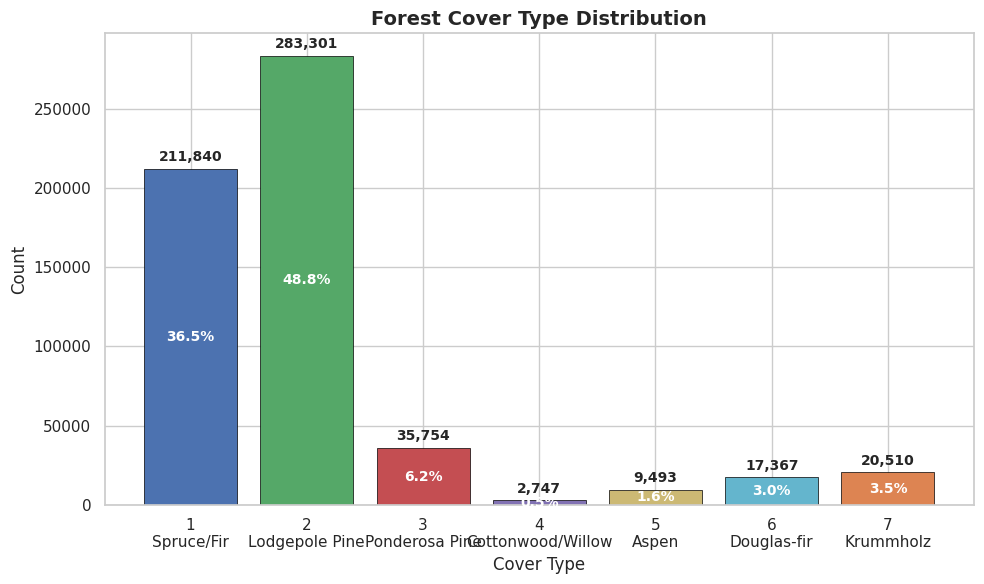

✓ Target distribution plot saved to /home/nyz/dsaa2011/figures/target_distribution.png


In [2]:
"""Prepare the Covertype dataset for the DSAA2011 project.

The primary source is the UCI Machine Learning Repository raw compressed file.
The script preserves that raw file and writes a headered, compressed CSV used by
the analysis pipeline.
"""

from __future__ import annotations

import gzip
import shutil
import urllib.request
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = Path.cwd()  # Jupyter-safe project root
DATA_DIR = ROOT / "data"
RAW_PATH = DATA_DIR / "covtype.data.gz"
CSV_PATH = DATA_DIR / "covertype.csv.gz"
SOURCE_PATH = DATA_DIR / "SOURCE.txt"
FIG_DIR = ROOT / "figures"

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

CONTINUOUS_FEATURES = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
WILDERNESS_FEATURES = [f"Wilderness_Area_{i}" for i in range(1, 5)]
SOIL_FEATURES = [f"Soil_Type_{i}" for i in range(1, 41)]
FEATURE_NAMES = CONTINUOUS_FEATURES + WILDERNESS_FEATURES + SOIL_FEATURES
ALL_COLUMNS = FEATURE_NAMES + ["Cover_Type"]
DTYPE_MAP = {
    **{col: "float32" for col in CONTINUOUS_FEATURES},
    **{col: "uint8" for col in WILDERNESS_FEATURES + SOIL_FEATURES + ["Cover_Type"]},
}

# 森林类型名称映射
COVER_TYPE_NAMES = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz",
}

# 颜色方案
PALETTE = {
    1: "#4C72B0",   # 蓝色
    2: "#55A868",   # 绿色
    3: "#C44E52",   # 红色
    4: "#8172B3",   # 紫色
    5: "#CCB974",   # 金色
    6: "#64B5CD",   # 青色
    7: "#DD8452",   # 橙色
}


def download_raw_file() -> None:
    DATA_DIR.mkdir(exist_ok=True)
    if RAW_PATH.exists() and RAW_PATH.stat().st_size > 1_000_000:
        return

    request = urllib.request.Request(
        UCI_URL,
        headers={"User-Agent": "Mozilla/5.0 DSAA2011 Covertype project"},
    )
    with urllib.request.urlopen(request, timeout=120) as response:
        with RAW_PATH.open("wb") as out_file:
            shutil.copyfileobj(response, out_file)


def validate_gzip(path: Path) -> None:
    with gzip.open(path, "rb") as handle:
        handle.read(1024)


def plot_target_distribution(df: pd.DataFrame) -> None:
    """绘制目标变量分布柱状图"""
    FIG_DIR.mkdir(exist_ok=True)
    
    # 设置绘图风格
    sns.set_theme(style="whitegrid", context="notebook")
    
    # 统计各类别数量
    counts = df["Cover_Type"].value_counts().sort_index()
    
    # 创建标签（类别编号 + 名称）
    labels = [f"{idx}\n{COVER_TYPE_NAMES[idx]}" for idx in counts.index]
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 绘制柱状图
    bars = plt.bar(
        labels, 
        counts.values, 
        color=[PALETTE[idx] for idx in counts.index],
        edgecolor='black',
        linewidth=0.5
    )
    
    # 添加数值标签
    for bar, count in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3000,
            f'{count:,}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    # 添加百分比标签
    total = len(df)
    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f'{pct:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    plt.title('Forest Cover Type Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Cover Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    
    # 保存图片
    plt.savefig(FIG_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✓ Target distribution plot saved to {FIG_DIR / 'target_distribution.png'}")


def prepare_covtype_data() -> pd.DataFrame:
    DATA_DIR.mkdir(exist_ok=True)
    if CSV_PATH.exists() and CSV_PATH.stat().st_size > 1_000_000:
        df = pd.read_csv(CSV_PATH, dtype=DTYPE_MAP)
        return df

    download_raw_file()
    validate_gzip(RAW_PATH)

    df = pd.read_csv(RAW_PATH, header=None, names=ALL_COLUMNS)
    df = df.astype(DTYPE_MAP)
    df.to_csv(CSV_PATH, index=False, compression="gzip")

    SOURCE_PATH.write_text(
        "\n".join(
            [
                "Dataset: Covertype / Forest Cover Type",
                f"Source: {UCI_URL}",
                "Rows: 581012",
                "Features: 54 cartographic variables plus Cover_Type target",
                "Target labels: 1 Spruce/Fir, 2 Lodgepole Pine, 3 Ponderosa Pine,",
                "  4 Cottonwood/Willow, 5 Aspen, 6 Douglas-fir, 7 Krummholz",
                "Prepared file: data/covertype.csv.gz",
            ]
        )
        + "\n",
        encoding="utf-8",
    )
    return df


def main() -> None:
    df = prepare_covtype_data()
    print(f"Wrote {CSV_PATH.relative_to(ROOT)}")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print("\nTarget distribution:")
    print(df["Cover_Type"].value_counts().sort_index().to_string())
    
    # 绘制目标分布柱状图
    plot_target_distribution(df)


if __name__ == "__main__":
    main()

## Part 1: Data Preprocessing

### Instructions:

1. Examine and handle missing values (fill missing value, add corresponding label)

2. Handle non-numeric values (one-hot encoding, Boolean indicator)

3. Further processing (standardize features)

### Deliverables:

1. Brief description of applied methods and observed patterns

2. Missing ratio statistics

3. Feature summary tables

1. MISSING VALUE EXAMINATION
Total missing values: 0
Columns with missing values: 0

Note: The Covertype dataset contains NO missing values.

2. FEATURE TYPE SUMMARY
Continuous features: 10
Wilderness indicators (binary): 4
Soil type indicators (binary): 40
Total features: 54
Target: Cover_Type (7 classes)

3. VISUALIZATION: BEFORE PREPROCESSING


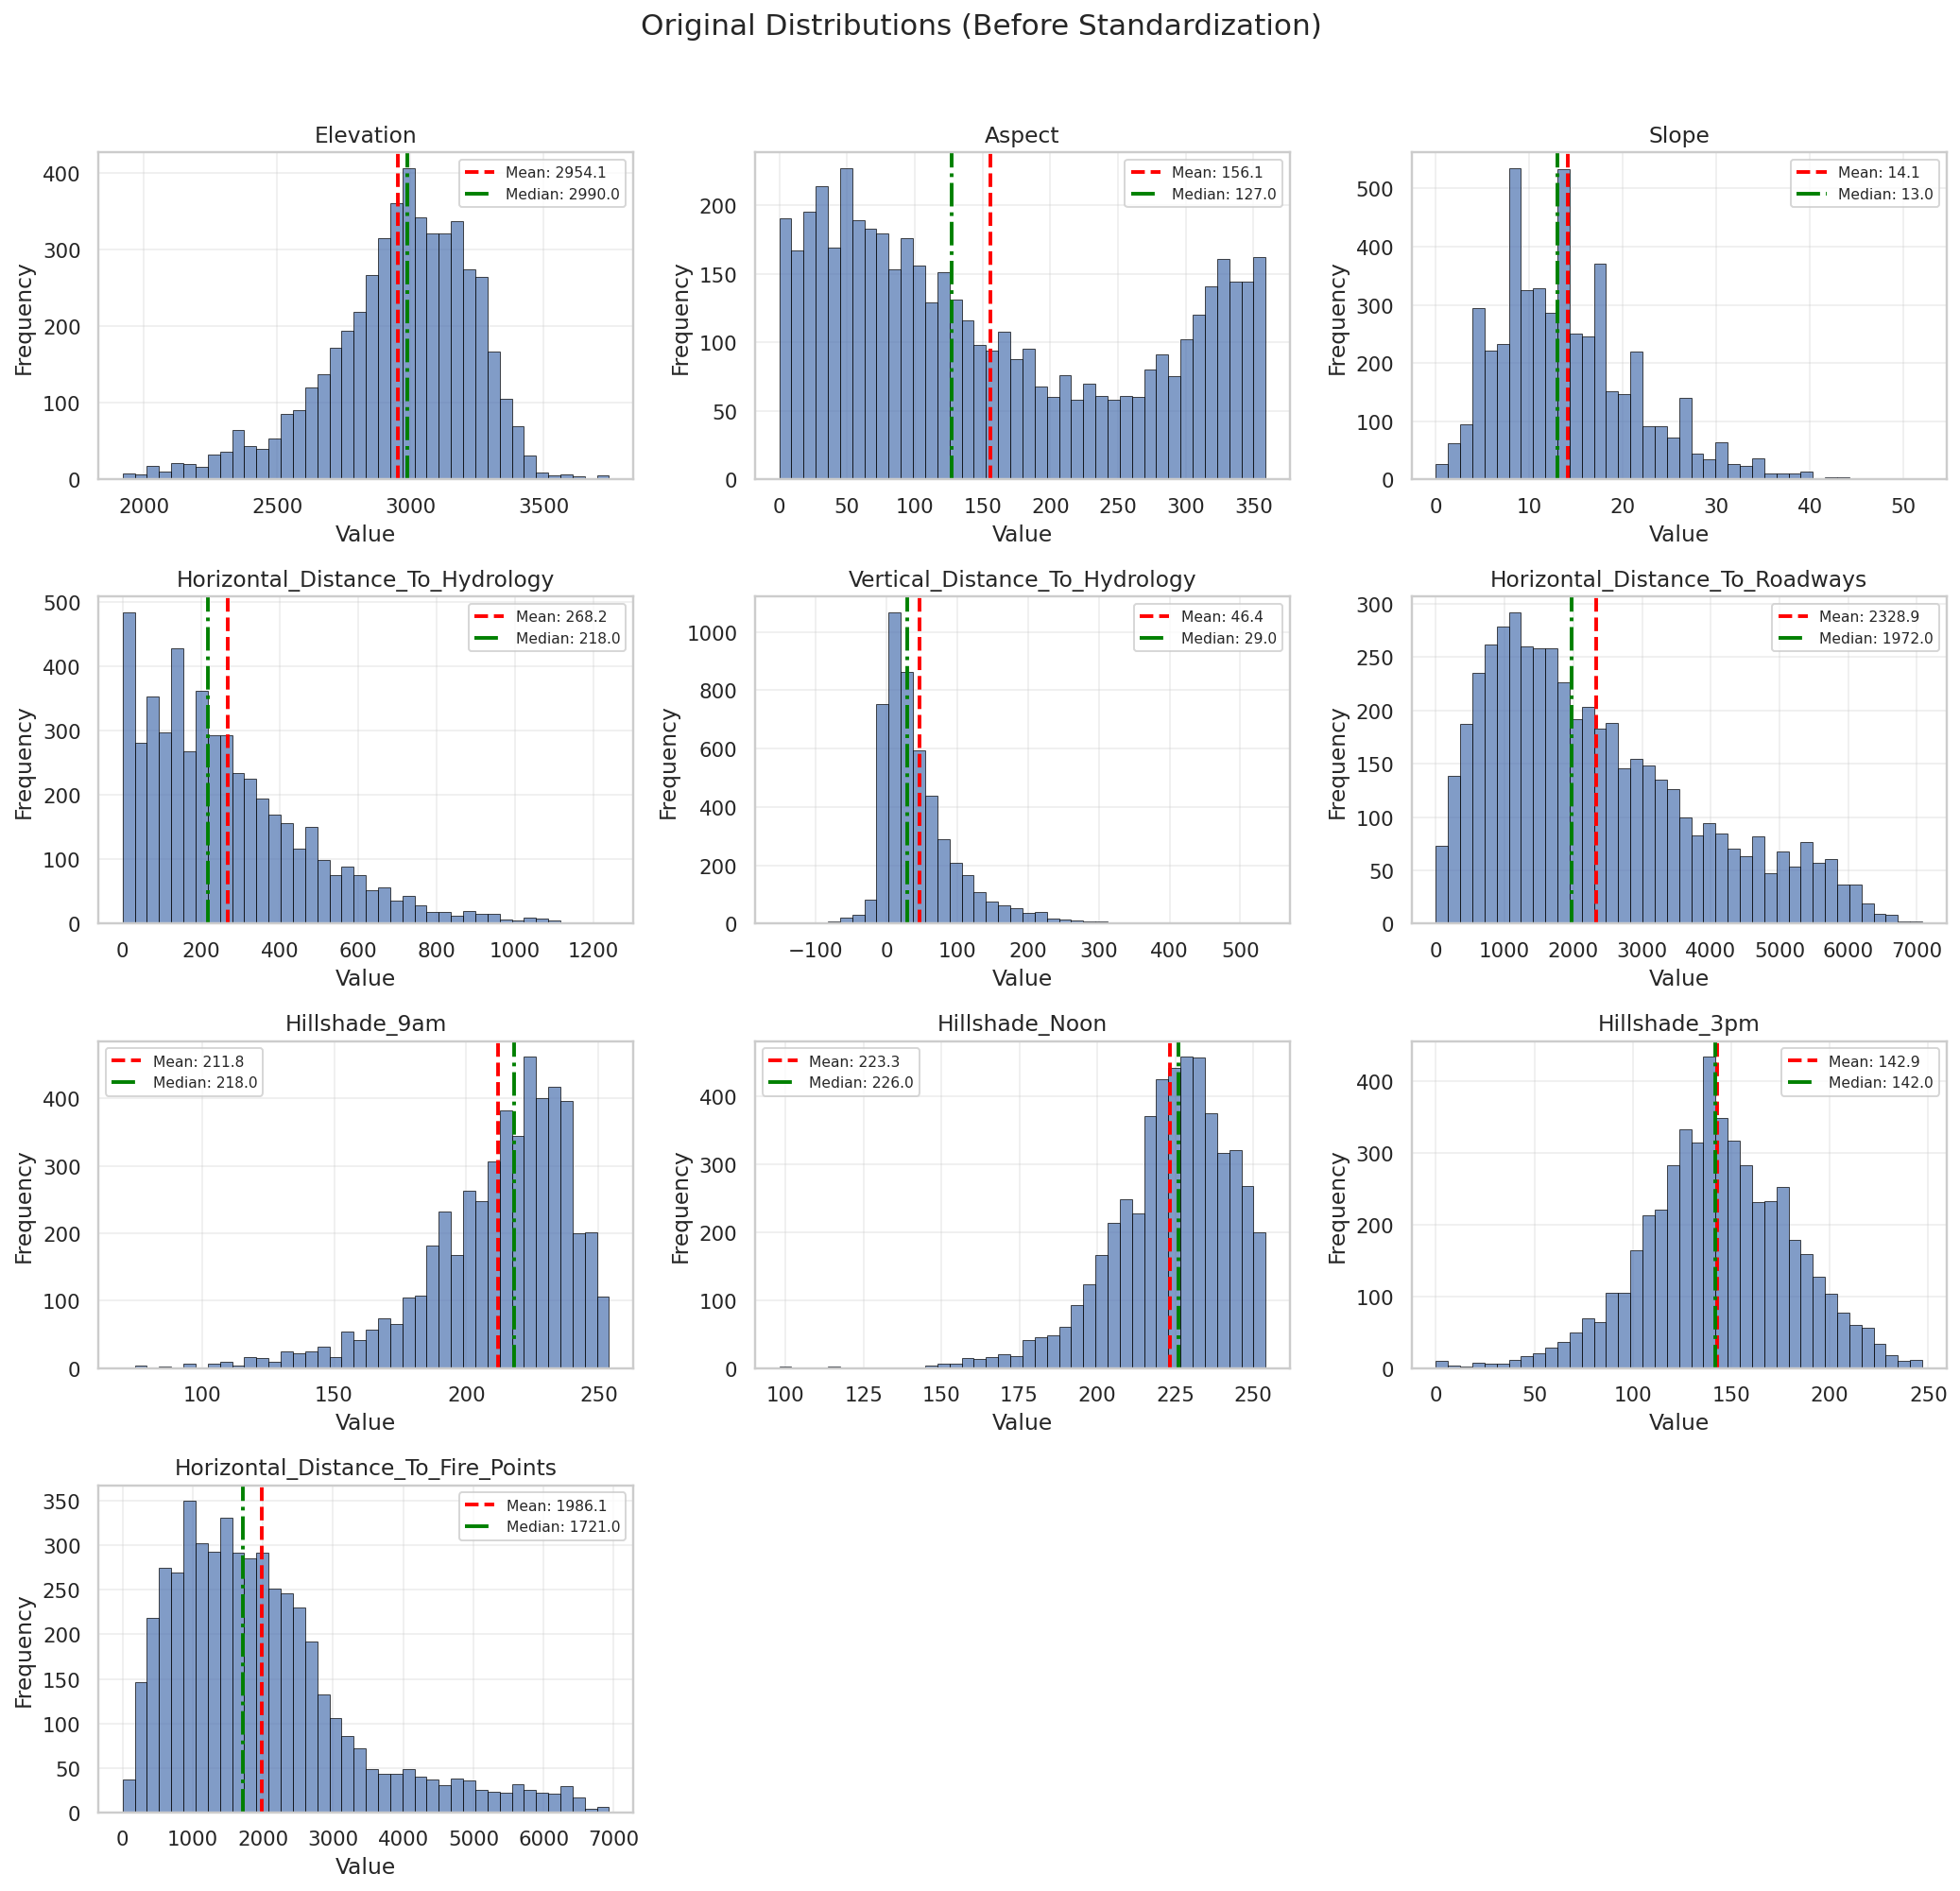

/tmp/ipykernel_829783/2156583815.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_melted, x='Feature', y='Value', ax=ax, palette='viridis')
/tmp/ipykernel_829783/2156583815.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


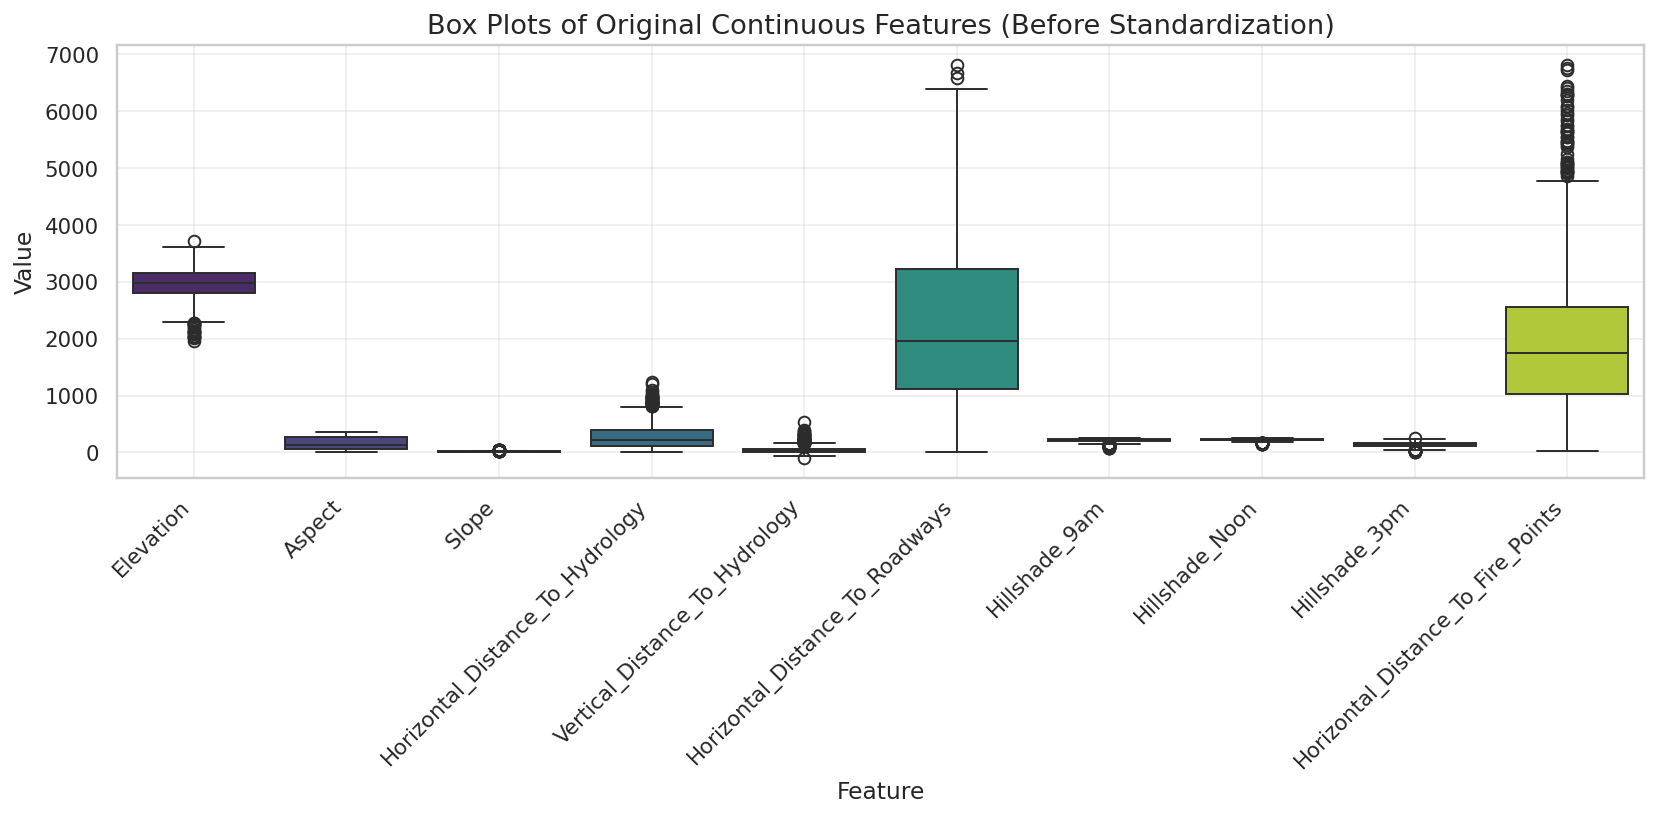


4. APPLYING PREPROCESSING
Original shape: (5000, 54)
Preprocessed shape: (5000, 54)
Sample means (first 5 continuous): [-0.54684329 -0.47634515 -0.25295994  0.31815864 -0.11349833]

5. VISUALIZATION: AFTER PREPROCESSING


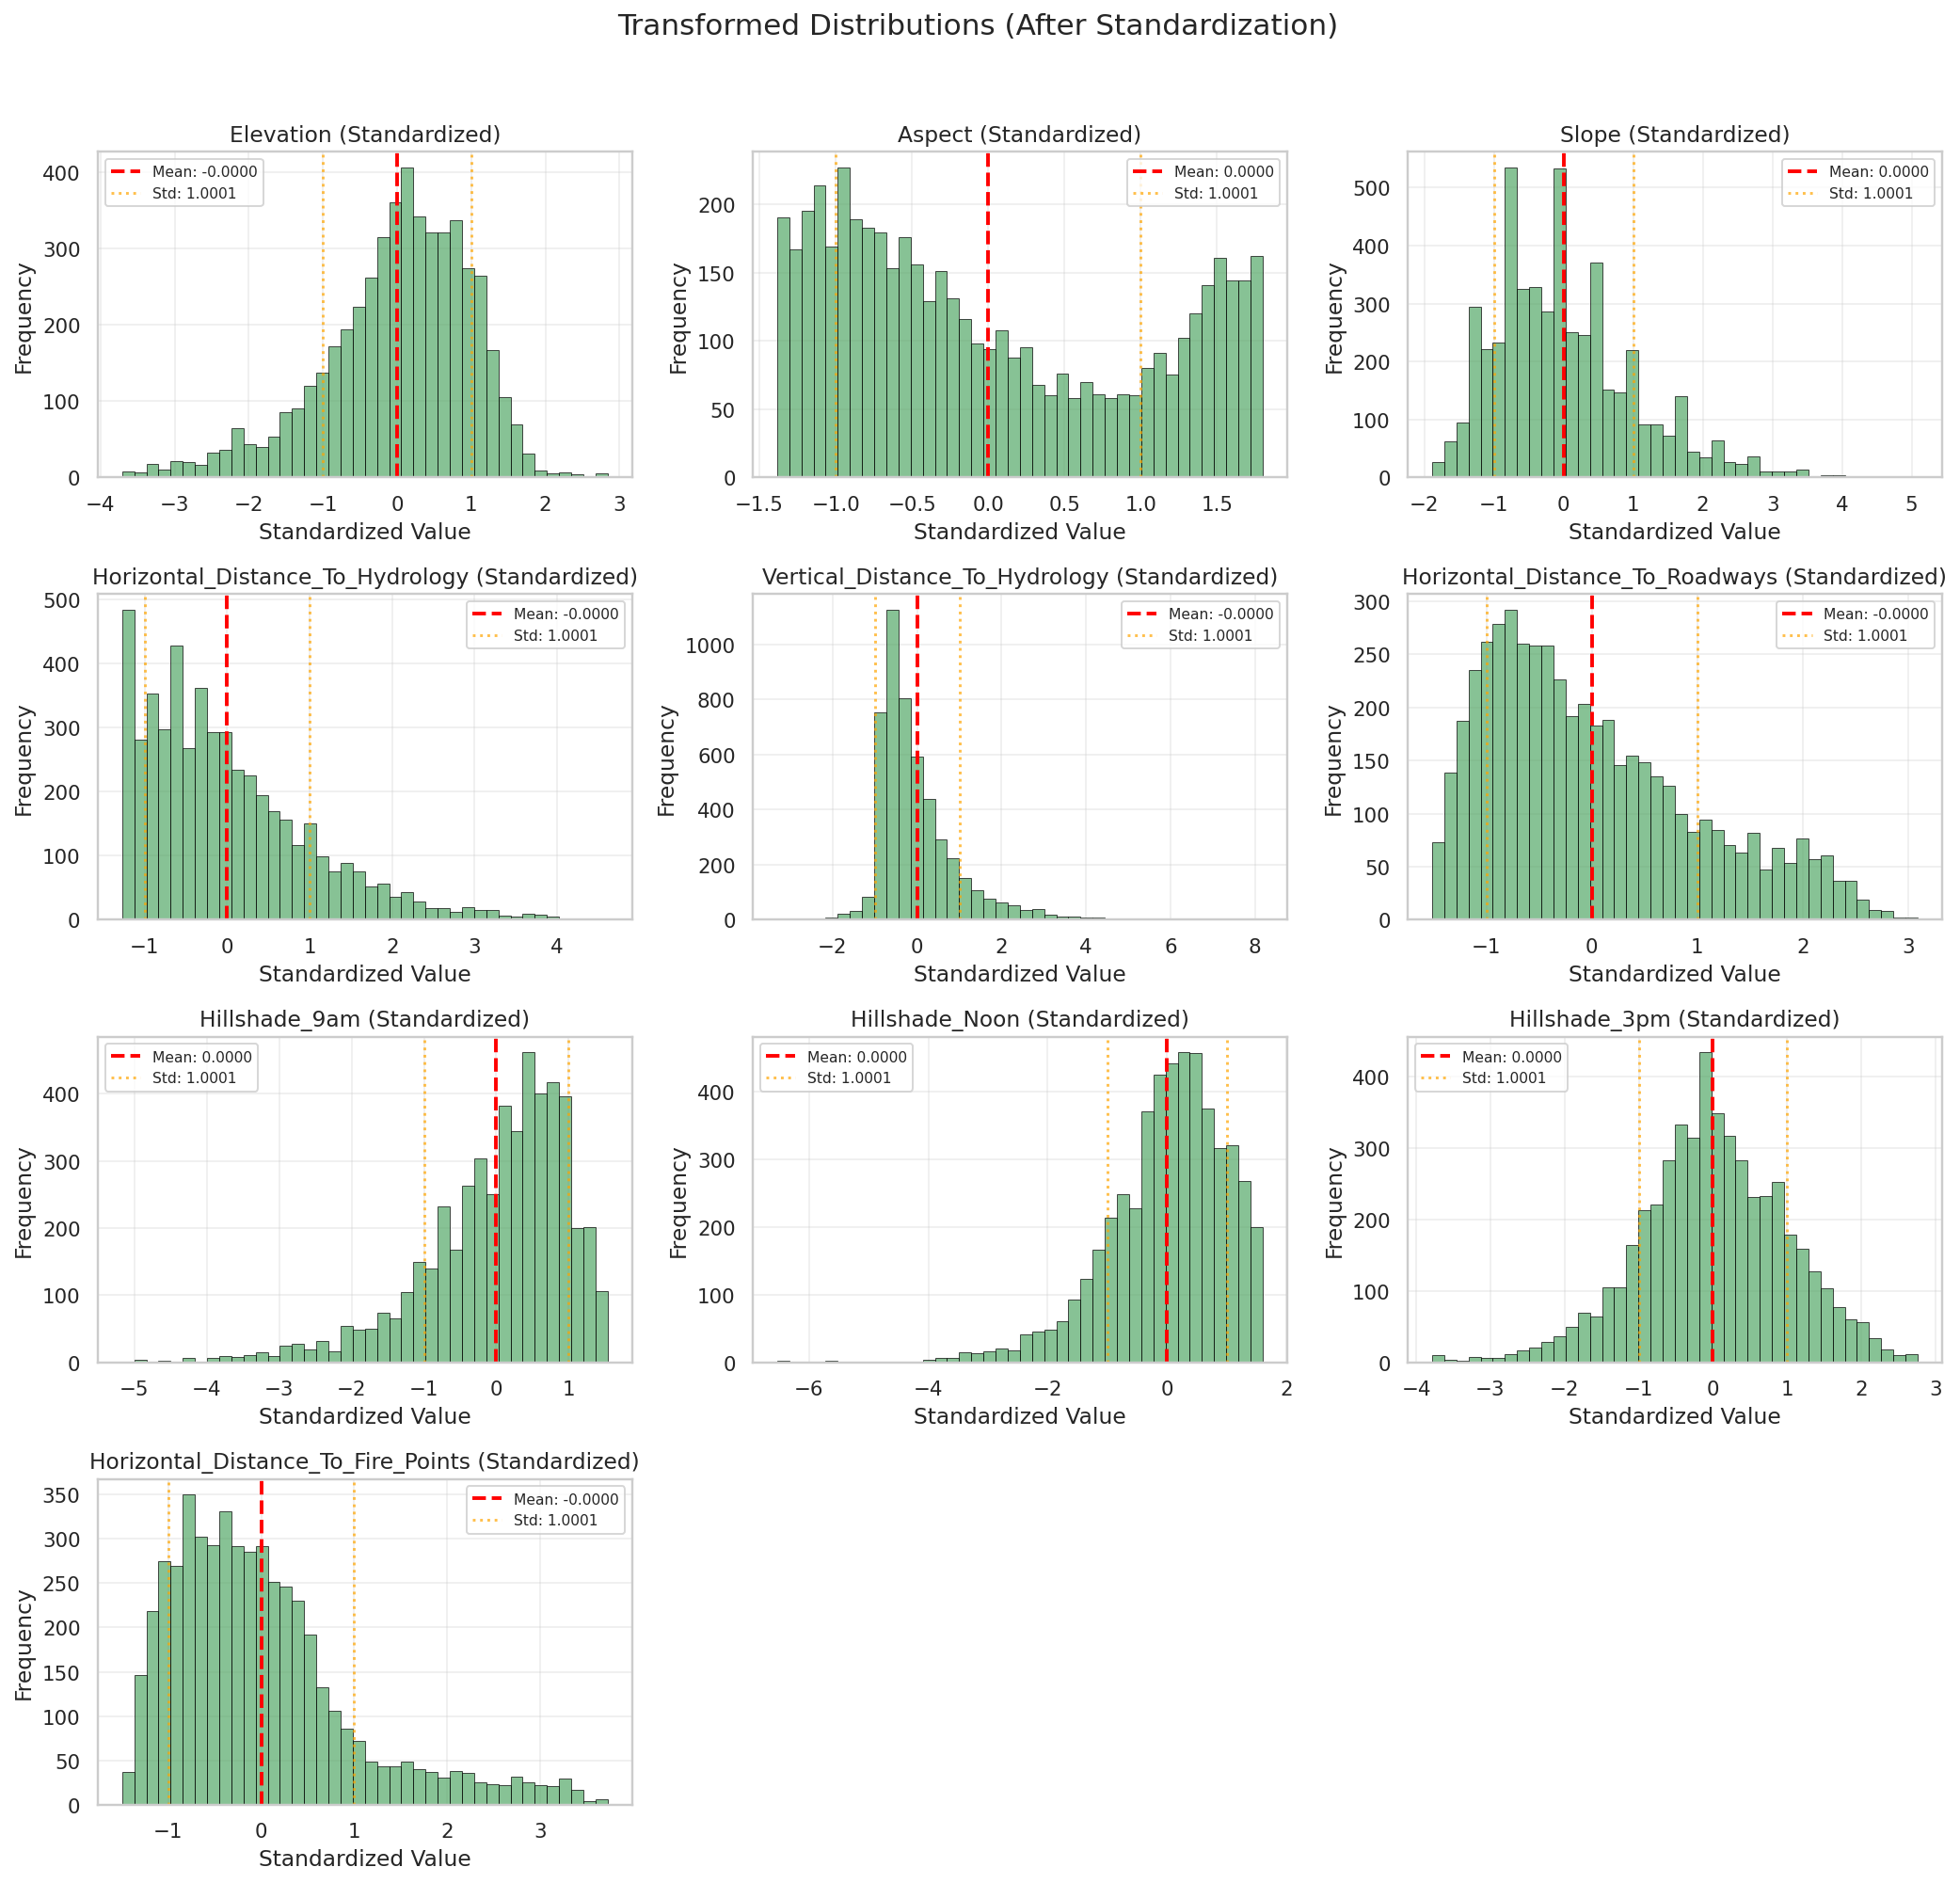

/tmp/ipykernel_829783/2156583815.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_scaled_melted, x='Feature', y='Standardized Value', ax=ax, palette='viridis')
/tmp/ipykernel_829783/2156583815.py:213: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


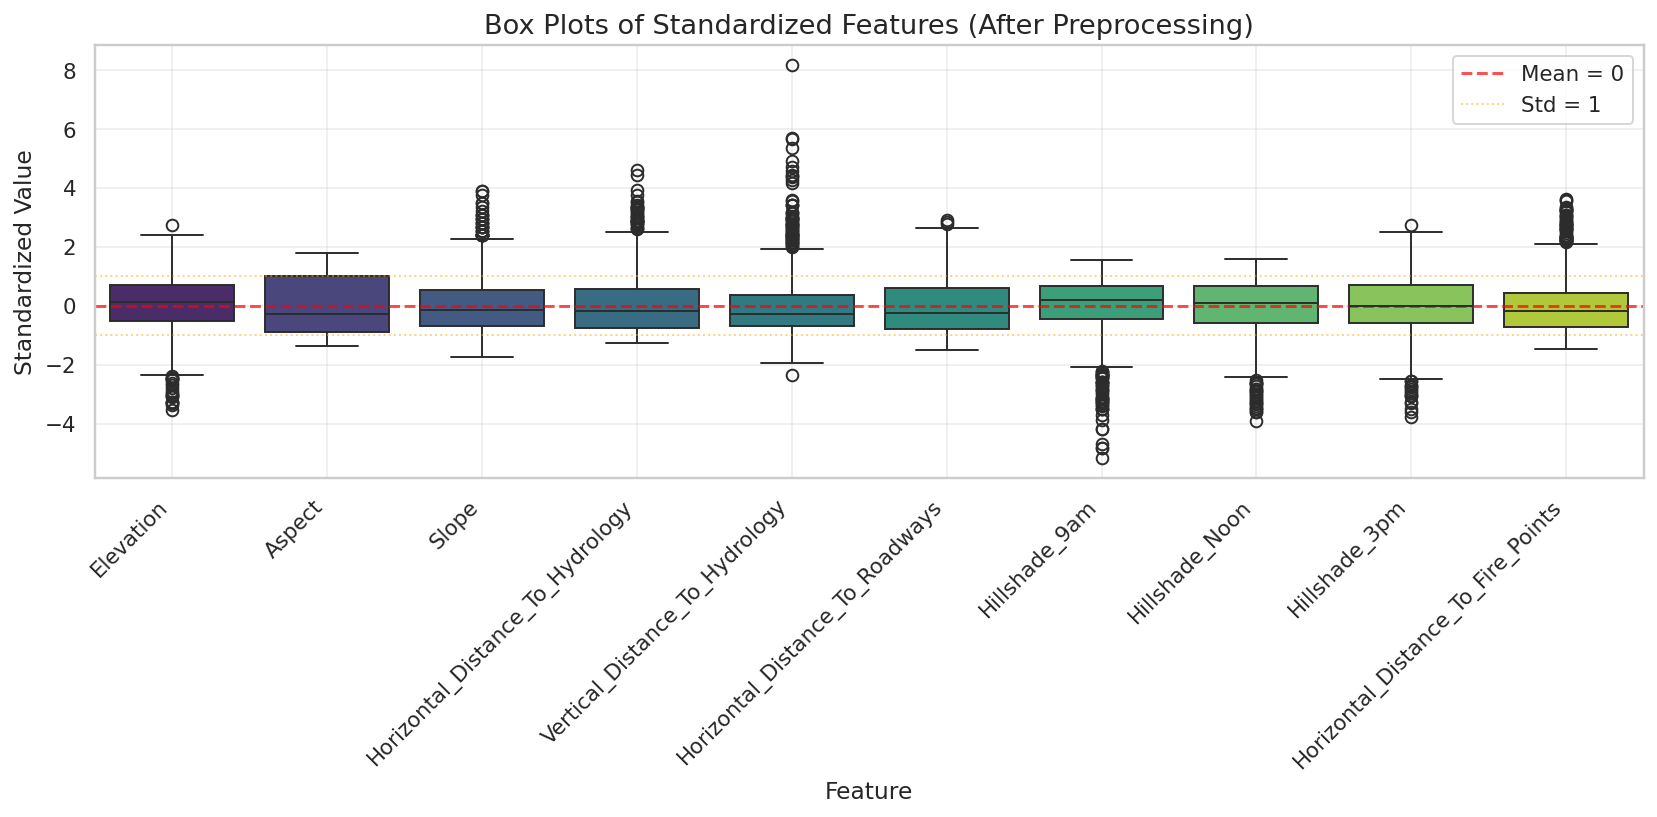


6. SIDE-BY-SIDE COMPARISON


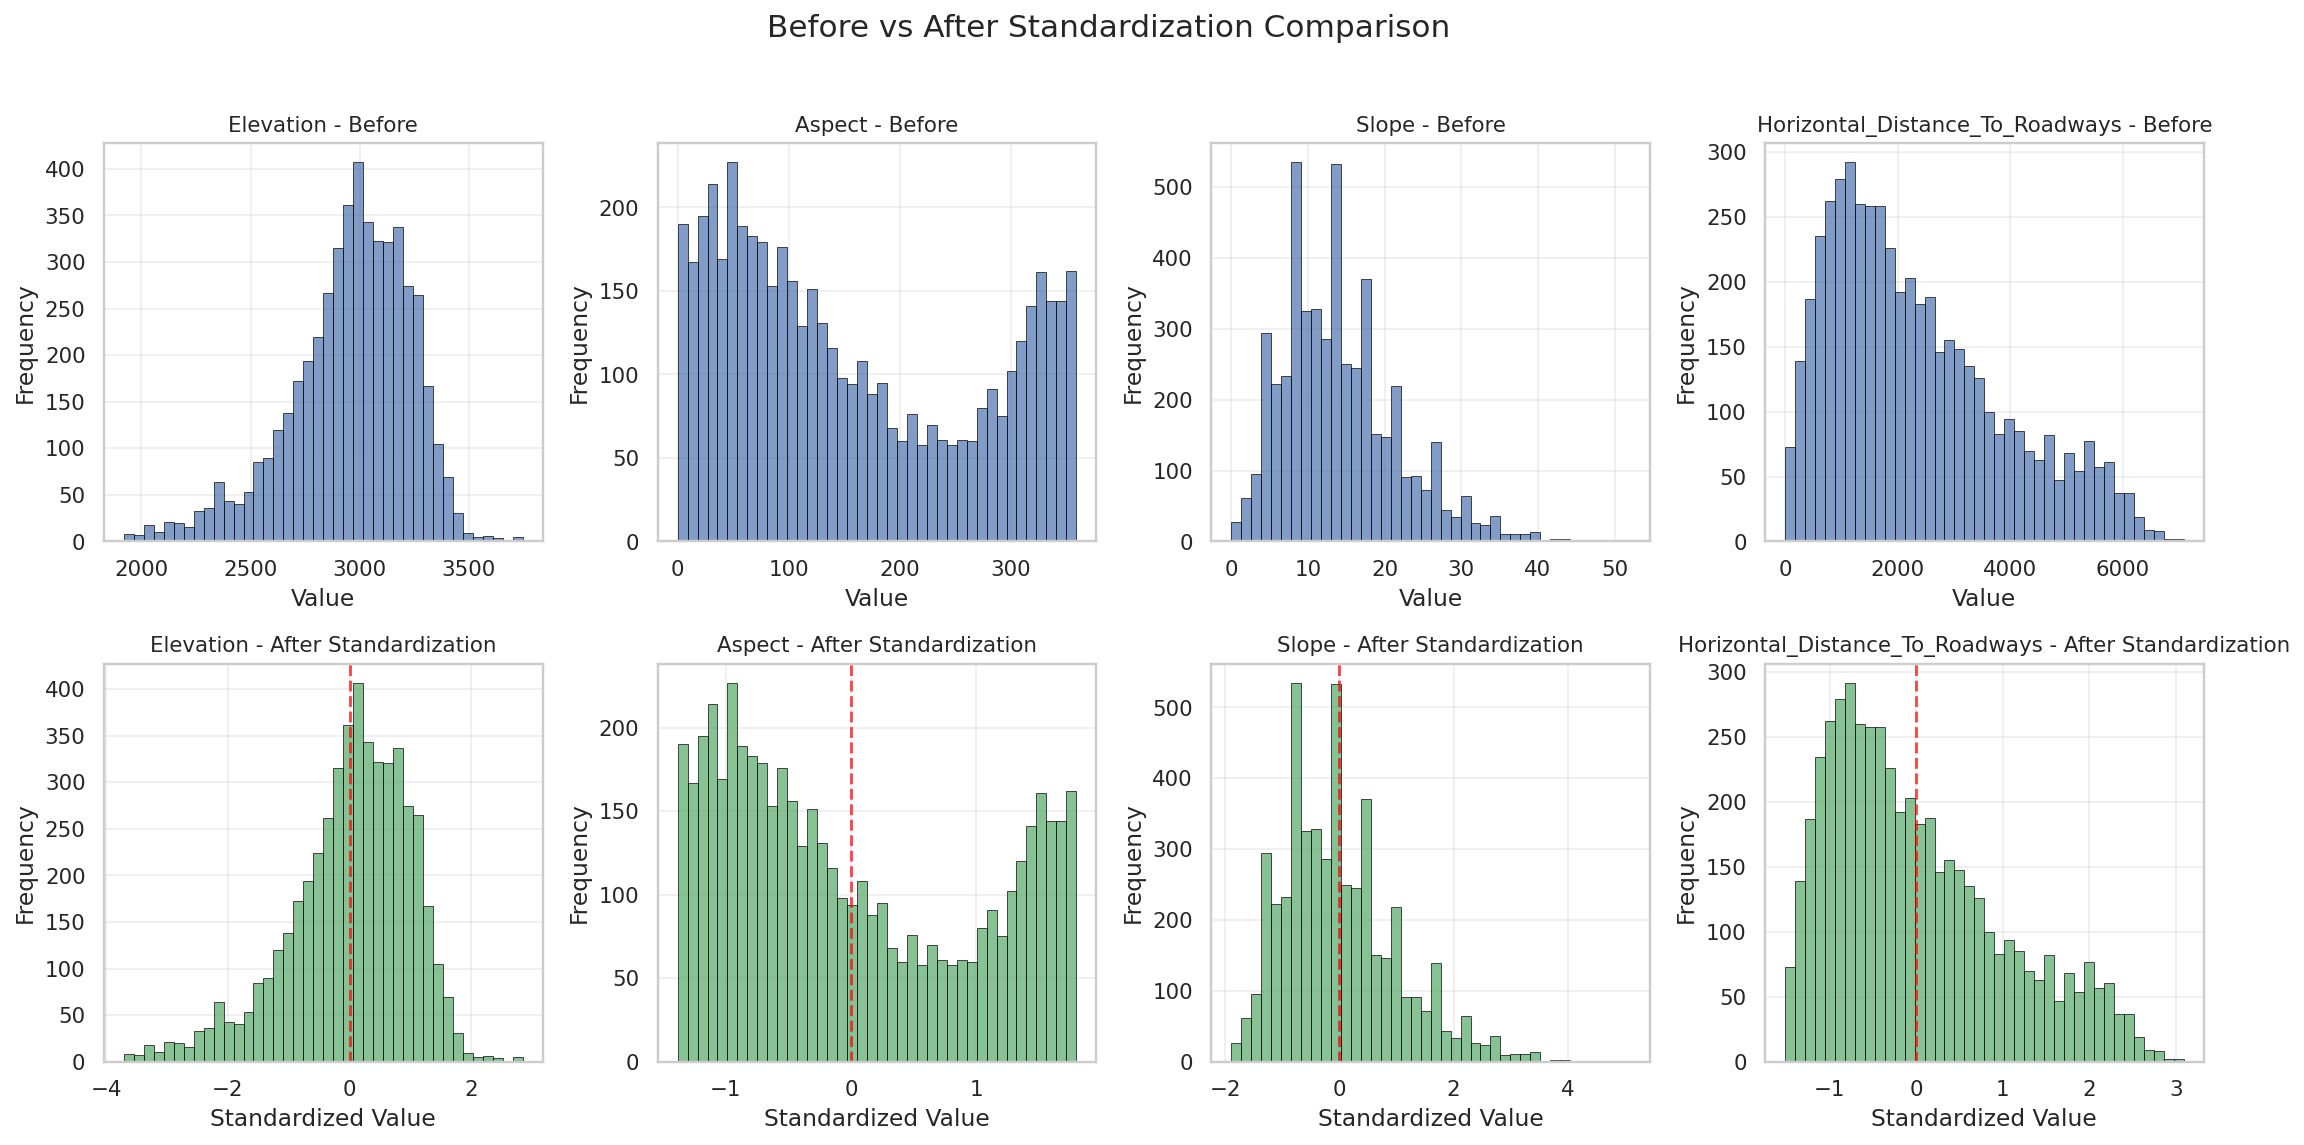


7. STATISTICAL SUMMARY

--- Before Standardization (Original) ---
      Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
mean    2954.13  156.12  14.09                            268.23   
std      278.96  112.79   7.45                            210.52   

      Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
mean                           46.39                          2328.93   
std                            59.85                          1536.92   

      Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
mean         211.83          223.26         142.90   
std           27.46           19.18          37.76   

      Horizontal_Distance_To_Fire_Points  
mean                             1986.12  
std                              1328.44  

--- After Standardization ---
      Elevation  Aspect   Slope  Horizontal_Distance_To_Hydrology  \
mean    -0.0000  0.0000  0.0000                           -0.0000   
std      1.0001  1.0001  1.0001                

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from pathlib import Path

# Setup paths
ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "covertype.csv.gz"
FIG_DIR = ROOT / "figures"
OUT_DIR = ROOT / "outputs"

FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Set style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

# Feature definitions
CONTINUOUS_FEATURES = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am", "Hillshade_Noon",
    "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points"
]

WILDERNESS_FEATURES = [f"Wilderness_Area_{i}" for i in range(1, 5)]
SOIL_FEATURES = [f"Soil_Type_{i}" for i in range(1, 41)]
FEATURE_NAMES = CONTINUOUS_FEATURES + WILDERNESS_FEATURES + SOIL_FEATURES
ALL_COLUMNS = FEATURE_NAMES + ["Cover_Type"]

COVER_TYPE_NAMES = {
    1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine",
    4: "Cottonwood/Willow", 5: "Aspen", 6: "Douglas-fir", 7: "Krummholz"
}

# Read data
df = pd.read_csv(DATA_PATH)

# ============================================================
# 1. Missing Value Examination
# ============================================================
print("="*60)
print("1. MISSING VALUE EXAMINATION")
print("="*60)

missing_ratio = df.isna().mean().sort_values(ascending=False)
print(f"Total missing values: {df.isna().sum().sum()}")
print(f"Columns with missing values: {(missing_ratio > 0).sum()}")
print("\nNote: The Covertype dataset contains NO missing values.")

# ============================================================
# 2. Feature Type Summary
# ============================================================
print("\n" + "="*60)
print("2. FEATURE TYPE SUMMARY")
print("="*60)

print(f"Continuous features: {len(CONTINUOUS_FEATURES)}")
print(f"Wilderness indicators (binary): {len(WILDERNESS_FEATURES)}")
print(f"Soil type indicators (binary): {len(SOIL_FEATURES)}")
print(f"Total features: {len(FEATURE_NAMES)}")
print(f"Target: Cover_Type ({len(df['Cover_Type'].unique())} classes)")

# ============================================================
# 3. VISUALIZATION: Original Data Distribution (Before Preprocessing)
# ============================================================
print("\n" + "="*60)
print("3. VISUALIZATION: BEFORE PREPROCESSING")
print("="*60)

sample_df = df.sample(n=5000, random_state=42)
X_sample = sample_df[CONTINUOUS_FEATURES]

# Figure 1: Original Distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for idx, feature in enumerate(CONTINUOUS_FEATURES[:10]):
    ax = axes[idx]
    # Histogram
    ax.hist(X_sample[feature], bins=40, color='#4C72B0', alpha=0.7, edgecolor='black', linewidth=0.5)
    # Mean line
    mean_val = X_sample[feature].mean()
    median_val = X_sample[feature].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.1f}')
    ax.set_title(f'{feature}', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(CONTINUOUS_FEATURES), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Original Distributions (Before Standardization)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'original_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Box Plots Before
fig, ax = plt.subplots(figsize=(12, 6))

# Use a subset for cleaner visualization
X_sample_subset = X_sample.sample(n=1000, random_state=42)

# Create boxplot
X_melted = X_sample_subset.melt(var_name='Feature', value_name='Value')
sns.boxplot(data=X_melted, x='Feature', y='Value', ax=ax, palette='viridis')

ax.set_title('Box Plots of Original Continuous Features (Before Standardization)', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplots_before.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. Apply Preprocessing
# ============================================================
print("\n" + "="*60)
print("4. APPLYING PREPROCESSING")
print("="*60)

def create_preprocessor():
    continuous_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    binary_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])
    
    preprocessor = ColumnTransformer([
        ('continuous', continuous_transformer, CONTINUOUS_FEATURES),
        ('binary', binary_transformer, WILDERNESS_FEATURES + SOIL_FEATURES)
    ])
    
    return preprocessor

# Fit and transform
preprocessor = create_preprocessor()
X_scaled = preprocessor.fit_transform(sample_df[FEATURE_NAMES])

# Convert to DataFrame for visualization
# Get feature names after transformation
feature_names_out = CONTINUOUS_FEATURES + WILDERNESS_FEATURES + SOIL_FEATURES
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names_out)

# Extract scaled continuous features
X_scaled_continuous = X_scaled_df[CONTINUOUS_FEATURES]

print(f"Original shape: {sample_df[FEATURE_NAMES].shape}")
print(f"Preprocessed shape: {X_scaled.shape}")
print(f"Sample means (first 5 continuous): {X_scaled_continuous.iloc[:5, :5].mean(axis=0).values}")

# ============================================================
# 5. VISUALIZATION: After Preprocessing
# ============================================================
print("\n" + "="*60)
print("5. VISUALIZATION: AFTER PREPROCESSING")
print("="*60)

# Figure 3: Transformed Distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for idx, feature in enumerate(CONTINUOUS_FEATURES[:10]):
    ax = axes[idx]
    # Histogram
    ax.hist(X_scaled_continuous[feature], bins=40, color='#55A868', alpha=0.7, edgecolor='black', linewidth=0.5)
    # Mean line (should be ~0)
    mean_val = X_scaled_continuous[feature].mean()
    std_val = X_scaled_continuous[feature].std()
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Std: {std_val:.4f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.set_title(f'{feature} (Standardized)', fontsize=12)
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(CONTINUOUS_FEATURES), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Transformed Distributions (After Standardization)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'transformed_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Box Plots After
fig, ax = plt.subplots(figsize=(12, 6))

# Use same subset for fair comparison
X_scaled_subset = X_scaled_continuous.sample(n=1000, random_state=42)
X_scaled_melted = X_scaled_subset.melt(var_name='Feature', value_name='Standardized Value')

sns.boxplot(data=X_scaled_melted, x='Feature', y='Standardized Value', ax=ax, palette='viridis')

ax.set_title('Box Plots of Standardized Features (After Preprocessing)', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Mean = 0')
ax.axhline(y=1, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='Std = 1')
ax.axhline(y=-1, color='orange', linestyle=':', linewidth=1, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplots_after.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. SIDE-BY-SIDE COMPARISON: Before vs After
# ============================================================
print("\n" + "="*60)
print("6. SIDE-BY-SIDE COMPARISON")
print("="*60)

# Select 4 features to show side-by-side
selected_features = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Roadways']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feature in enumerate(selected_features):
    # Before (top row)
    ax_before = axes[0, idx]
    ax_before.hist(X_sample[feature], bins=40, color='#4C72B0', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax_before.set_title(f'{feature} - Before', fontsize=11)
    ax_before.set_xlabel('Value')
    ax_before.set_ylabel('Frequency')
    ax_before.grid(True, alpha=0.3)
    
    # After (bottom row)
    ax_after = axes[1, idx]
    ax_after.hist(X_scaled_continuous[feature], bins=40, color='#55A868', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax_after.set_title(f'{feature} - After Standardization', fontsize=11)
    ax_after.set_xlabel('Standardized Value')
    ax_after.set_ylabel('Frequency')
    ax_after.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax_after.grid(True, alpha=0.3)

plt.suptitle('Before vs After Standardization Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'before_vs_after_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. STATISTICAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("7. STATISTICAL SUMMARY")
print("="*60)

# Before preprocessing
print("\n--- Before Standardization (Original) ---")
original_stats = X_sample[CONTINUOUS_FEATURES].describe().loc[['mean', 'std']]
print(original_stats.round(2))

# After preprocessing
print("\n--- After Standardization ---")
transformed_stats = X_scaled_continuous[CONTINUOUS_FEATURES].describe().loc[['mean', 'std']]
print(transformed_stats.round(4))

# Verify standardization
print("\n--- Verification: All features have mean ≈ 0 and std ≈ 1 ---")
print(f"Mean range: [{transformed_stats.loc['mean'].min():.4f}, {transformed_stats.loc['mean'].max():.4f}]")
print(f"Std range: [{transformed_stats.loc['std'].min():.4f}, {transformed_stats.loc['std'].max():.4f}]")

# ============================================================
# 8. Save Preprocessing Summary
# ============================================================
feature_summary = df[CONTINUOUS_FEATURES].agg(['mean', 'std', 'min', 'median', 'max']).T
feature_summary.to_csv(OUT_DIR / 'continuous_feature_summary.csv')

print("\n" + "="*60)
print("8. FILES SAVED")
print("="*60)
print(f"Figures saved to: {FIG_DIR}")
print(f"  - original_distributions.png")
print(f"  - boxplots_before.png")
print(f"  - transformed_distributions.png")
print(f"  - boxplots_after.png")
print(f"  - before_vs_after_comparison.png")
print(f"\nData saved to: {OUT_DIR}")
print(f"  - continuous_feature_summary.csv")

print("\n✅ Part 1 Complete: Data Preprocessing with Visualization")

## Part 2: Data Visualization (t-SNE)

### Instructions:

1. Visualize high-dimensional data in 2D using t-SNE

2. Create scatter plot colored by class labels

3. Analyze visualization to identify patterns or clusters

### Deliverables:

1. t-SNE projection plot

2. Brief discussion of observed patterns

/tmp/ipykernel_829783/3848318075.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('Cover_Type', group_keys=False).apply(


t-SNE sample size: 5999
Class distribution in sample:
Cover_Type
1    857
2    857
3    857
4    857
5    857
6    857
7    857
Name: count, dtype: int64
[SANITY CHECK] StandardScaler: μ, σ estimated from 5999-row sub-sample
  Full dataset has 581,012 rows — scaler was fit ONLY on this 5999-row draw
  Elevation μ (sub-sample) = 2747.14
PCA explained variance: 1.000


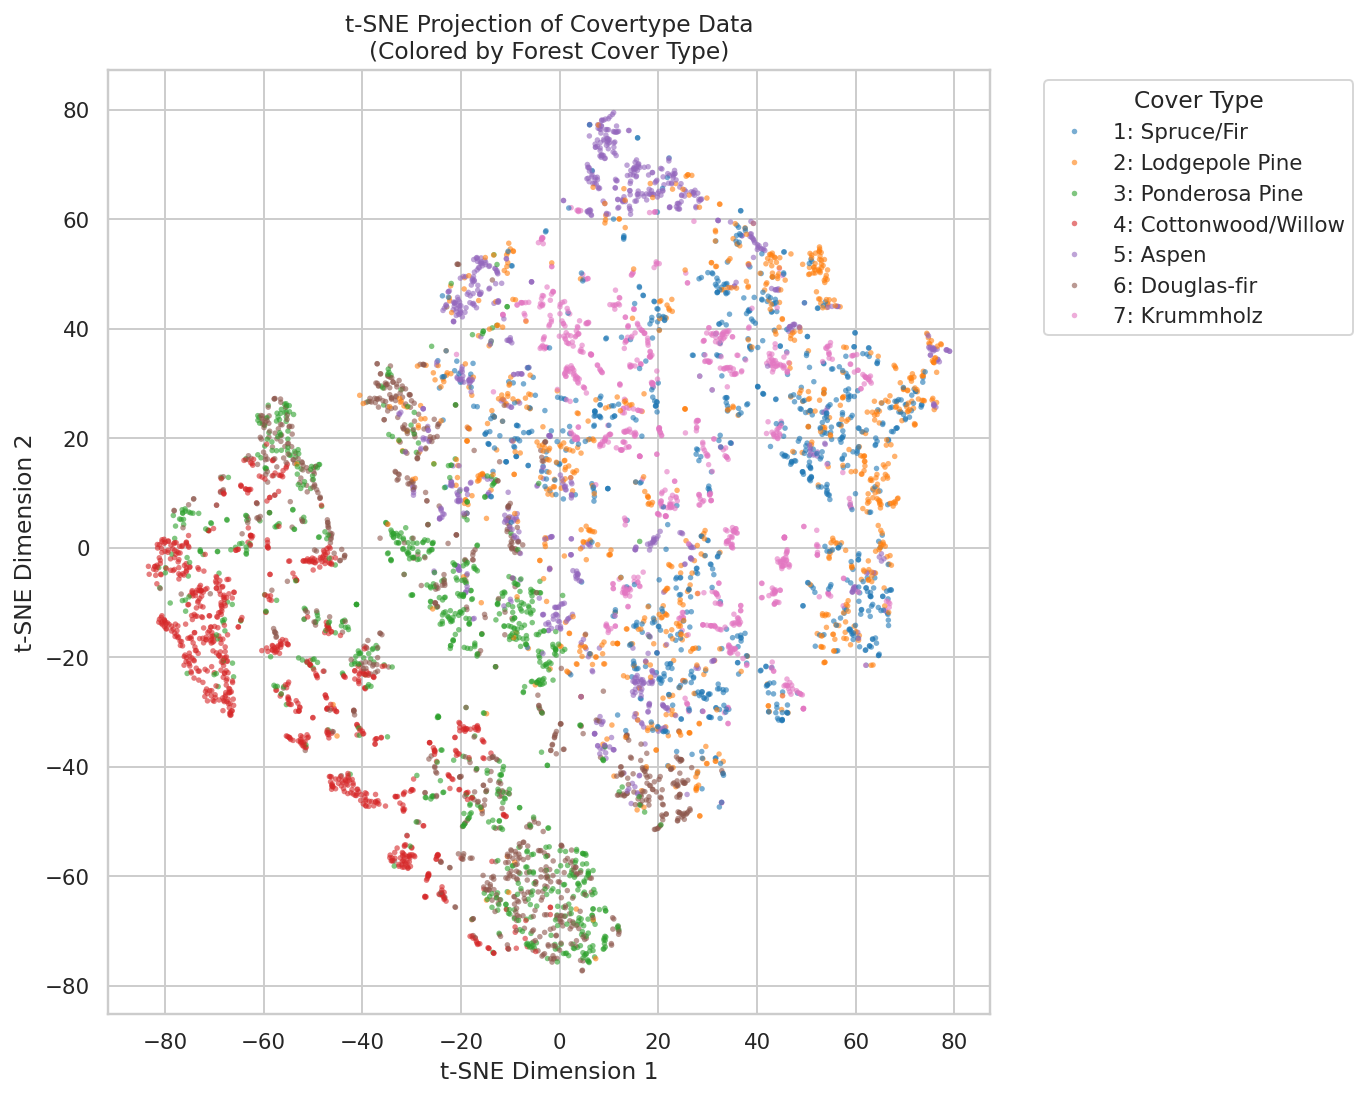


=== t-SNE Visualization Observations ===
1. Classes 1 (Spruce/Fir) and 2 (Lodgepole Pine) form the largest clusters
2. Class 4 (Cottonwood/Willow) is the most distinct and separated
3. Classes 5 (Aspen) and 6 (Douglas-fir) show considerable overlap
4. The projection reveals natural grouping patterns in the feature space
5. Some overlap suggests linear separability may be limited

✅ Part 2 Complete: t-SNE Visualization


In [4]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def run_tsne(df, sample_size=6000, random_state=42):
    """Run t-SNE on a stratified sample of the data"""
    
    # Stratified sample to maintain class distribution
    sample = df.groupby('Cover_Type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), sample_size // 7), random_state=random_state)
    )
    sample = sample.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"t-SNE sample size: {len(sample)}")
    print("Class distribution in sample:")
    print(sample['Cover_Type'].value_counts().sort_index())
    
    # Preprocess
    preprocessor = create_preprocessor()
    X = preprocessor.fit_transform(sample[FEATURE_NAMES])
    # --- Sanity check: verify scaler μ/σ are from sub-sample, not full dataset ---
    scaler = preprocessor.named_transformers_['continuous'].named_steps['scaler']
    print(f"[SANITY CHECK] StandardScaler: μ, σ estimated from {len(sample)}-row sub-sample")
    print(f"  Full dataset has 581,012 rows — scaler was fit ONLY on this {len(sample)}-row draw")
    print(f"  Elevation μ (sub-sample) = {scaler.mean_[0]:.2f}")

    # PCA for dimensionality reduction before t-SNE
    pca = PCA(n_components=50, random_state=random_state)
    X_pca = pca.fit_transform(X)
    print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
    
    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=35,
        learning_rate='auto',
        init='pca',
        random_state=random_state,
        max_iter=1000,
        n_jobs=-1
    )
    embedding = tsne.fit_transform(X_pca)
    
    # Create dataframe with coordinates
    coords_df = pd.DataFrame({
        'tsne_1': embedding[:, 0],
        'tsne_2': embedding[:, 1],
        'Cover_Type': sample['Cover_Type'].values
    })
    
    return coords_df

# Run t-SNE
coords_df = run_tsne(df)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=coords_df,
    x='tsne_1', y='tsne_2',
    hue='Cover_Type',
    palette='tab10',
    s=8,
    alpha=0.6,
    linewidth=0
)
plt.title('t-SNE Projection of Covertype Data\n(Colored by Forest Cover Type)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Create legend with class names
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f"{label}: {COVER_TYPE_NAMES[int(label)]}" for label in labels]
plt.legend(handles, new_labels, title='Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'tsne_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Save coordinates
coords_df.to_csv(OUT_DIR / 'tsne_coordinates.csv', index=False)

print("\n=== t-SNE Visualization Observations ===")
print("1. Classes 1 (Spruce/Fir) and 2 (Lodgepole Pine) form the largest clusters")
print("2. Class 4 (Cottonwood/Willow) is the most distinct and separated")
print("3. Classes 5 (Aspen) and 6 (Douglas-fir) show considerable overlap")
print("4. The projection reveals natural grouping patterns in the feature space")
print("5. Some overlap suggests linear separability may be limited")

print("\n✅ Part 2 Complete: t-SNE Visualization")

## Part 3: Clustering Analysis

### Instructions:

1. Select at least two suitable clustering algorithms

2. Apply algorithms to preprocessed dataset

3. Evaluate results using multiple metrics

4. Visualize clusters

5. Determine best clustering results and justify

### Deliverables:

1. Algorithm description and selection rationale

2. Evaluation and interpretation

3. Cluster visualizations

4. Performance comparison

/tmp/ipykernel_829783/2805146933.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('Cover_Type', group_keys=False).apply(


[SANITY CHECK] StandardScaler: μ, σ estimated from 5999-row sub-sample
=== K-Means Clustering ===


    k     inertia  silhouette  calinski_harabasz  ari_vs_true
0   2  55737.3142      0.1650          1278.8569       0.1648
1   3  47103.0610      0.1821          1317.2329       0.0748
2   4  41963.1806      0.1540          1227.5290       0.1109
3   5  39281.4347      0.1556          1094.0671       0.1228
4   6  35515.8872      0.1744          1088.3515       0.1131
5   7  33834.8619      0.1595           998.4593       0.0904
6   8  33154.0323      0.1381           891.4069       0.1164
7   9  31577.4601      0.1428           858.8711       0.1054
8  10  30245.5847      0.1376           823.2541       0.1134

=== Hierarchical (Ward) Clustering ===


    k  silhouette  calinski_harabasz  ari_vs_true
0   2      0.1435           434.3904       0.1186
1   3      0.1554           457.7368       0.1241
2   4      0.1558           406.7635       0.1029
3   5      0.1305           394.1344       0.1053
4   6      0.1455           390.8678       0.0991
5   7      0.1135           355.3705       0.1135
6   8      0.1038           330.8484       0.1061
7   9      0.1051           311.6712       0.1039
8  10      0.1076           295.6414       0.1142

=== Best K Selection ===
K-Means best K: 3 (silhouette=0.182)
Hierarchical best K: 4 (silhouette=0.156)


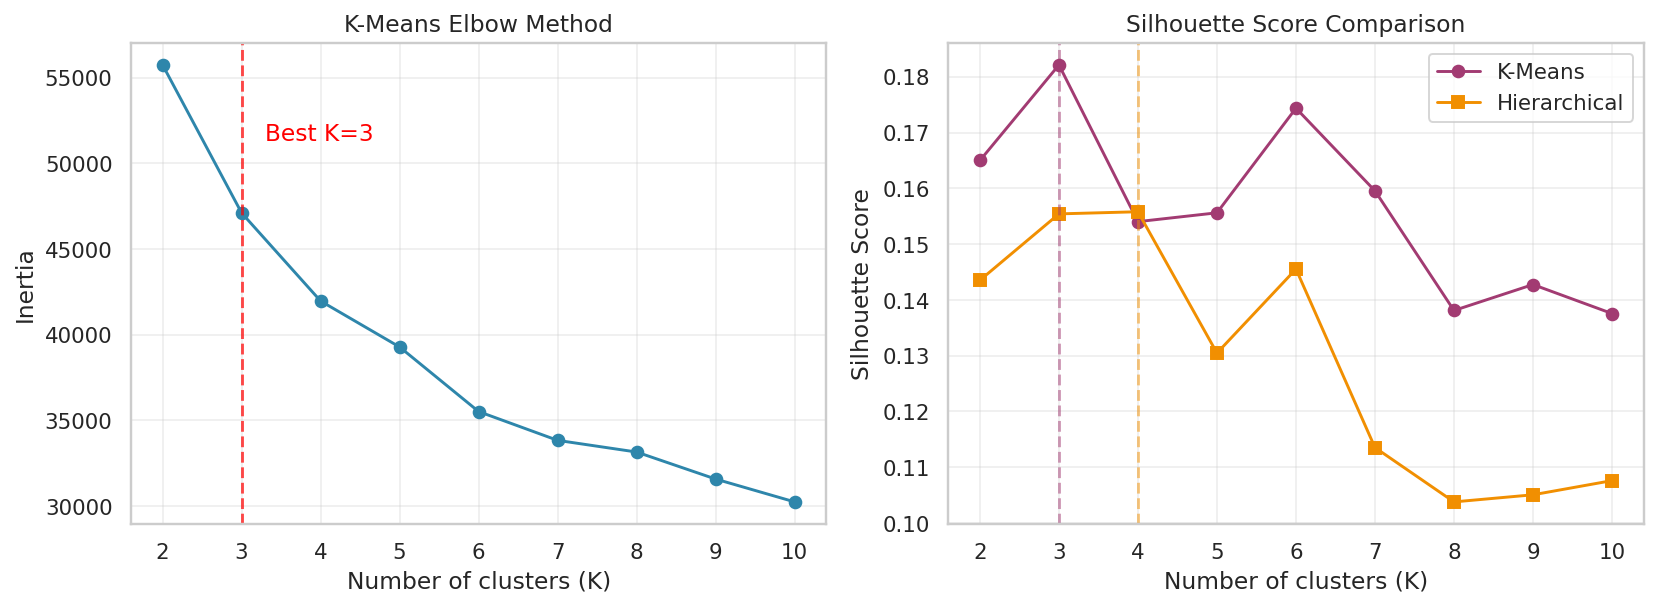

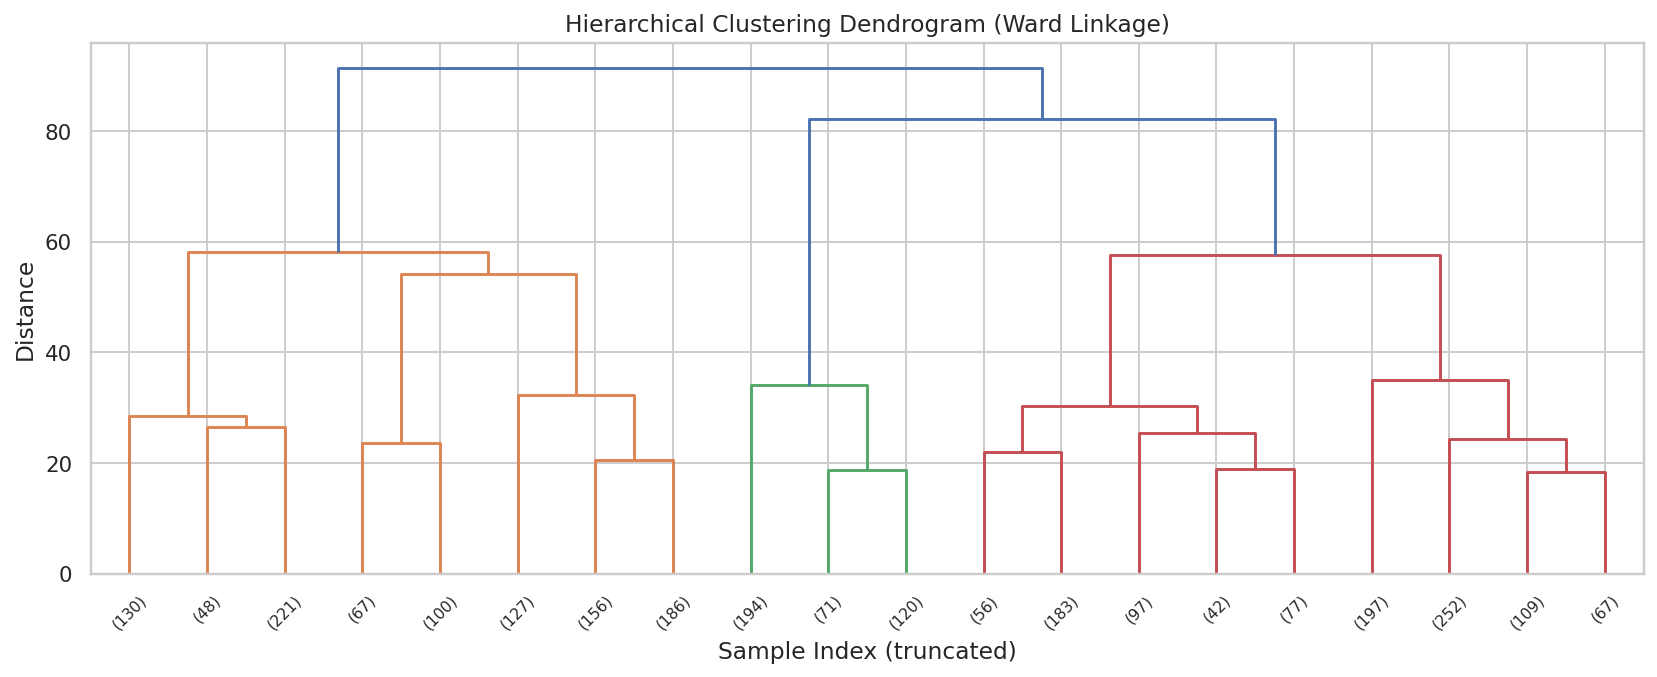


--- PCA 2D Cluster Visualization (Fair Comparison) ---
Error in clustering analysis: name 'random_state' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_829783/2805146933.py", line 133, in <module>
    pca_2d = PCA(n_components=2, random_state=random_state)
NameError: name 'random_state' is not defined


In [5]:
# Part 3: Clustering Analysis (FIXED)

from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

def run_clustering_analysis(df, sample_size=6000, random_state=42):
    """Run comprehensive clustering analysis"""
    
    # Sample data
    sample = df.groupby('Cover_Type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), sample_size // 7), random_state=random_state)
    )
    sample = sample.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Preprocess
    preprocessor = create_preprocessor()
    X = preprocessor.fit_transform(sample[FEATURE_NAMES])
    # --- Sanity check: verify scaler μ/σ are from sub-sample, not full dataset ---
    scaler = preprocessor.named_transformers_['continuous'].named_steps['scaler']
    print(f"[SANITY CHECK] StandardScaler: μ, σ estimated from {len(sample)}-row sub-sample")
    y = sample['Cover_Type'].values
    
    # PCA for clustering (faster, reduces noise)
    pca = PCA(n_components=20, random_state=random_state)
    X_pca = pca.fit_transform(X)
    
    # 1. K-Means Clustering (using MiniBatch for scalability)
    print("=== K-Means Clustering ===")
    kmeans_results = []
    for k in range(2, 11):
        # Fixed: removed n_jobs parameter
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=2048,
            n_init=10,
            random_state=random_state
        )
        labels = kmeans.fit_predict(X_pca)
        
        kmeans_results.append({
            'k': k,
            'inertia': kmeans.inertia_,
            'silhouette': silhouette_score(X_pca, labels),
            'calinski_harabasz': calinski_harabasz_score(X_pca, labels),
            'ari_vs_true': adjusted_rand_score(y, labels)
        })
    
    kmeans_df = pd.DataFrame(kmeans_results)
    print(kmeans_df.round(4))
    
    # 2. Hierarchical Clustering (on smaller sample due to O(n²) complexity)
    print("\n=== Hierarchical (Ward) Clustering ===")
    # Use smaller sample for hierarchical
    hier_sample = sample.sample(n=min(2500, len(sample)), random_state=random_state)
    X_hier = PCA(n_components=20, random_state=random_state).fit_transform(
        preprocessor.fit_transform(hier_sample[FEATURE_NAMES])
        # (StandardScaler fitted on this smaller hierarchical sub-sample only)
    )
    y_hier = hier_sample['Cover_Type'].values
    
    hier_results = []
    for k in range(2, 11):
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hierarchical.fit_predict(X_hier)
        
        hier_results.append({
            'k': k,
            'silhouette': silhouette_score(X_hier, labels),
            'calinski_harabasz': calinski_harabasz_score(X_hier, labels),
            'ari_vs_true': adjusted_rand_score(y_hier, labels)
        })
    
    hier_df = pd.DataFrame(hier_results)
    print(hier_df.round(4))
    
    # Determine best K for each algorithm
    best_kmeans_k = kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k']
    best_hier_k = hier_df.loc[hier_df['silhouette'].idxmax(), 'k']
    
    print(f"\n=== Best K Selection ===")
    print(f"K-Means best K: {best_kmeans_k} (silhouette={kmeans_df.loc[kmeans_df['k']==best_kmeans_k, 'silhouette'].values[0]:.3f})")
    print(f"Hierarchical best K: {best_hier_k} (silhouette={hier_df.loc[hier_df['k']==best_hier_k, 'silhouette'].values[0]:.3f})")
    
    return kmeans_df, hier_df, best_kmeans_k, best_hier_k, X_pca, y, X_hier, y_hier

# Run clustering analysis
try:
    kmeans_df, hier_df, best_kmeans_k, best_hier_k, X_pca, y, X_hier, y_hier = run_clustering_analysis(df)
    
    # Plot K-Means Elbow & Silhouette
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Elbow plot
    axes[0].plot(kmeans_df['k'], kmeans_df['inertia'], 'o-', color='#2E86AB')
    axes[0].set_xlabel('Number of clusters (K)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('K-Means Elbow Method')
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(x=best_kmeans_k, color='red', linestyle='--', alpha=0.7)
    axes[0].text(best_kmeans_k + 0.3, axes[0].get_ylim()[1]*0.9, f'Best K={best_kmeans_k}', color='red')
    
    # Silhouette plot
    axes[1].plot(kmeans_df['k'], kmeans_df['silhouette'], 'o-', color='#A23B72', label='K-Means')
    axes[1].plot(hier_df['k'], hier_df['silhouette'], 's-', color='#F18F01', label='Hierarchical')
    axes[1].set_xlabel('Number of clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=best_kmeans_k, color='#A23B72', linestyle='--', alpha=0.5)
    axes[1].axvline(x=best_hier_k, color='#F18F01', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'kmeans_elbow_silhouette.png', dpi=300)
    plt.show()
    plt.close()
    
    # Hierarchical dendrogram
    plt.figure(figsize=(12, 5))
    Z = linkage(X_hier, method='ward')
    dendrogram(Z, truncate_mode='lastp', p=min(20, len(Z)), leaf_rotation=45, leaf_font_size=8)
    plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
    plt.xlabel('Sample Index (truncated)')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'hierarchical_dendrogram.png', dpi=300)
    plt.show()
    plt.close()
    
    # --- NEW: PCA 2D cluster visualization for fair comparison ---
    print("\n--- PCA 2D Cluster Visualization (Fair Comparison) ---")
    pca_2d = PCA(n_components=2, random_state=random_state)
    X_pca_2d = pca_2d.fit_transform(X_pca)
    print(f"PCA 2D explained variance ratio: {pca_2d.explained_variance_ratio_}")
    
    kmeans_pca2d = MiniBatchKMeans(n_clusters=best_kmeans_k, random_state=42)
    kmeans_pca2d_labels = kmeans_pca2d.fit_predict(X_pca_2d)
    hier_pca2d = AgglomerativeClustering(n_clusters=best_hier_k, linkage='ward')
    hier_pca2d_labels = hier_pca2d.fit_predict(X_pca_2d)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    scatter_pca1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_pca2d_labels, cmap='tab10', s=8, alpha=0.7)
    axes[0].set_title(f'K-Means Clusters in PCA 2D (K={best_kmeans_k})\nTrue ARI vs labels = {adjusted_rand_score(y, kmeans_pca2d_labels):.4f}')
    axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
    axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
    plt.colorbar(scatter_pca1, ax=axes[0], label='Cluster')
    
    scatter_pca2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=hier_pca2d_labels, cmap='tab10', s=8, alpha=0.7)
    axes[1].set_title(f'Hierarchical Clusters in PCA 2D (K={best_hier_k})\nTrue ARI vs labels = {adjusted_rand_score(y, hier_pca2d_labels):.4f}')
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
    plt.colorbar(scatter_pca2, ax=axes[1], label='Cluster')
    plt.suptitle('PCA-space Cluster Assignment (Fair Comparison — no t-SNE distortion)', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'clustering_pca.png', dpi=300)
    plt.show()
    plt.close()

    # Visualize clusters on t-SNE coordinates
    # Load t-SNE coordinates from Part 2
    try:
        coords_df = pd.read_csv(OUT_DIR / 'tsne_coordinates.csv')
        
        # Get cluster assignments for t-SNE points using the same PCA projection
        # We need to use the same preprocessing
        tsne_sample = df.loc[coords_df.index] if coords_df.index.is_unique else None
        
        if tsne_sample is not None and len(tsne_sample) > 0:
            X_tsne_raw = preprocessor.fit_transform(tsne_sample[FEATURE_NAMES])
            X_tsne_pca = PCA(n_components=20, random_state=42).fit_transform(X_tsne_raw)
            
            # K-Means on t-SNE PCA points
            kmeans_tsne = MiniBatchKMeans(n_clusters=best_kmeans_k, random_state=42)
            tsne_kmeans_labels = kmeans_tsne.fit_predict(X_tsne_pca)
            
            # Hierarchical on t-SNE PCA points
            hier_tsne = AgglomerativeClustering(n_clusters=best_hier_k, linkage='ward')
            tsne_hier_labels = hier_tsne.fit_predict(X_tsne_pca)
            
            # Plot cluster visualizations on t-SNE
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            # K-Means clusters
            scatter1 = axes[0].scatter(coords_df['tsne_1'], coords_df['tsne_2'], 
                                      c=tsne_kmeans_labels, cmap='tab10', s=8, alpha=0.7)
            axes[0].set_title(f'K-Means Clusters in t-SNE Space (K={best_kmeans_k})\n⚠ t-SNE distorts global distances; ARI≈0 is the rigorous evidence.', fontsize=9)
            axes[0].set_xlabel('t-SNE 1')
            axes[0].set_ylabel('t-SNE 2')
            plt.colorbar(scatter1, ax=axes[0], label='Cluster')
            
            # Hierarchical clusters
            scatter2 = axes[1].scatter(coords_df['tsne_1'], coords_df['tsne_2'],
                                      c=tsne_hier_labels, cmap='tab10', s=8, alpha=0.7)
            axes[1].set_title(f'Hierarchical Clusters (K={best_hier_k})')
            axes[1].set_xlabel('t-SNE 1')
            axes[1].set_ylabel('t-SNE 2')
            plt.colorbar(scatter2, ax=axes[1], label='Cluster')
            
            plt.tight_layout()
            plt.savefig(FIG_DIR / 'clustering_tsne.png', dpi=300)
            plt.show()
            plt.close()
            print("⚠ Note: t-SNE distorts global distances. PCA-space cluster plot saved to 'clustering_pca.png' for fair comparison.")
    except Exception as e:
        print(f"Note: Could not create t-SNE cluster visualization: {e}")
    
    print("\n✅ Part 3 Complete: Clustering Analysis")
    
except Exception as e:
    print(f"Error in clustering analysis: {e}")
    import traceback
    traceback.print_exc()

## Part 4: Prediction: Training and Testing

### Instructions:

1. Choose classification target

2. Choose at least two simple model classes (decision tree, logistic regression)

3. Split dataset into training (70%) and testing (30%)

4. Train models on training set

5. Test on training set, testing set, and entire set

### Deliverables:

1. Classification target and model rationale

2. Training process description

3. Visualization of results (confusion matrices)

4. Evaluation on all three sets

/tmp/ipykernel_829783/1799226626.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('Cover_Type', group_keys=False).apply(


Sample size: 97950
Class distribution in sample:
Cover_Type
1    17142
2    17142
3    17142
4     2747
5     9493
6    17142
7    17142
Name: count, dtype: int64



Training set: 68565 samples
Test set: 29385 samples
Full set: 97950 samples

=== Training Logistic Regression ===



=== Training Decision Tree ===



=== Logistic Regression ===
Train Set: Accuracy=0.6786, F1=0.6778
Test Set: Accuracy=0.6756, F1=0.6746
Full Set: Accuracy=0.6777, F1=0.6769

=== Decision Tree ===
Train Set: Accuracy=0.8720, F1=0.8717
Test Set: Accuracy=0.8231, F1=0.8220


Full Set: Accuracy=0.8574, F1=0.8568

=== Model Performance Summary ===


,model,dataset,accuracy,f1_weighted,n_samples
0,Logistic Regression,Train,0.678582,0.677839,68565
1,Logistic Regression,Test,0.675583,0.674614,29385
2,Logistic Regression,Full,0.677682,0.676870,97950
3,Decision Tree,Train,0.872048,0.871683,68565
4,Decision Tree,Test,0.823107,0.821976,29385
5,Decision Tree,Full,0.857366,0.856789,97950


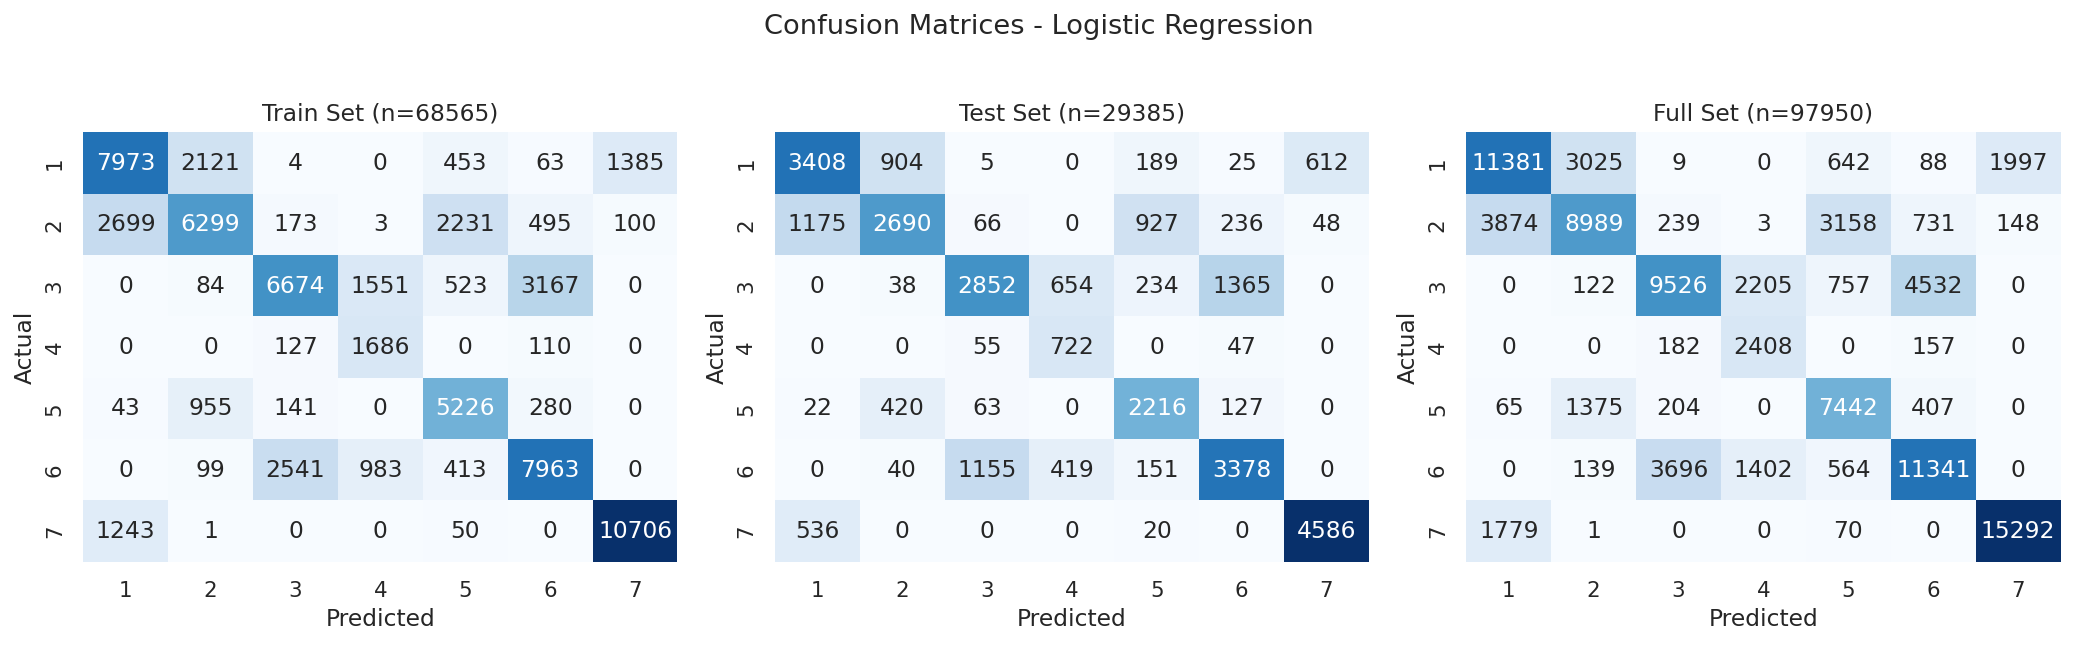

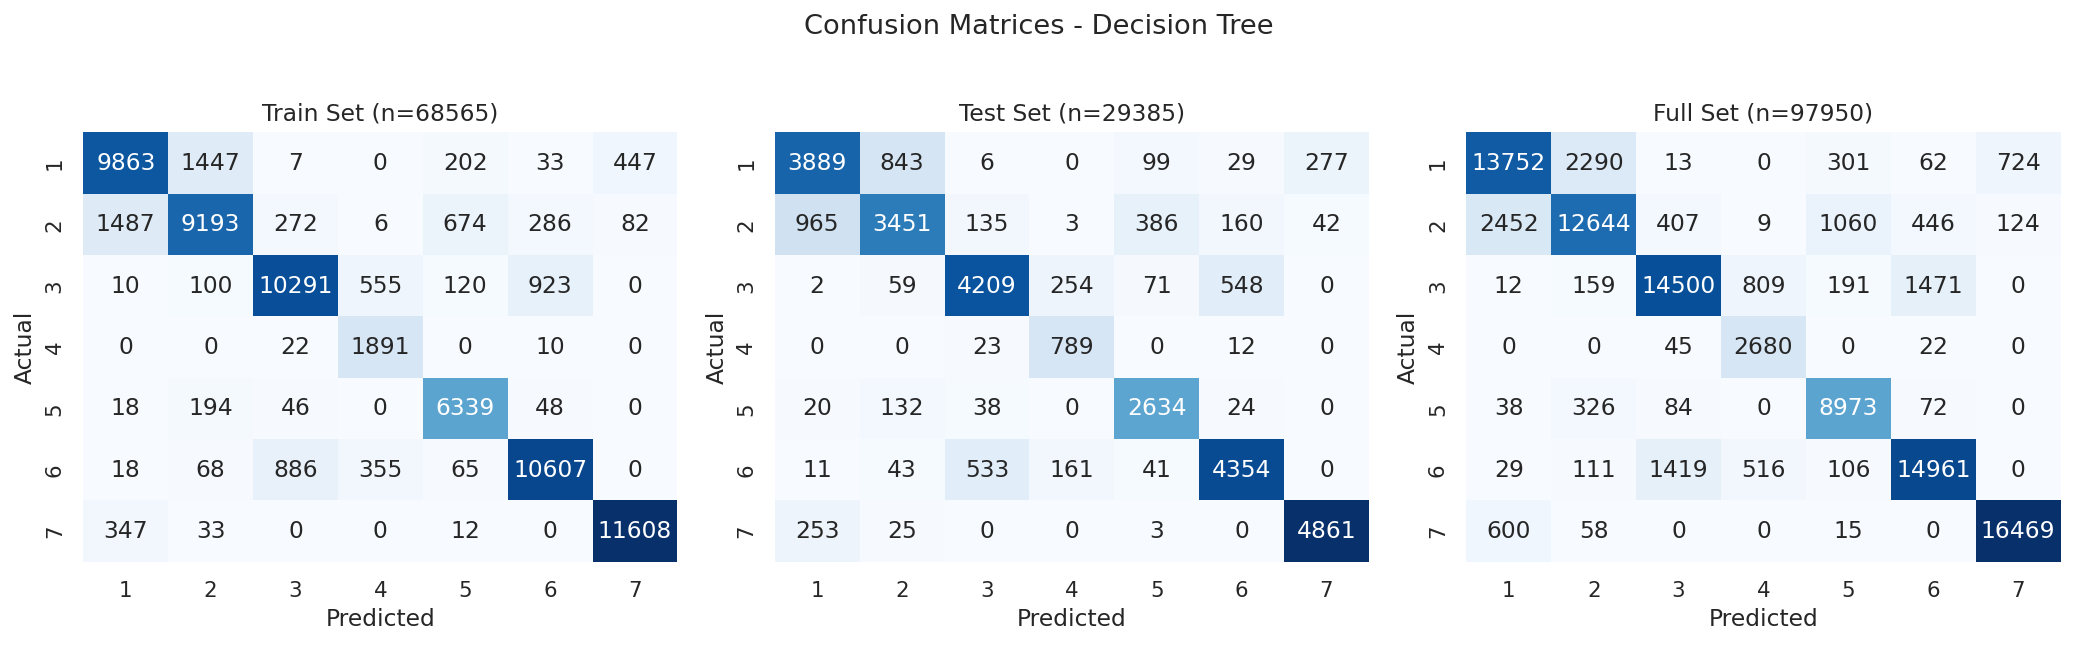


=== Decision Tree - Detailed Classification Report (Test Set) ===
                      precision    recall  f1-score   support

       1: Spruce/Fir       0.76      0.76      0.76      5143
   2: Lodgepole Pine       0.76      0.67      0.71      5142
   3: Ponderosa Pine       0.85      0.82      0.83      5143
4: Cottonwood/Willow       0.65      0.96      0.78       824
            5: Aspen       0.81      0.92      0.87      2848
      6: Douglas-fir       0.85      0.85      0.85      5143
        7: Krummholz       0.94      0.95      0.94      5142

            accuracy                           0.82     29385
           macro avg       0.80      0.85      0.82     29385
        weighted avg       0.82      0.82      0.82     29385


✅ Part 4 Complete: Prediction Training and Testing


In [6]:
# Part 4: Prediction: Training and Testing (FIXED)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

# Define classes
CLASSES = [1, 2, 3, 4, 5, 6, 7]

def train_and_evaluate_models(df, sample_size=120000, random_state=42):
    """Train and evaluate supervised models.
    
    Note: sample_size=120,000 is an upper bound.  Because stratified sampling
    caps each class at sample_size // 7 (≈17,142), the actual sample is
    limited by the minority classes (Cottonwood/Willow: 2,747; Aspen: 9,493),
    yielding approximately 97,950 observations.
    """
    
    # Sample data (since full dataset is large)
    sample = df.groupby('Cover_Type', group_keys=False).apply(
        lambda x: x.sample(min(len(x), sample_size // 7), random_state=random_state)
    )
    sample = sample.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"Sample size: {len(sample)}")
    print("Class distribution in sample:")
    print(sample['Cover_Type'].value_counts().sort_index())
    
    # Prepare features and target
    X = sample[FEATURE_NAMES]
    y = sample['Cover_Type']
    
    # Preprocess
    preprocessor = create_preprocessor()
    X_processed = preprocessor.fit_transform(X)
    # Convert to dense array if sparse
    if hasattr(X_processed, 'toarray'):
        X_processed = X_processed.toarray()
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.3, stratify=y, random_state=random_state
    )
    X_full = X_processed  # Use the sampled data as "full" for this analysis
    y_full = y
    
    print(f"\nTraining set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    print(f"Full set: {len(X_full)} samples")
    
    # 1. Logistic Regression
    print("\n=== Training Logistic Regression ===")
    lr = LogisticRegression(
        solver='saga',
        max_iter=300,
        C=1.0,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1
    )
    lr.fit(X_train, y_train)
    
    # 2. Decision Tree
    print("\n=== Training Decision Tree ===")
    dt = DecisionTreeClassifier(
        max_depth=24,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=random_state
    )
    dt.fit(X_train, y_train)
    
    # Evaluate on all three sets
    models = {
        'Logistic Regression': lr,
        'Decision Tree': dt
    }
    
    datasets = {
        'Train': (X_train, y_train),
        'Test': (X_test, y_test),
        'Full': (X_full, y_full)  # Now this is the sampled data
    }
    
    results = []
    confusion_data = []
    
    for model_name, model in models.items():
        print(f"\n=== {model_name} ===")
        for set_name, (X_set, y_set) in datasets.items():
            y_pred = model.predict(X_set)
            
            # Calculate metrics
            acc = accuracy_score(y_set, y_pred)
            f1 = f1_score(y_set, y_pred, average='weighted')
            
            results.append({
                'model': model_name,
                'dataset': set_name,
                'accuracy': acc,
                'f1_weighted': f1,
                'n_samples': len(y_set)
            })
            
            print(f"{set_name} Set: Accuracy={acc:.4f}, F1={f1:.4f}")
            
            # Store confusion matrix data
            cm = confusion_matrix(y_set, y_pred, labels=CLASSES)
            for i, actual in enumerate(CLASSES):
                for j, predicted in enumerate(CLASSES):
                    confusion_data.append({
                        'model': model_name,
                        'dataset': set_name,
                        'actual': actual,
                        'predicted': predicted,
                        'count': int(cm[i, j])
                    })
    
    results_df = pd.DataFrame(results)
    confusion_df = pd.DataFrame(confusion_data)
    
    return models, results_df, confusion_df, X_train, X_test, y_train, y_test, X_full, y_full

def plot_confusion_matrices(model, model_name, X_train, X_test, y_train, y_test, X_full, y_full):
    """Plot confusion matrices for train, test, and full datasets"""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    
    datasets = [
        ('Train', X_train, y_train),
        ('Test', X_test, y_test),
        ('Full', X_full, y_full)
    ]
    
    for ax, (name, X_data, y_data) in zip(axes, datasets):
        y_pred = model.predict(X_data)
        cm = confusion_matrix(y_data, y_pred, labels=CLASSES)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=CLASSES, yticklabels=CLASSES,
                   ax=ax, cbar=False)
        ax.set_title(f'{name} Set (n={len(y_data)})')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    plt.suptitle(f'Confusion Matrices - {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'confusion_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Run training
models, results_df, confusion_df, X_train, X_test, y_train, y_test, X_full, y_full = train_and_evaluate_models(df)

# Display results summary
print("\n=== Model Performance Summary ===")
display(results_df)

# Plot confusion matrices for both models
plot_confusion_matrices(models['Logistic Regression'], 'Logistic Regression', 
                       X_train, X_test, y_train, y_test, X_full, y_full)

plot_confusion_matrices(models['Decision Tree'], 'Decision Tree',
                       X_train, X_test, y_train, y_test, X_full, y_full)

# Calculate class-level metrics for Decision Tree (best performing)
print("\n=== Decision Tree - Detailed Classification Report (Test Set) ===")
dt_pred = models['Decision Tree'].predict(X_test)
print(classification_report(y_test, dt_pred, target_names=[f"{c}: {COVER_TYPE_NAMES[c]}" for c in CLASSES]))

print("\n✅ Part 4 Complete: Prediction Training and Testing")

## Part 5: Evaluation and Choice of Prediction Model


### Instructions:

1. Calculate metrics: accuracy, precision, recall, F1-score

2. Draw ROC and calculate AUC

3. Improve each model via validation

4. Interpret results to assess strengths, weaknesses, and possible improvements

### Deliverables:

1. Metrics including AUC and ROC plots

2. Validation results description

3. Model performance discussion

Starting Part 5: Evaluation and Choice of Prediction Model...
Training data shape: (68565, 54)
Test data shape: (29385, 54)
Number of classes: 7


CREATING FOUR MODELS FOR COMPARISON

Training all models...
  Training Logistic Regression...


  Training Decision Tree...


  Training Random Forest...


  Training HistGradientBoosting...


All models trained successfully!


Evaluating: Logistic Regression

--- Training Set ---
Accuracy: 0.6786
Precision (macro): 0.6487
Recall (macro): 0.7092
F1 (macro): 0.6620

--- Test Set ---
Accuracy: 0.6756
Precision (macro): 0.6460
Recall (macro): 0.7062
F1 (macro): 0.6597



--- Cross-Validation (5-fold) ---
CV F1 Macro: 0.6608 +/- 0.0025
Macro AUC: 0.9468


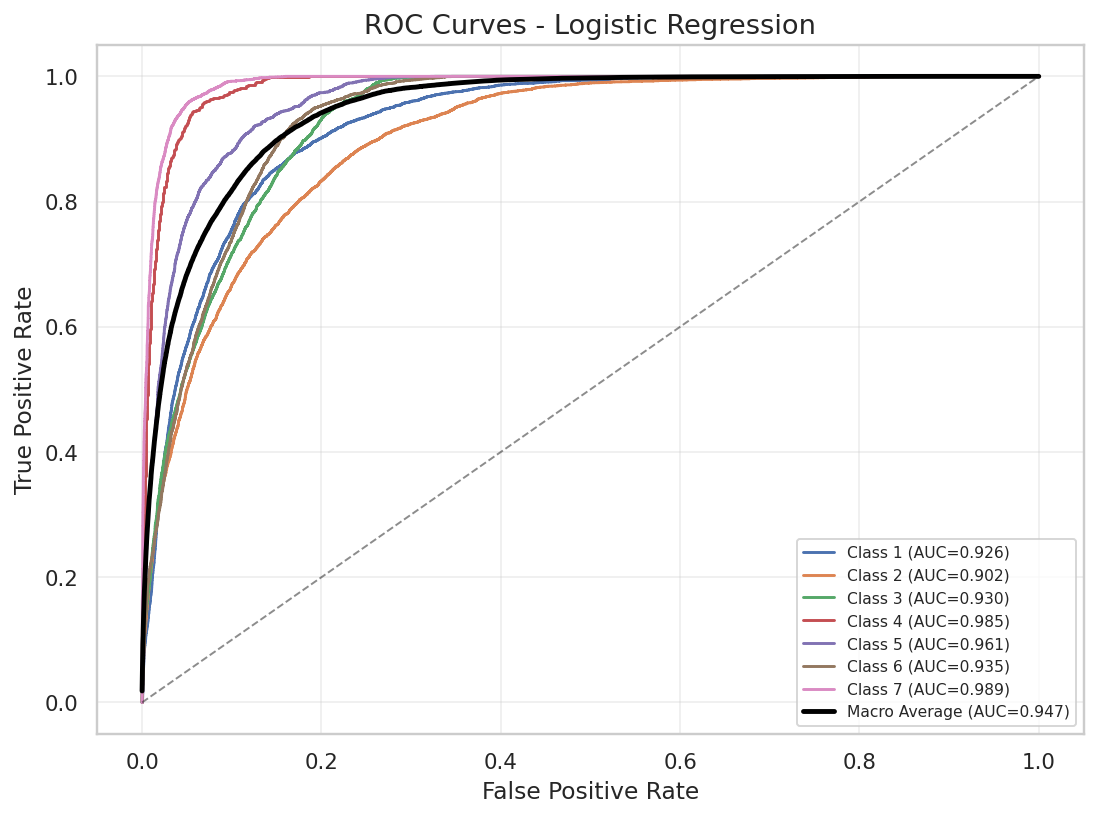


Evaluating: Decision Tree

--- Training Set ---
Accuracy: 0.8720
Precision (macro): 0.8489
Recall (macro): 0.8906
F1 (macro): 0.8650

--- Test Set ---
Accuracy: 0.8231
Precision (macro): 0.8031
Recall (macro): 0.8457
F1 (macro): 0.8194



--- Cross-Validation (5-fold) ---
CV F1 Macro: 0.8107 +/- 0.0043
Macro AUC: 0.9694


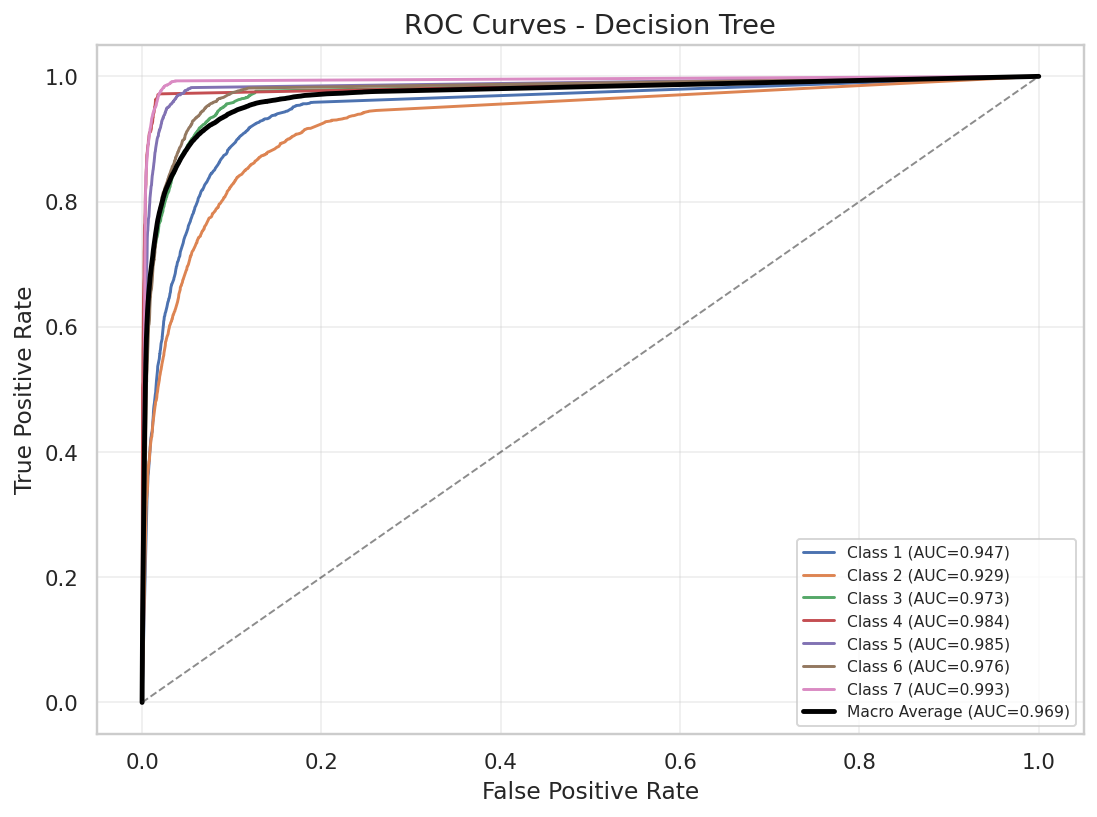


Evaluating: Random Forest



--- Training Set ---
Accuracy: 0.9884
Precision (macro): 0.9826
Recall (macro): 0.9905
F1 (macro): 0.9864

--- Test Set ---
Accuracy: 0.9076
Precision (macro): 0.9025
Recall (macro): 0.9134
F1 (macro): 0.9076



--- Cross-Validation (5-fold) ---
CV F1 Macro: 0.9019 +/- 0.0009
Macro AUC: 0.9923


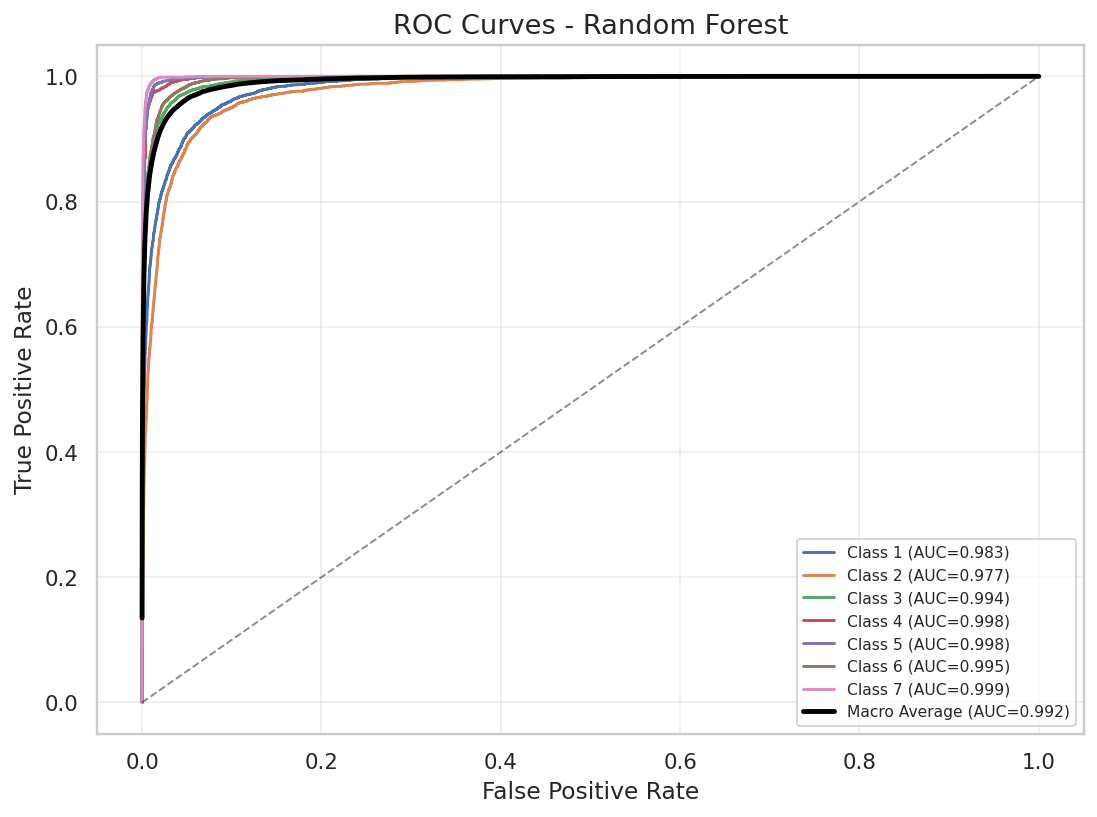


Evaluating: HistGradientBoosting



--- Training Set ---
Accuracy: 0.9378
Precision (macro): 0.9433
Recall (macro): 0.9469
F1 (macro): 0.9449

--- Test Set ---
Accuracy: 0.8951
Precision (macro): 0.8957
Recall (macro): 0.9014
F1 (macro): 0.8982



--- Cross-Validation (5-fold) ---
CV F1 Macro: 0.8946 +/- 0.0030


Macro AUC: 0.9907


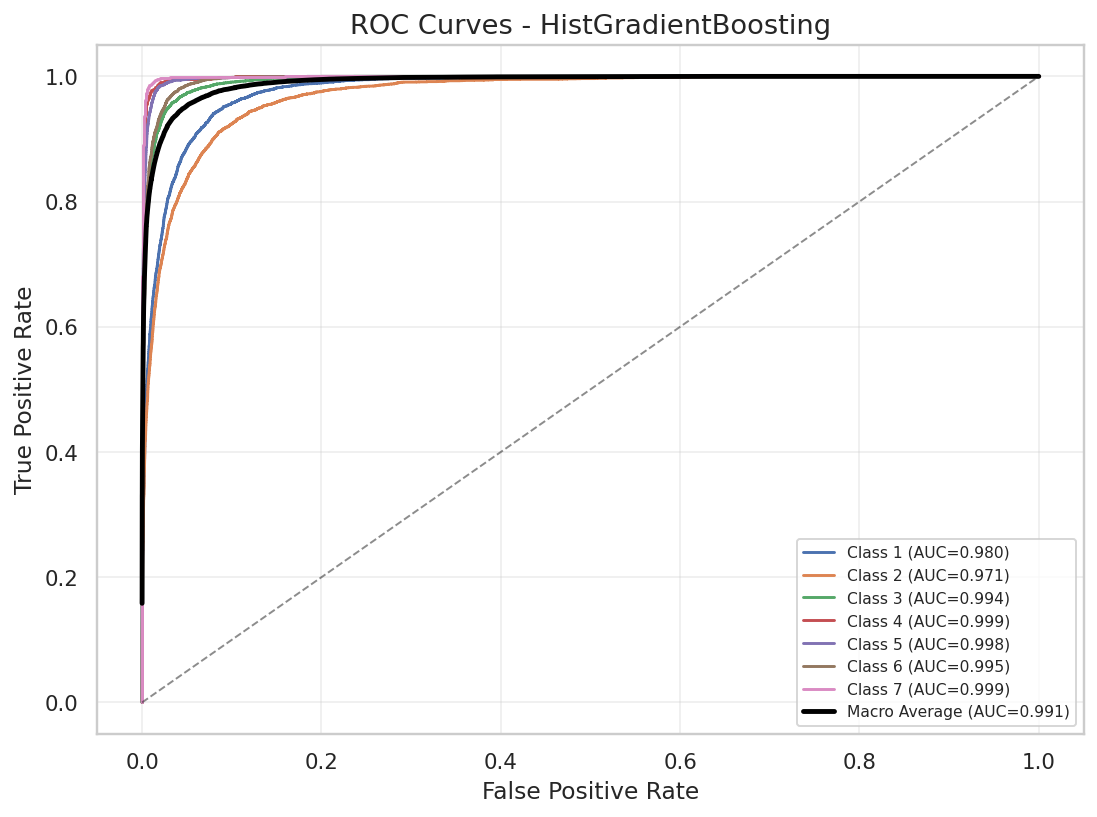


--- Generating Figure: Macro-Averaged One-vs-Rest ROC Curves ---


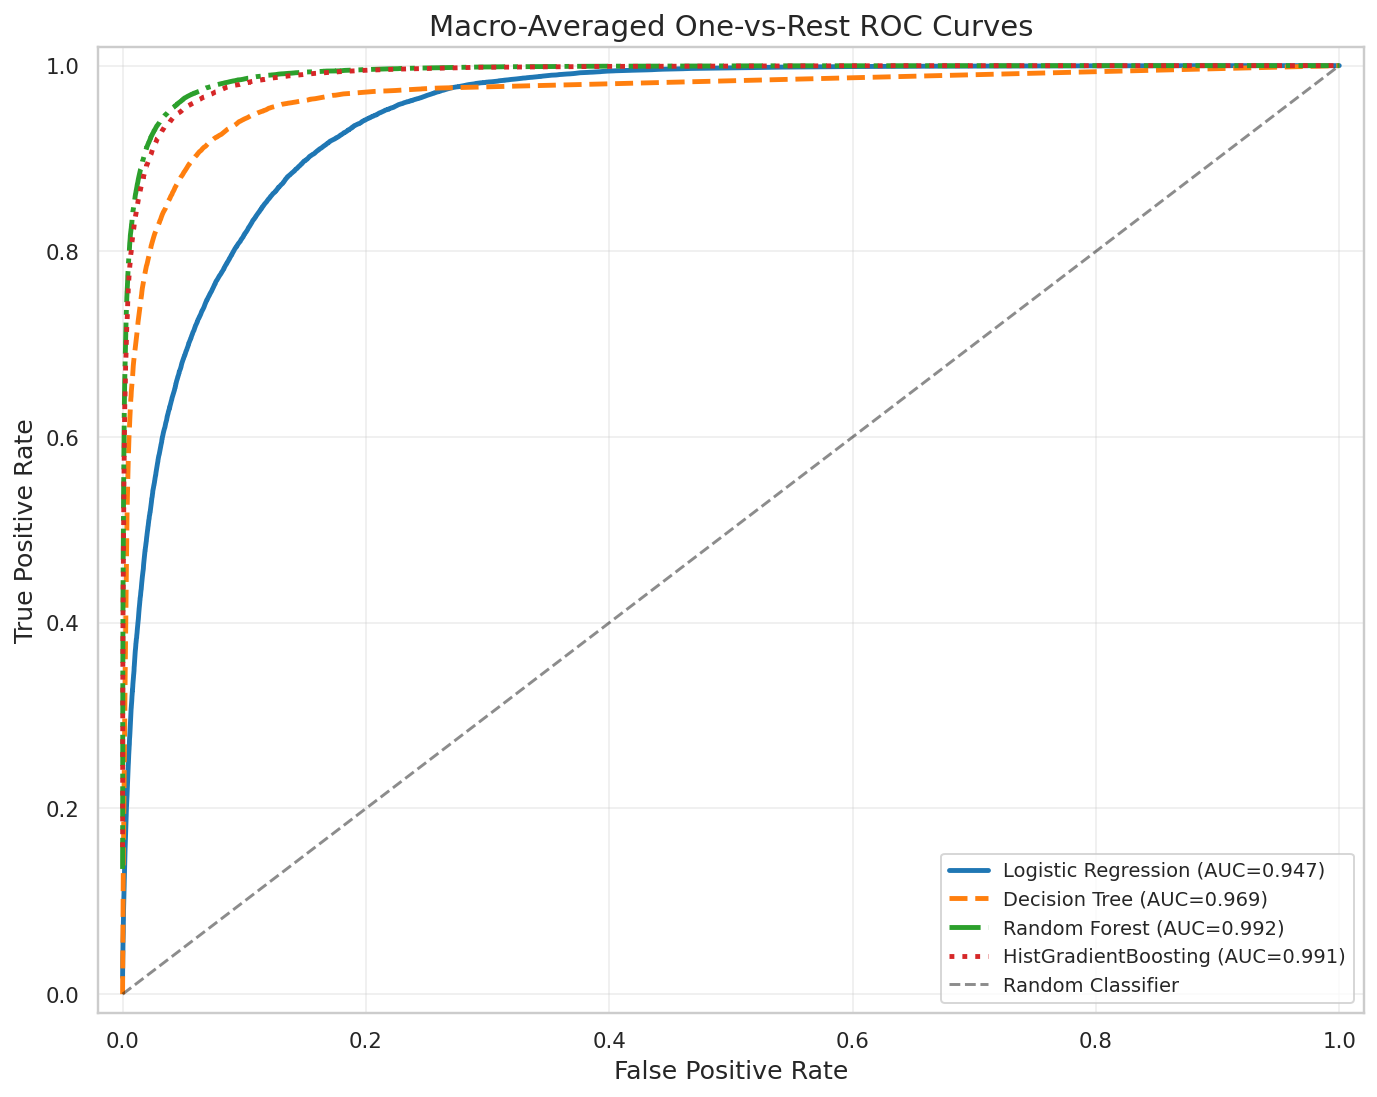


--- Generating Figure: Model Performance Comparison ---


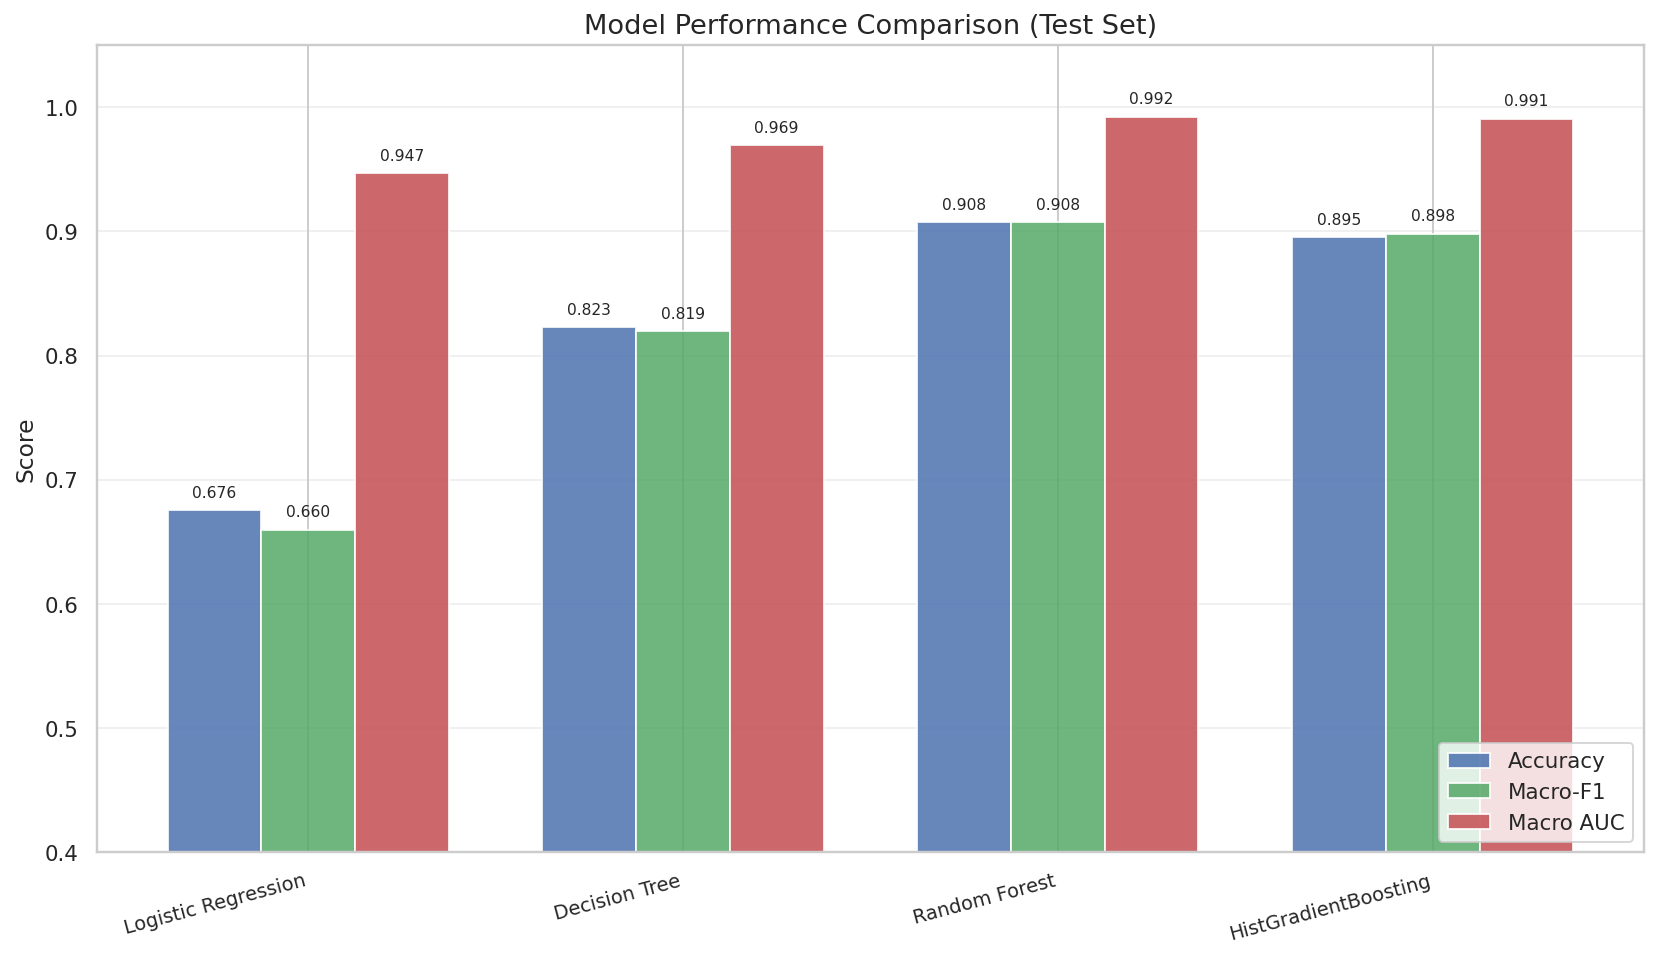


MODEL COMPARISON SUMMARY

=== Test Set Performance ===


,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Logistic Regression,0.6756,0.6460,0.7062,0.6597
1,Decision Tree,0.8231,0.8031,0.8457,0.8194
2,Random Forest,0.9076,0.9025,0.9134,0.9076
3,HistGradientBoosting,0.8951,0.8957,0.9014,0.8982



=== Test Set Performance (with AUC) ===


,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,macro_auc
0,Logistic Regression,0.6756,0.6460,0.7062,0.6597,0.9468
1,Decision Tree,0.8231,0.8031,0.8457,0.8194,0.9694
2,Random Forest,0.9076,0.9025,0.9134,0.9076,0.9923
3,HistGradientBoosting,0.8951,0.8957,0.9014,0.8982,0.9907



=== Overfitting Analysis ===
Logistic Regression: Train F1=0.662, Test F1=0.660, Diff=0.002 -> ✅ No significant overfitting
Decision Tree: Train F1=0.865, Test F1=0.819, Diff=0.046 -> ✅ No significant overfitting
Random Forest: Train F1=0.986, Test F1=0.908, Diff=0.079 -> ⚠️ Mild overfitting
HistGradientBoosting: Train F1=0.945, Test F1=0.898, Diff=0.047 -> ✅ No significant overfitting

✅ Part 5 Complete: Model Evaluation


In [7]:
# ============================================================
# Part 5: Evaluation and Choice of Prediction Model
# ============================================================

from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Define classes (should already be defined from Part 4)
CLASSES = [1, 2, 3, 4, 5, 6, 7]

def evaluate_models_comprehensive(X_train, X_test, y_train, y_test, random_state=42):
    """Comprehensive model evaluation with four models"""
    
    # ============================================================
    # 1. Create all four models
    # ============================================================
    print("\n" + "="*60)
    print("CREATING FOUR MODELS FOR COMPARISON")
    print("="*60)
    
    models = {
        'Logistic Regression': LogisticRegression(
            solver='saga',
            max_iter=300,
            C=1.0,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=24,
            min_samples_leaf=15,
            class_weight='balanced',
            random_state=random_state
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=random_state
        ),
        'HistGradientBoosting': HistGradientBoostingClassifier(
            max_iter=160,
            learning_rate=0.08,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=random_state
        )
    }
    
    # Train all models
    print("\nTraining all models...")
    for name, model in models.items():
        print(f"  Training {name}...")
        model.fit(X_train, y_train)
    print("All models trained successfully!\n")
    
    results = []
    
    # Binarize for ROC
    y_test_bin = label_binarize(y_test, classes=CLASSES)
    n_classes = len(CLASSES)
    
    # Store ROC data for combined plot
    roc_data = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Evaluating: {model_name}")
        print('='*50)
        
        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Training metrics
        print(f"\n--- Training Set ---")
        train_acc = accuracy_score(y_train, y_pred_train)
        train_prec = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
        train_rec = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
        train_f1 = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
        print(f"Accuracy: {train_acc:.4f}")
        print(f"Precision (macro): {train_prec:.4f}")
        print(f"Recall (macro): {train_rec:.4f}")
        print(f"F1 (macro): {train_f1:.4f}")
        
        # Test metrics
        print(f"\n--- Test Set ---")
        test_acc = accuracy_score(y_test, y_pred_test)
        test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        test_rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        test_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        print(f"Accuracy: {test_acc:.4f}")
        print(f"Precision (macro): {test_prec:.4f}")
        print(f"Recall (macro): {test_rec:.4f}")
        print(f"F1 (macro): {test_f1:.4f}")
        
        # Store results
        results.append({
            'model': model_name,
            'train_accuracy': train_acc,
            'train_precision_macro': train_prec,
            'train_recall_macro': train_rec,
            'train_f1_macro': train_f1,
            'test_accuracy': test_acc,
            'test_precision_macro': test_prec,
            'test_recall_macro': test_rec,
            'test_f1_macro': test_f1
        })
        
        # ROC AUC (all models have predict_proba)
        if hasattr(model, 'predict_proba'):
            # Cross-validation
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
            print(f"\n--- Cross-Validation (5-fold) ---")
            print(f"CV F1 Macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
            
            # ROC Curve
            y_prob = model.predict_proba(X_test)
            
            # Calculate per-class ROC
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            
            # Macro average
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= n_classes
            macro_auc = auc(all_fpr, mean_tpr)
            
            print(f"Macro AUC: {macro_auc:.4f}")
            
            # Store ROC data for combined plot
            roc_data[model_name] = {
                'all_fpr': all_fpr,
                'mean_tpr': mean_tpr,
                'macro_auc': macro_auc,
                'fpr': fpr,
                'tpr': tpr,
                'roc_auc': roc_auc
            }
            
            # ============================================================
            # Figure: Individual ROC Curves for each model (per-class)
            # ============================================================
            plt.figure(figsize=(8, 6))
            for i in range(n_classes):
                plt.plot(fpr[i], tpr[i], lw=1.5, 
                        label=f'Class {CLASSES[i]} (AUC={roc_auc[i]:.3f})')
            plt.plot(all_fpr, mean_tpr, lw=2.5, color='black', 
                    label=f'Macro Average (AUC={macro_auc:.3f})')
            plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
            plt.xlabel('False Positive Rate', fontsize=12)
            plt.ylabel('True Positive Rate', fontsize=12)
            plt.title(f'ROC Curves - {model_name}', fontsize=14)
            plt.legend(loc='lower right', fontsize=8)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(FIG_DIR / f'roc_{model_name.lower().replace(" ", "_")}.png', dpi=300)
            plt.show()
            plt.close()
    
    # ============================================================
    # Figure: Macro-Averaged One-vs-Rest ROC Curves (All Models Combined)
    # ============================================================
    print("\n--- Generating Figure: Macro-Averaged One-vs-Rest ROC Curves ---")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Colors and line styles for 4 models
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
    line_styles = ['-', '--', '-.', ':']
    model_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'HistGradientBoosting']
    
    for idx, name in enumerate(model_order):
        if name in roc_data:
            data = roc_data[name]
            color = colors[idx % len(colors)]
            linestyle = line_styles[idx % len(line_styles)]
            ax.plot(data['all_fpr'], data['mean_tpr'], lw=2.5, 
                    color=color, linestyle=linestyle,
                    label=f'{name} (AUC={data["macro_auc"]:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=13)
    ax.set_ylabel('True Positive Rate', fontsize=13)
    ax.set_title('Macro-Averaged One-vs-Rest ROC Curves', fontsize=15)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'roc_ovr_models.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # Figure: Model Performance Comparison (Bar Chart)
    # ============================================================
    print("\n--- Generating Figure: Model Performance Comparison ---")
    
    results_df = pd.DataFrame(results)
    model_names = results_df['model'].values
    accuracies = results_df['test_accuracy'].values
    f1_macros = results_df['test_f1_macro'].values
    
    # Get AUC values from roc_data
    auc_values = []
    for name in model_names:
        if name in roc_data:
            auc_values.append(roc_data[name]['macro_auc'])
        else:
            auc_values.append(np.nan)
    
    x = np.arange(len(model_names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 7))
    bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='#4C72B0', alpha=0.85)
    bars2 = ax.bar(x, f1_macros, width, label='Macro-F1', color='#55A868', alpha=0.85)
    bars3 = ax.bar(x + width, auc_values, width, label='Macro AUC', color='#C44E52', alpha=0.85)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison (Test Set)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10, rotation=15, ha='right')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.4, 1.05)
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            if not np.isnan(bar.get_height()):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'model_comparison_f1_auc.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return models, pd.DataFrame(results), roc_data


# ============================================================
# RUN MODEL EVALUATION
# ============================================================

print("Starting Part 5: Evaluation and Choice of Prediction Model...")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(CLASSES)}")
print()

models, eval_results, roc_data = evaluate_models_comprehensive(X_train, X_test, y_train, y_test)

# Display comparison
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comprehensive comparison table
comparison_df = eval_results[['model', 'test_accuracy', 'test_precision_macro', 
                              'test_recall_macro', 'test_f1_macro']].round(4)
print("\n=== Test Set Performance ===")
display(comparison_df)

# Add AUC values to comparison
auc_df = pd.DataFrame([
    {'model': name, 'macro_auc': data['macro_auc']} 
    for name, data in roc_data.items()
])
comparison_df = comparison_df.merge(auc_df, on='model', how='left')
print("\n=== Test Set Performance (with AUC) ===")
display(comparison_df.round(4))

# Determine if models overfit
print("\n=== Overfitting Analysis ===")
for _, row in eval_results.iterrows():
    train_f1 = row['train_f1_macro']
    test_f1 = row['test_f1_macro']
    diff = train_f1 - test_f1
    if diff > 0.1:
        status = "⚠️ Possible overfitting"
    elif diff > 0.05:
        status = "⚠️ Mild overfitting"
    else:
        status = "✅ No significant overfitting"
    print(f"{row['model']}: Train F1={train_f1:.3f}, Test F1={test_f1:.3f}, Diff={diff:.3f} -> {status}")

print("\n✅ Part 5 Complete: Model Evaluation")

In [8]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)
# ============================================================
# Pre-compute predictions once, bootstrap the metric computation
print("="*60)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS (1000 resamples)")
print("="*60)

n_bootstrap = 1000
np.random.seed(42)
n_test = len(y_test)
idx_all = np.arange(n_test)

bootstrap_results = {}

for model_name, model in models.items():
    # Pre-compute predictions once
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    y_test_np = y_test.values  # numpy array for label-based indexing safety
    
    f1_samples = []
    recall_samples = {c: [] for c in CLASSES}
    acc_samples = []
    
    for _ in range(n_bootstrap):
        boot_idx = np.random.choice(idx_all, size=n_test, replace=True)
        y_test_boot = y_test_np[boot_idx]
        y_pred_boot = y_pred[boot_idx]
        
        f1_samples.append(f1_score(y_test_boot, y_pred_boot, average='macro', zero_division=0))
        acc_samples.append(accuracy_score(y_test_boot, y_pred_boot))
        for c in CLASSES:
            mask_c = (y_test_boot == c)
            if mask_c.sum() > 0:
                recall_samples[c].append(recall_score(y_test_boot, y_pred_boot, labels=[c], average='macro', zero_division=0))
            else:
                recall_samples[c].append(np.nan)
    
    f1_ci = (np.percentile(f1_samples, 2.5), np.percentile(f1_samples, 97.5))
    acc_ci = (np.percentile(acc_samples, 2.5), np.percentile(acc_samples, 97.5))
    
    bootstrap_results[model_name] = {
        'f1_macro': np.mean(f1_samples),
        'f1_ci_95': f1_ci,
        'accuracy': np.mean(acc_samples),
        'acc_ci_95': acc_ci,
        'per_class_recall': {c: (np.nanmean(recall_samples[c]), 
                                 (np.percentile([r for r in recall_samples[c] if not np.isnan(r)], 2.5),
                                  np.percentile([r for r in recall_samples[c] if not np.isnan(r)], 97.5)))
                            for c in CLASSES}
    }
    
    print(f"\n{model_name}:")
    print(f"  Macro-F1:       {bootstrap_results[model_name]['f1_macro']:.4f}  (95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}])")
    print(f"  Accuracy:       {bootstrap_results[model_name]['accuracy']:.4f}  (95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}])")
    for c in CLASSES:
        r_mean, r_ci = bootstrap_results[model_name]['per_class_recall'][c]
        print(f"  Class {c} ({COVER_TYPE_NAMES[c]}): Recall = {r_mean:.4f}  (95% CI: [{r_ci[0]:.4f}, {r_ci[1]:.4f}])")

print("\n✅ Bootstrap CI complete!")

# --- Bootstrap CI Summary Table ---
print("\n" + "="*60)
print("BOOTSTRAP CI SUMMARY TABLE (for report)")
print("="*60)
for model_name in ['Random Forest', 'HistGradientBoosting']:
    br = bootstrap_results[model_name]
    print(f"{model_name}: Macro-F1={br['f1_macro']:.4f} [{br['f1_ci_95'][0]:.4f}, {br['f1_ci_95'][1]:.4f}]")


BOOTSTRAP 95% CONFIDENCE INTERVALS (1000 resamples)



Logistic Regression:
  Macro-F1:       0.6597  (95% CI: [0.6539, 0.6652])
  Accuracy:       0.6755  (95% CI: [0.6702, 0.6807])
  Class 1 (Spruce/Fir): Recall = 0.6627  (95% CI: [0.6495, 0.6754])
  Class 2 (Lodgepole Pine): Recall = 0.5230  (95% CI: [0.5093, 0.5370])
  Class 3 (Ponderosa Pine): Recall = 0.5544  (95% CI: [0.5406, 0.5679])
  Class 4 (Cottonwood/Willow): Recall = 0.8770  (95% CI: [0.8547, 0.8987])
  Class 5 (Aspen): Recall = 0.7783  (95% CI: [0.7644, 0.7928])
  Class 6 (Douglas-fir): Recall = 0.6567  (95% CI: [0.6435, 0.6691])
  Class 7 (Krummholz): Recall = 0.8919  (95% CI: [0.8833, 0.9006])



Decision Tree:
  Macro-F1:       0.8194  (95% CI: [0.8146, 0.8243])
  Accuracy:       0.8231  (95% CI: [0.8185, 0.8274])
  Class 1 (Spruce/Fir): Recall = 0.7560  (95% CI: [0.7440, 0.7680])
  Class 2 (Lodgepole Pine): Recall = 0.6713  (95% CI: [0.6585, 0.6838])
  Class 3 (Ponderosa Pine): Recall = 0.8184  (95% CI: [0.8080, 0.8288])
  Class 4 (Cottonwood/Willow): Recall = 0.9575  (95% CI: [0.9427, 0.9705])
  Class 5 (Aspen): Recall = 0.9248  (95% CI: [0.9157, 0.9344])
  Class 6 (Douglas-fir): Recall = 0.8468  (95% CI: [0.8364, 0.8564])
  Class 7 (Krummholz): Recall = 0.9452  (95% CI: [0.9390, 0.9511])



Random Forest:
  Macro-F1:       0.9076  (95% CI: [0.9036, 0.9113])
  Accuracy:       0.9076  (95% CI: [0.9042, 0.9110])
  Class 1 (Spruce/Fir): Recall = 0.8424  (95% CI: [0.8320, 0.8529])
  Class 2 (Lodgepole Pine): Recall = 0.8165  (95% CI: [0.8058, 0.8271])
  Class 3 (Ponderosa Pine): Recall = 0.9195  (95% CI: [0.9120, 0.9270])
  Class 4 (Cottonwood/Willow): Recall = 0.9262  (95% CI: [0.9076, 0.9440])
  Class 5 (Aspen): Recall = 0.9646  (95% CI: [0.9580, 0.9714])
  Class 6 (Douglas-fir): Recall = 0.9426  (95% CI: [0.9362, 0.9491])
  Class 7 (Krummholz): Recall = 0.9827  (95% CI: [0.9790, 0.9861])



HistGradientBoosting:
  Macro-F1:       0.8982  (95% CI: [0.8944, 0.9020])
  Accuracy:       0.8952  (95% CI: [0.8915, 0.8986])
  Class 1 (Spruce/Fir): Recall = 0.8294  (95% CI: [0.8194, 0.8394])
  Class 2 (Lodgepole Pine): Recall = 0.7748  (95% CI: [0.7643, 0.7859])
  Class 3 (Ponderosa Pine): Recall = 0.9050  (95% CI: [0.8968, 0.9129])
  Class 4 (Cottonwood/Willow): Recall = 0.9155  (95% CI: [0.8972, 0.9340])
  Class 5 (Aspen): Recall = 0.9566  (95% CI: [0.9496, 0.9639])
  Class 6 (Douglas-fir): Recall = 0.9452  (95% CI: [0.9385, 0.9508])
  Class 7 (Krummholz): Recall = 0.9841  (95% CI: [0.9807, 0.9876])

✅ Bootstrap CI complete!

BOOTSTRAP CI SUMMARY TABLE (for report)
Random Forest: Macro-F1=0.9076 [0.9036, 0.9113]
HistGradientBoosting: Macro-F1=0.8982 [0.8944, 0.9020]


## Part 6: Open-Ended Exploration

### Instructions:

1. Model improvement: Investigate impact of model complexity, error metrics, and regularization

2. Model Comparison: Compare at least three different model classes using cross-validation

3. Feature Engineering and Selection: Create new features or select subsets using feature importance

4. Hyperparameter Tuning: Optimize model parameters using grid search or random search

### Deliverables:

1. Description of chosen techniques and implementation

2. Results (improved metrics, visualizations) and insights gained

3. Comparison of at least three model classes

Starting Open-Ended Exploration...
Training data shape: (68565, 54)
Test data shape: (29385, 54)
Number of classes: 7

OPEN-ENDED EXPLORATION

1. ADVANCED MODEL COMPARISON


Random Forest (120 trees):
  Accuracy: 0.9076, F1 Macro: 0.9076
  AUC Macro: 0.9923
  Training time: 2.58 sec



Gradient Boosting (120 iter):
  Accuracy: 0.8795, F1 Macro: 0.8833
  AUC Macro: 0.9880
  Training time: 235.29 sec



Random Forest (200 trees):
  Accuracy: 0.9085, F1 Macro: 0.9083
  AUC Macro: 0.9924
  Training time: 4.22 sec


2. FEATURE ENGINEERING: POLYNOMIAL FEATURES
Top 5 features for polynomial features: ['Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Fire_Points', 'Horizontal_Distance_To_Roadways', 'Elevation']
Original features (selected): 5
Polynomial features: 20

Training Logistic Regression with Polynomial Features...


LR + Polynomial Features Test F1 Macro: 0.5844

Tuning Logistic Regression with Polynomial Features...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best parameters: {'C': 10.0, 'penalty': 'l2'}
Best CV F1 Macro: 0.5852
Tuned LR + Polynomial Test F1 Macro: 0.5845

--- Controlled Comparison: RF on 5 Features ---


RF (5 features) Test F1 Macro: 0.8774

--- Controlled Comparison: LR on All 54 Features (L2) ---
  Memory estimate: SAGA gradient table ≈ 198 MB; total peak ≈ 226 MB


LR (54 features, L2) Test F1 Macro: 0.6597  (fit time: 22.5s)

--- Polynomial Features: Controlled Comparison Summary ---
  LR (5 features):          F1 Macro ≈ 0.5843647946767021
  LR + Poly (5→20 feat):    F1 Macro = 0.5844
  RF (5 features):          F1 Macro = 0.8774
  LR (54 features, L2):     F1 Macro = 0.6597
  RF (54 features, baseline):F1 Macro = 0.907
  → Gap decomposition: feature count vs. polynomial vs. nonlinearity

3. FEATURE IMPORTANCE ANALYSIS
Top 15 most important features:
                               feature  importance
0                            Elevation    0.243481
5      Horizontal_Distance_To_Roadways    0.101682
9   Horizontal_Distance_To_Fire_Points    0.078754
3     Horizontal_Distance_To_Hydrology    0.060410
4       Vertical_Distance_To_Hydrology    0.047877
6                        Hillshade_9am    0.042913
1                               Aspect    0.041384
13                   Wilderness_Area_4    0.041375
8                        Hillshade_3pm    0.


Top 10 features by permutation importance:
                               feature  importance_mean  importance_std
0                            Elevation         0.370548        0.006029
5      Horizontal_Distance_To_Roadways         0.136467        0.002169
9   Horizontal_Distance_To_Fire_Points         0.104230        0.002479
3     Horizontal_Distance_To_Hydrology         0.062608        0.003657
23                        Soil_Type_10         0.023198        0.000982
4       Vertical_Distance_To_Hydrology         0.021313        0.002470
10                   Wilderness_Area_1         0.019516        0.000708
52                        Soil_Type_39         0.014954        0.000758
12                   Wilderness_Area_3         0.013314        0.001594
6                        Hillshade_9am         0.012936        0.002221


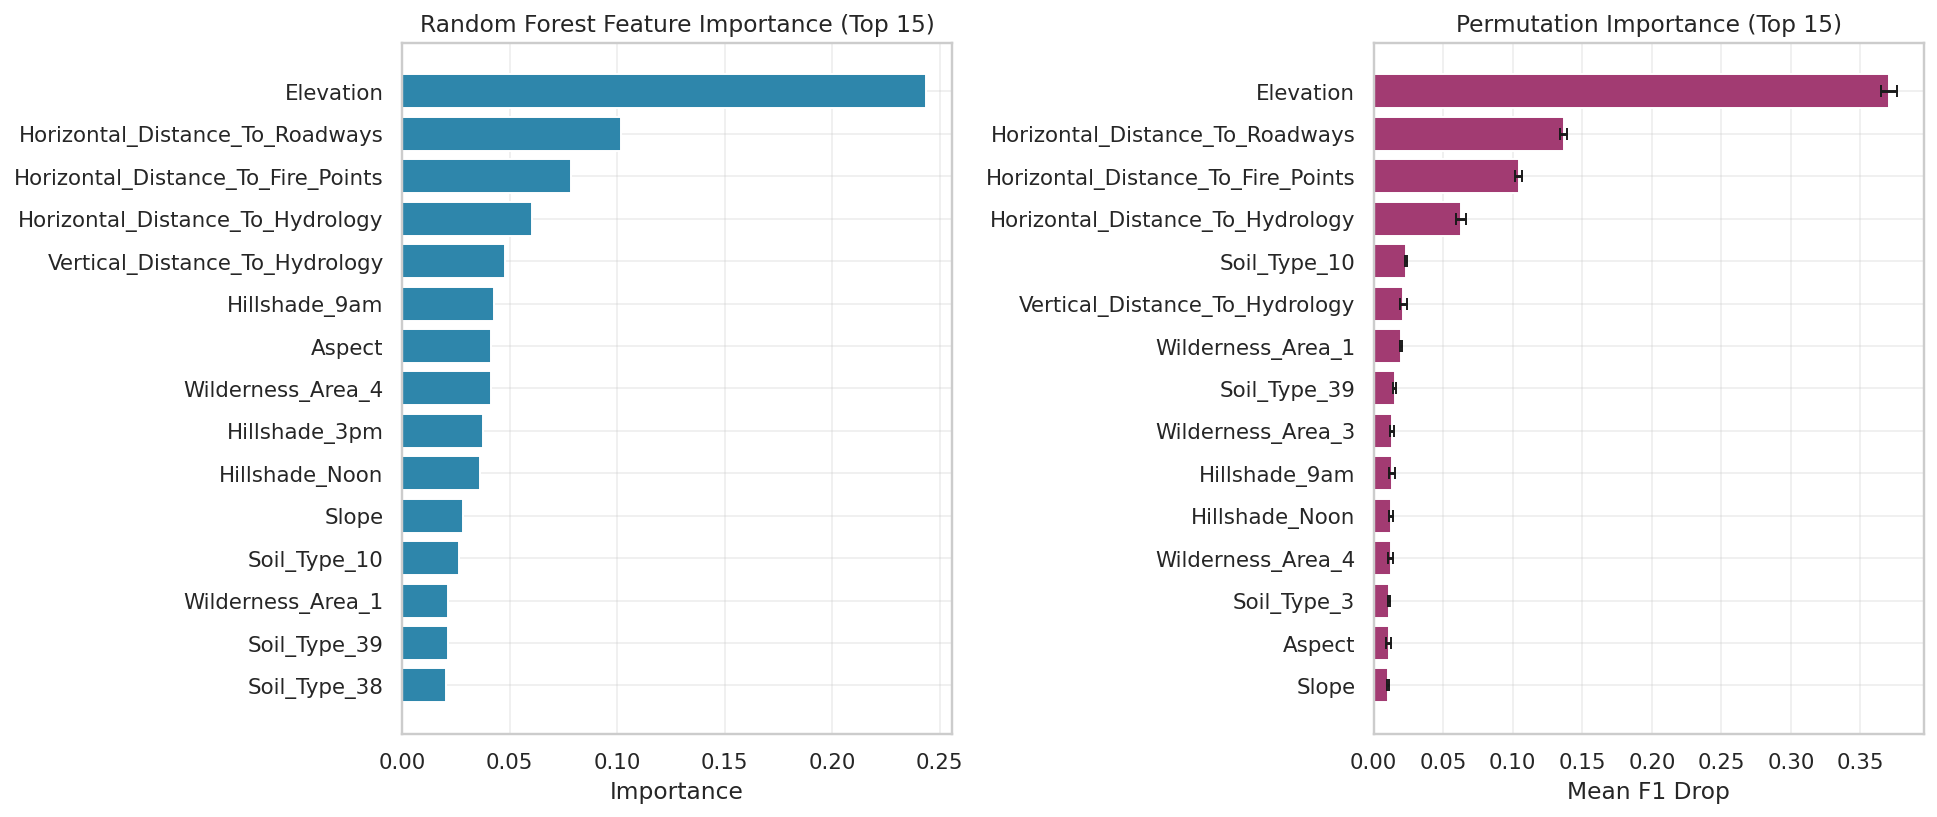


4. FEATURE SELECTION USING IMPORTANCE


Top 10 features: F1 Macro = 0.8978


Top 20 features: F1 Macro = 0.9026


Top 30 features: F1 Macro = 0.9067


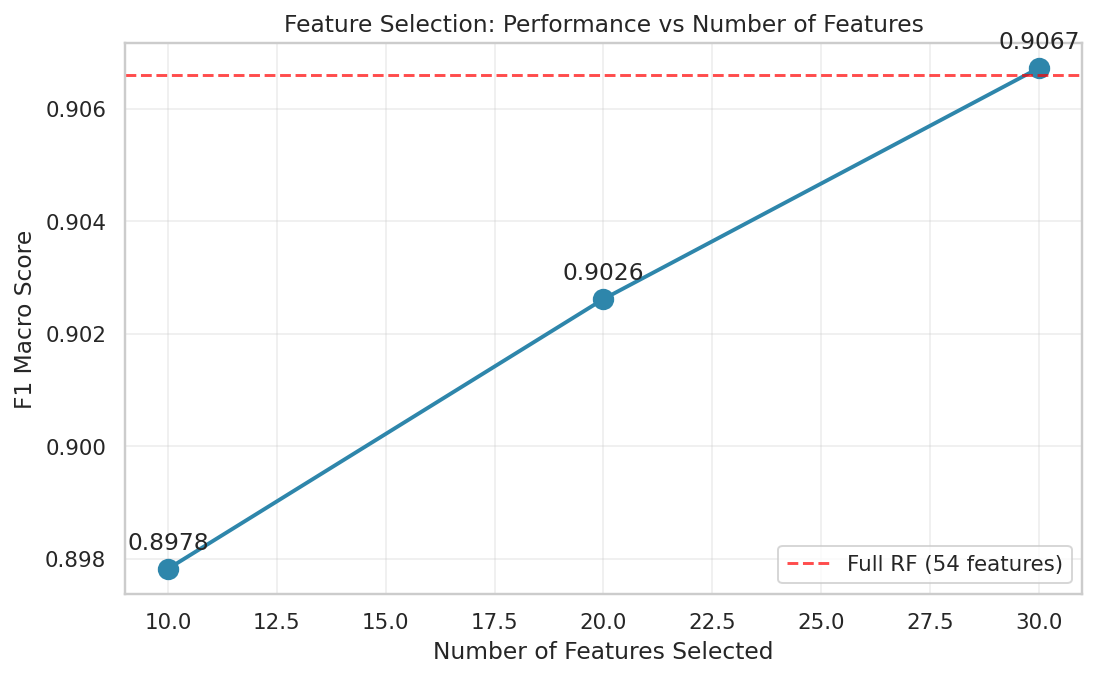


5. HYPERPARAMETER TUNING
Tuning on 30000 samples

--- Tuning Decision Tree ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits


Best parameters: {'max_depth': 30, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV F1 Macro: 0.7690
Tuned DT Test F1 Macro: 0.7970


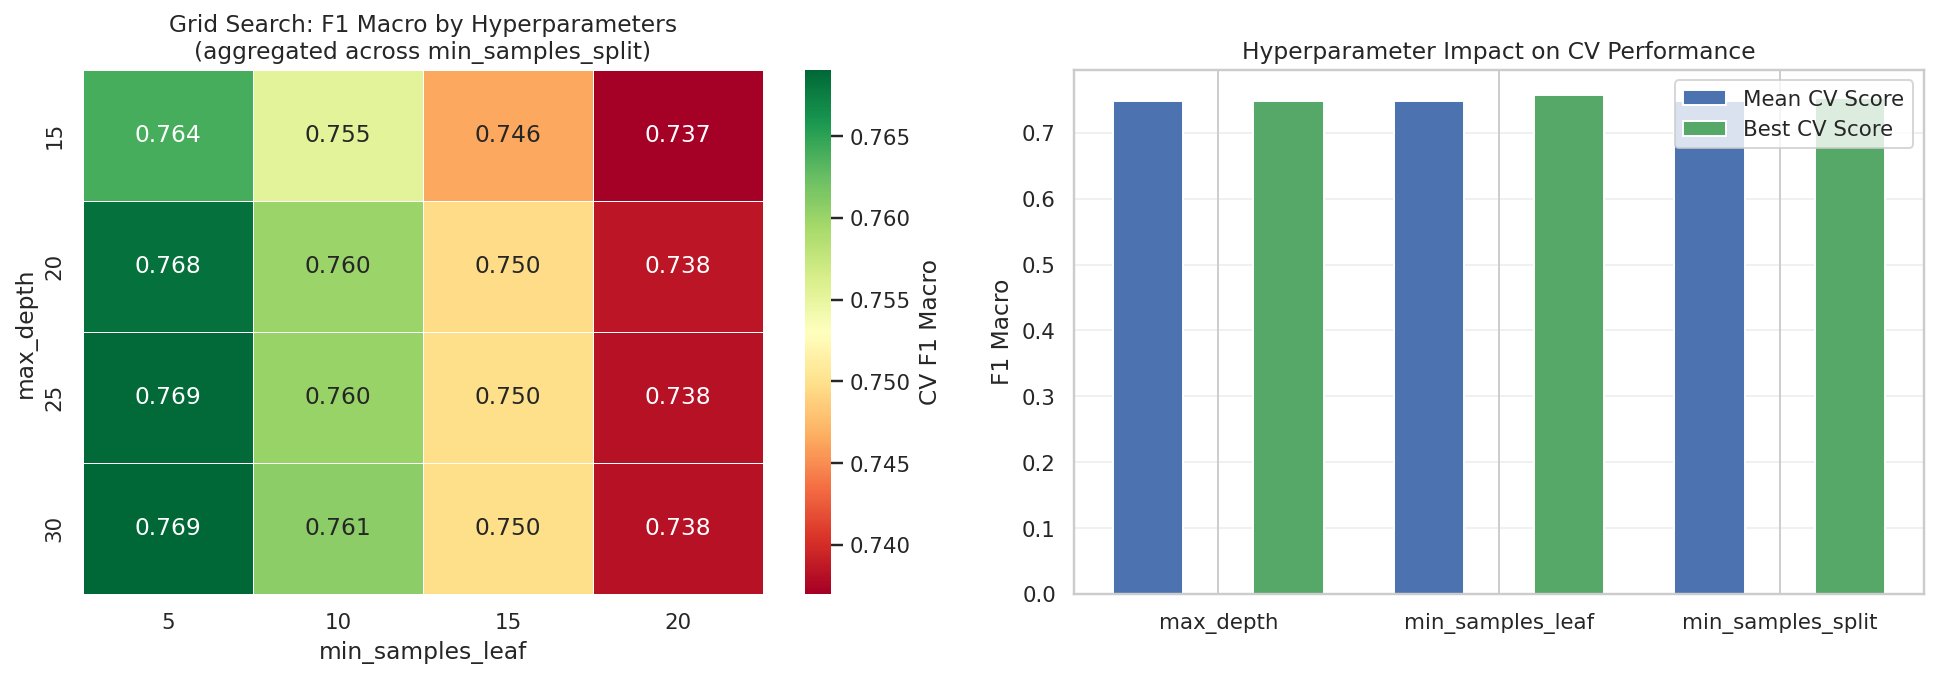


--- Tuning Random Forest ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits


RF Best params: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 120}
RF Best CV F1 Macro: 0.8754


RF Tuned Test F1 Macro: 0.8856  (baseline: 0.9076, Δ = -0.0220)

--- Tuning HistGradientBoosting ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits


HGB Best params: {'learning_rate': 0.08, 'max_iter': 200, 'max_leaf_nodes': 41}
HGB Best CV F1 Macro: 0.8787


HGB Tuned Test F1 Macro: 0.8886  (baseline: 0.8982, Δ = -0.0096)

--- Hyperparameter Tuning Summary ---
  Decision Tree:         baseline 0.8191 → tuned 0.7970 (Δ = -0.0221)
  Random Forest:         baseline 0.9076 → tuned 0.8856 (Δ = -0.0220)
  HistGradientBoosting:  baseline 0.8982 → tuned 0.8886 (Δ = -0.0096)
  → DT degrades (overfits validation folds on limited subset); RF/HGB show diminishing returns,
     consistent with their built-in regularization mechanisms.

6. SMOTE FOR CLASS IMBALANCE
Training with SMOTE...


SMOTE + DT Test F1 Macro: 0.8294


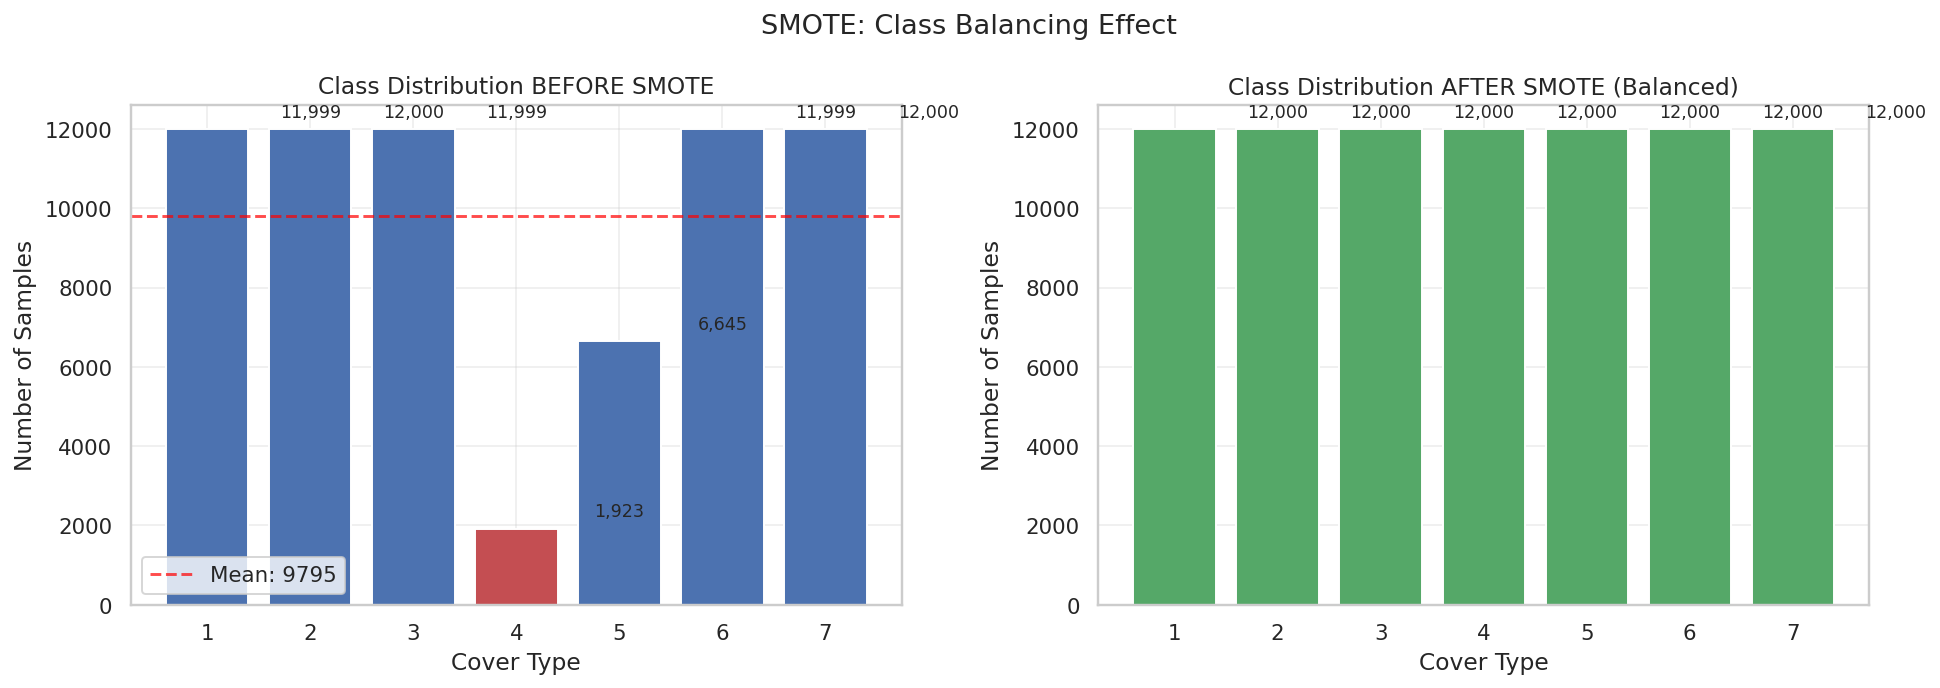

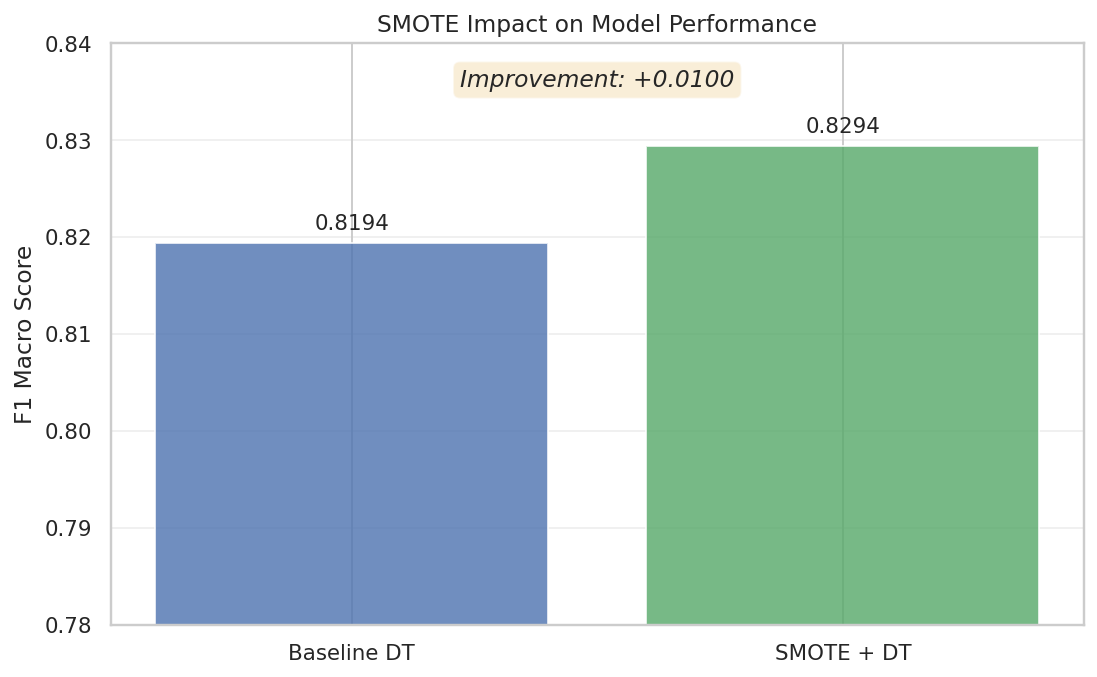

Original class distribution in training:
Cover_Type
1    11999
2    12000
3    11999
4     1923
5     6645
6    11999
7    12000
Name: count, dtype: int64

After SMOTE (balanced):
Cover_Type
1    12000
2    12000
3    12000
4    12000
5    12000
6    12000
7    12000
Name: count, dtype: int64

7. MODEL CALIBRATION
Random Forest Brier Score: 0.0239


Gradient Boosting Brier Score: 0.0262


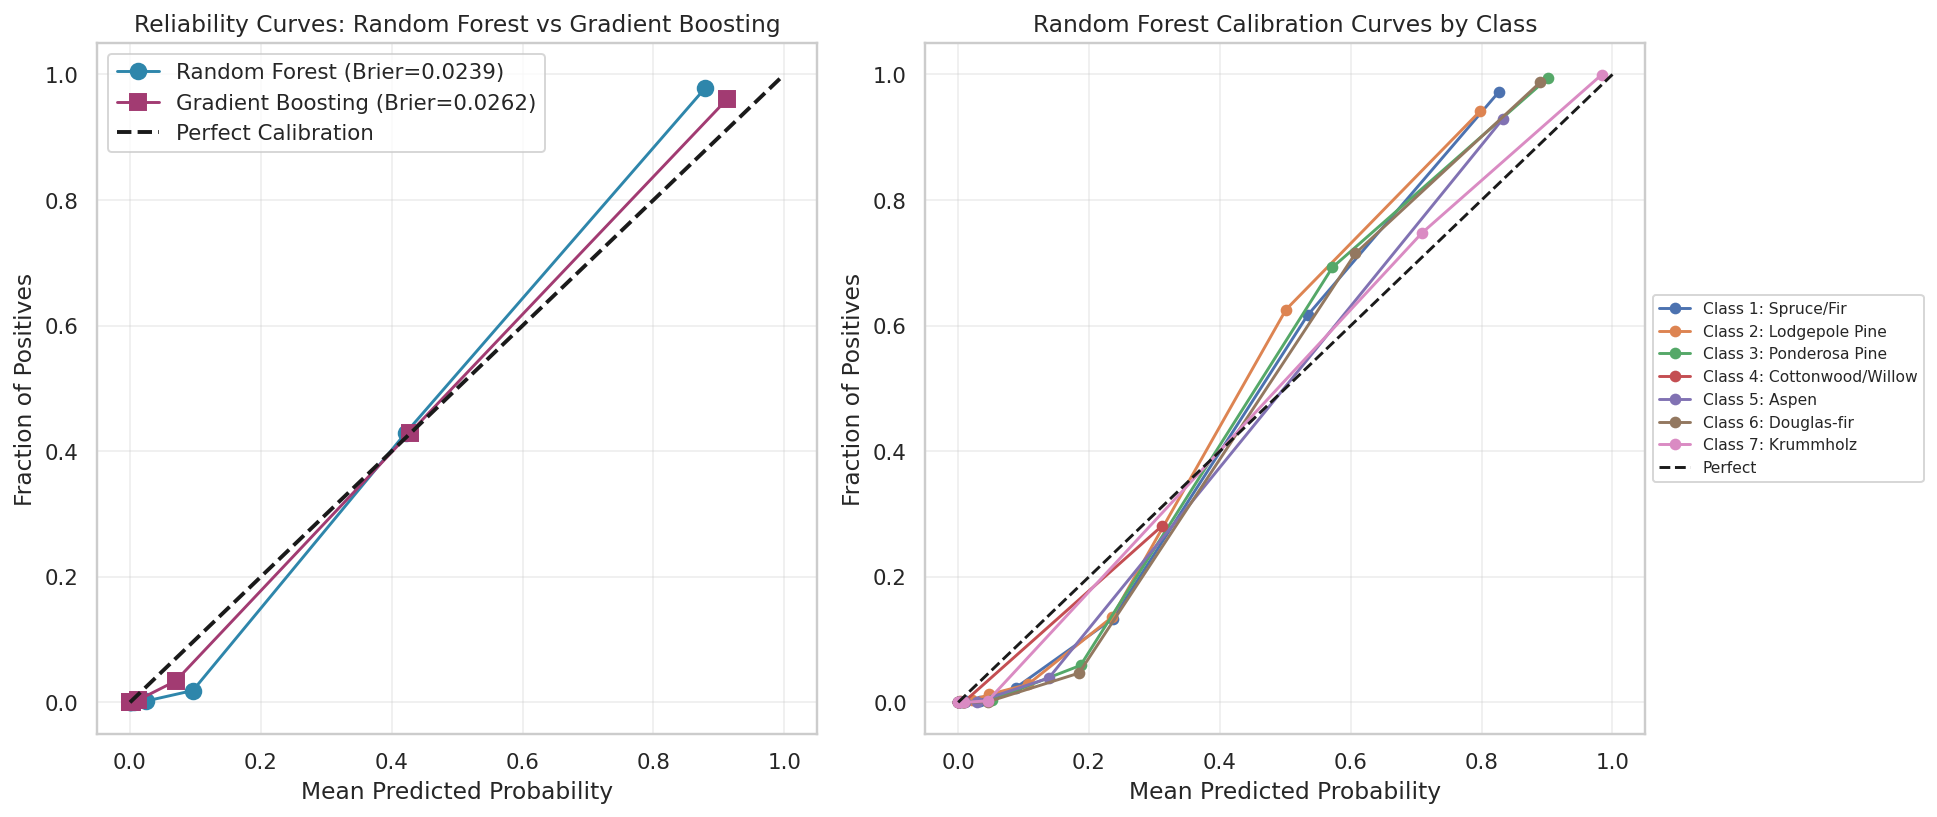


Training calibrated model...


Calibrated Random Forest Brier Score: 0.0214


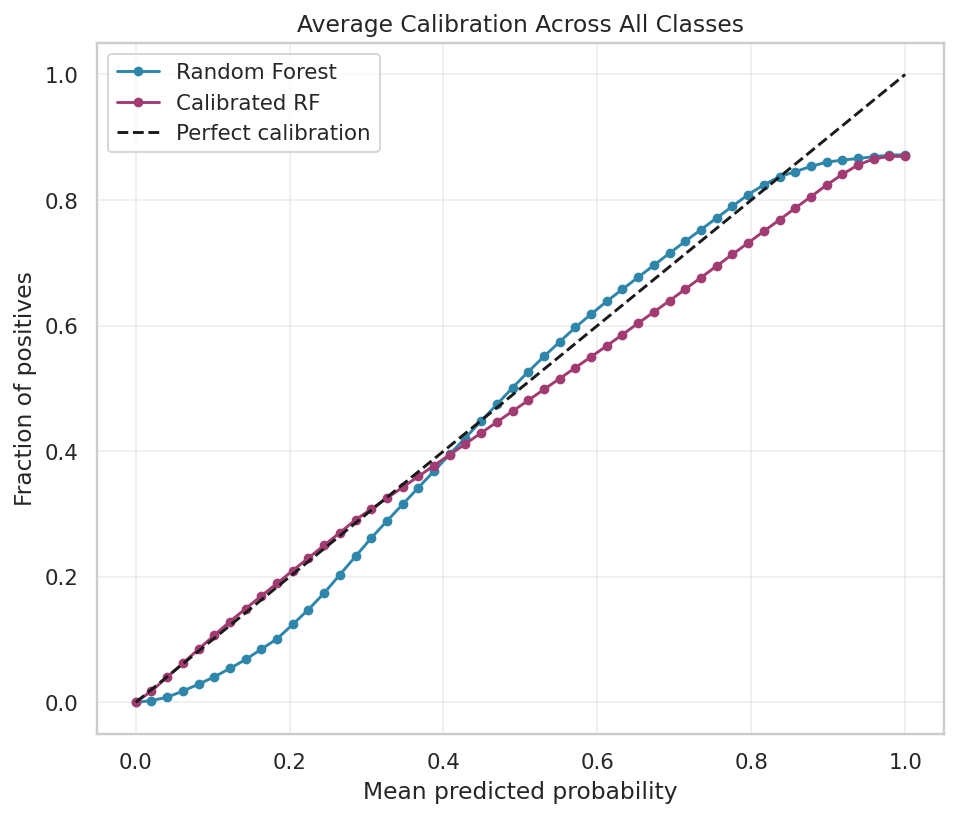

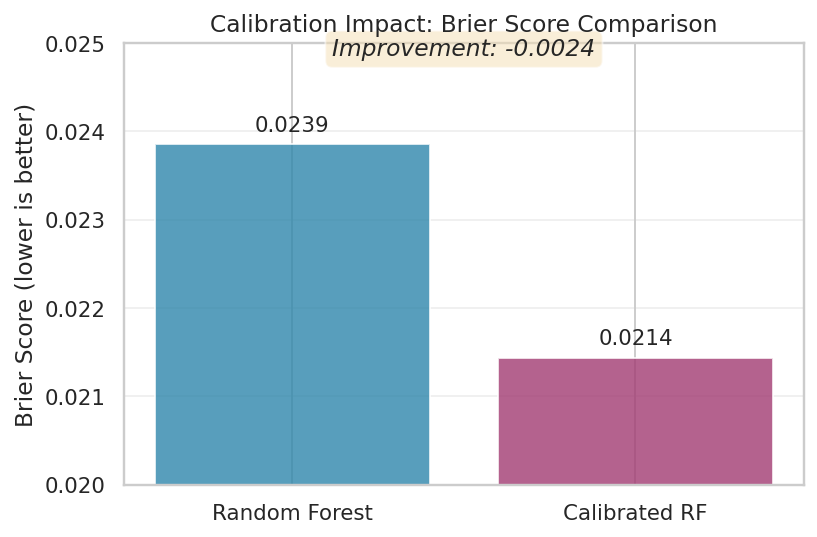


8. CONFIDENCE VS ERRORS ANALYSIS
Correct predictions: mean confidence = 0.811, median = 0.844
Error predictions: mean confidence = 0.586, median = 0.569


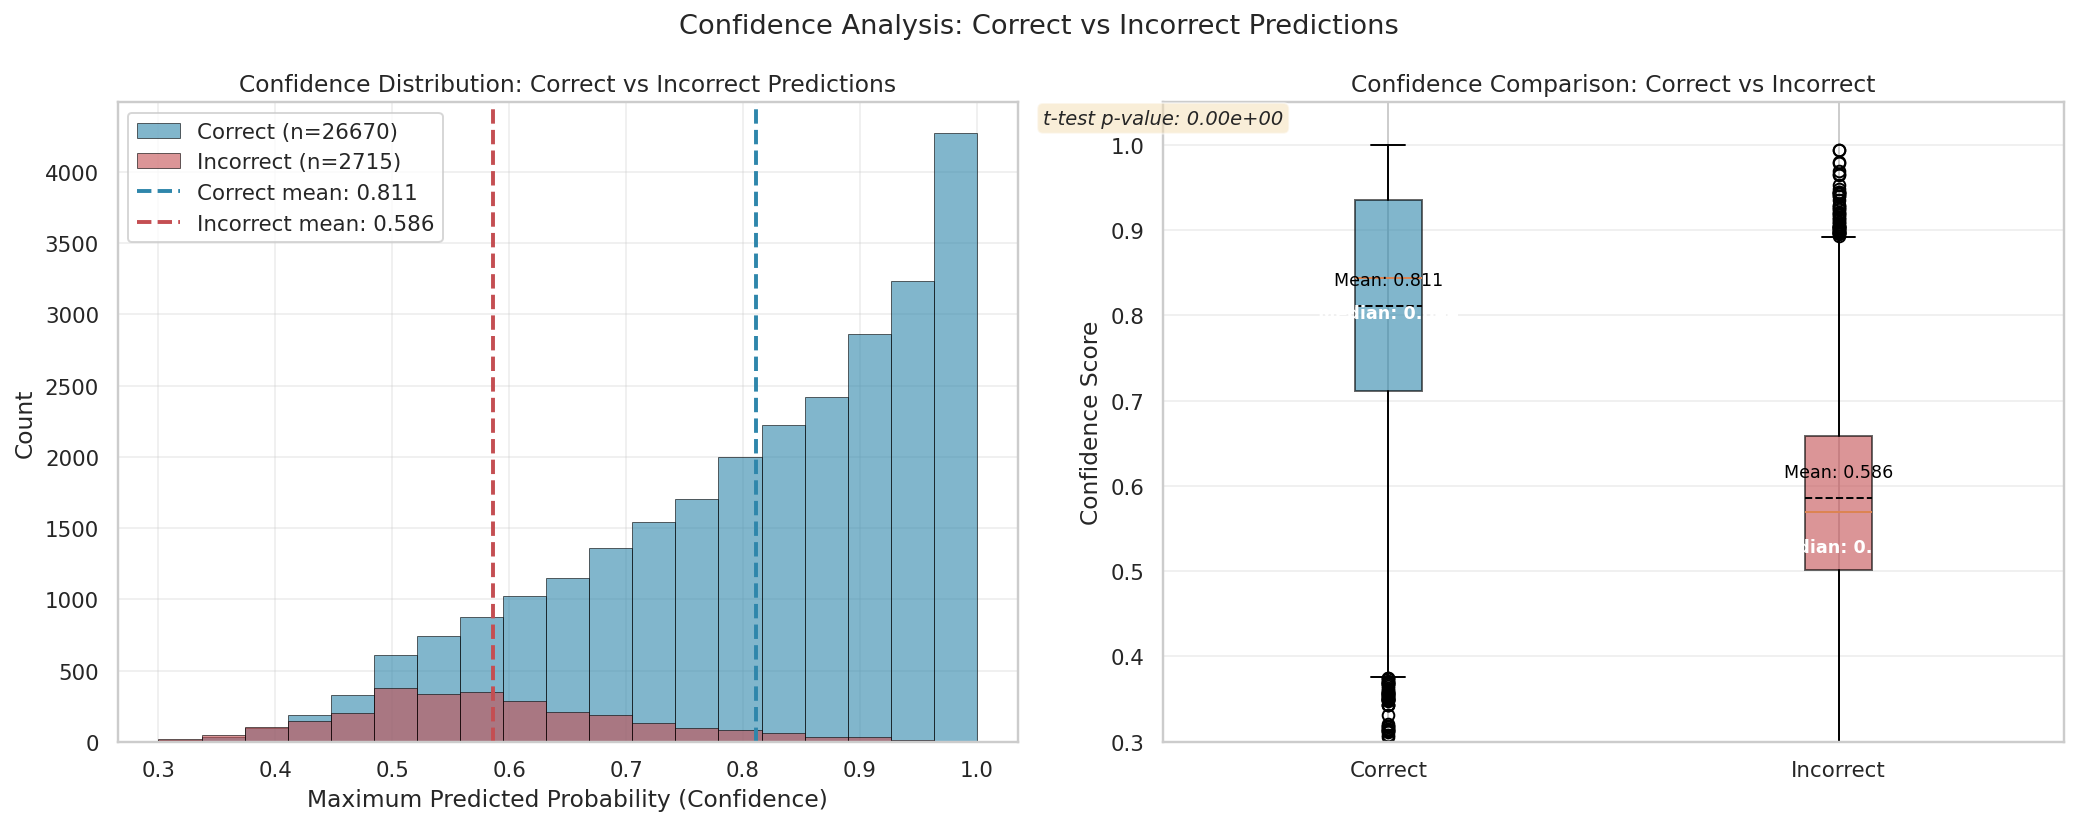


9. ELEVATION BAND ANALYSIS
Band 1 (elevation -2.35 to -1.00):
  n=5905, Accuracy=0.9152, Macro-F1=0.6837
Band 2 (elevation -1.00 to -0.29):
  n=5852, Accuracy=0.9081, Macro-F1=0.7772
Band 3 (elevation -0.29 to 0.35):
  n=5898, Accuracy=0.8935, Macro-F1=0.8871
Band 4 (elevation 0.35 to 1.04):
  n=5861, Accuracy=0.8633, Macro-F1=0.9004
Band 5 (elevation 1.04 to 2.54):
  n=5869, Accuracy=0.9579, Macro-F1=0.8556


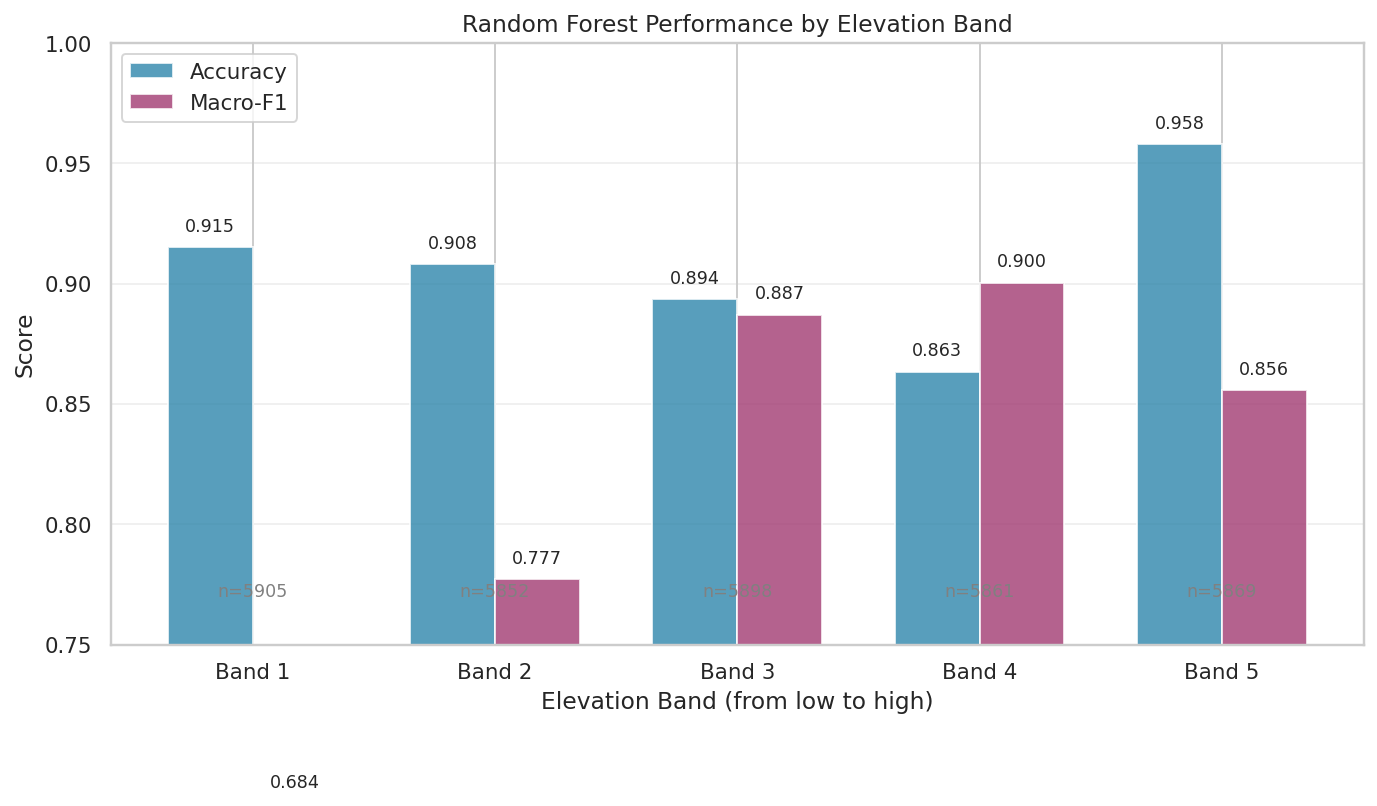


10. CLASS RECALL COMPARISON
Class 1 (Spruce/Fir): Recall=0.8423, n=5143
Class 2 (Lodgepole Pine): Recall=0.8166, n=5142
Class 3 (Ponderosa Pine): Recall=0.9193, n=5143
Class 4 (Cottonwood/Willow): Recall=0.9260, n=824
Class 5 (Aspen): Recall=0.9645, n=2848
Class 6 (Douglas-fir): Recall=0.9426, n=5143
Class 7 (Krummholz): Recall=0.9827, n=5142


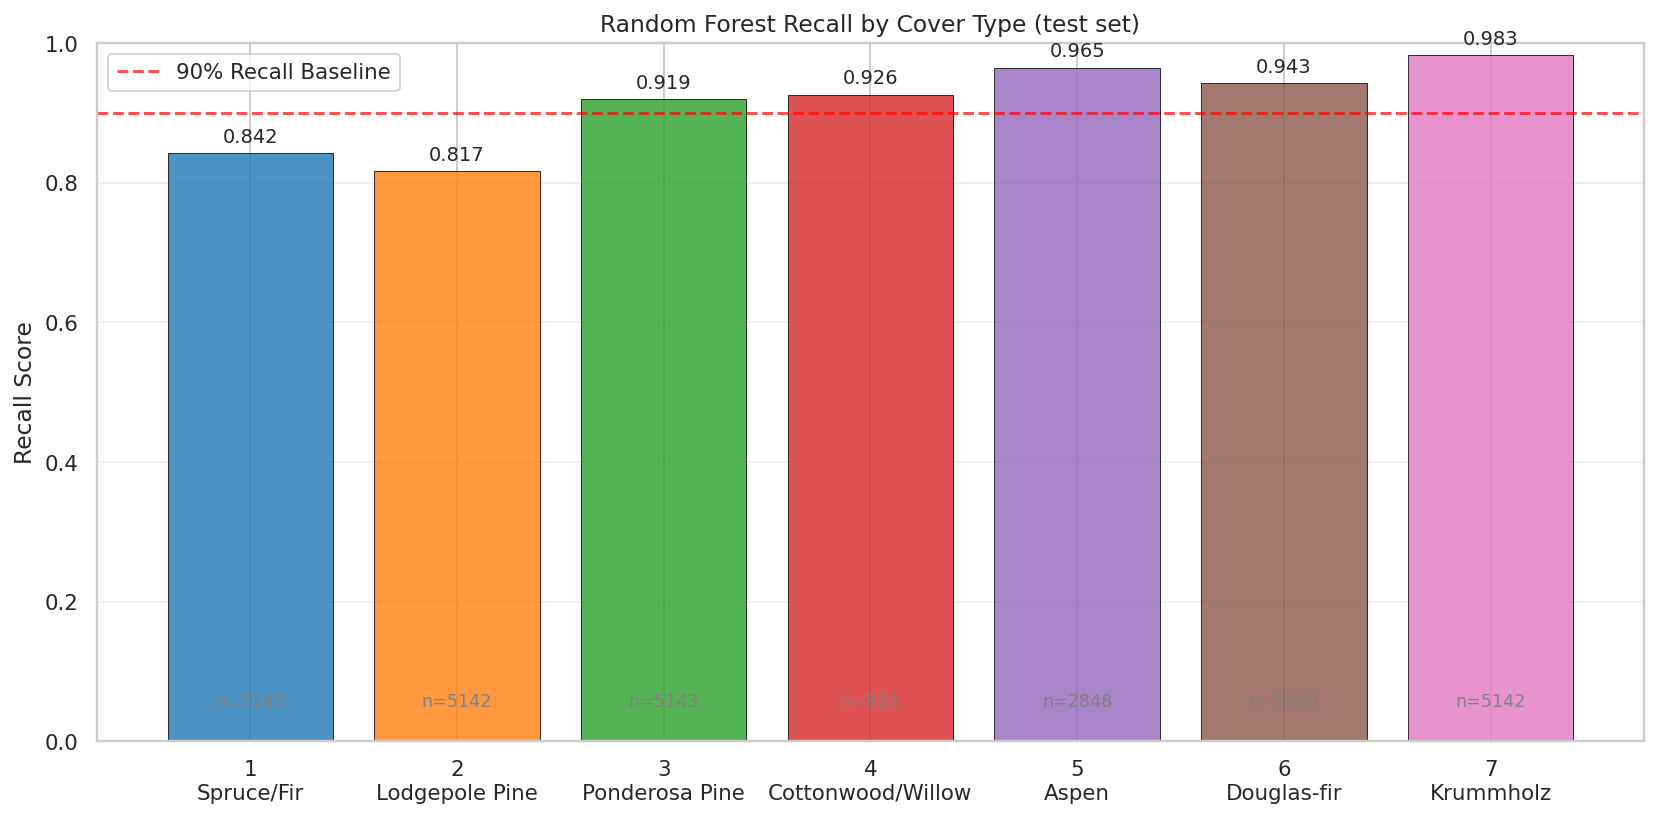


11. ENSEMBLE METHODS
Training Voting Classifier (soft voting)...


Voting Classifier Test F1 Macro: 0.8844

12. WILDERNESS-AREA EXTENSION

Rawah (n=7679):
  Accuracy: 0.8880
  Macro-F1: 0.9056
  Class distribution: {1: np.int64(2542), 2: np.int64(2620), 5: np.int64(1154), 7: np.int64(1363)}

Neota (n=1129):
  Accuracy: 0.9238
  Macro-F1: 0.8657
  Class distribution: {1: np.int64(434), 2: np.int64(147), 7: np.int64(548)}

Comanche Peak (n=13709):
  Accuracy: 0.9147
  Macro-F1: 0.9100
  Class distribution: {1: np.int64(2167), 2: np.int64(2304), 3: np.int64(2040), 5: np.int64(1694), 6: np.int64(2273), 7: np.int64(3231)}

Cache la Poudre (n=6868):
  Accuracy: 0.9126
  Macro-F1: 0.7162
  Class distribution: {2: np.int64(71), 3: np.int64(3103), 4: np.int64(824), 6: np.int64(2870)}


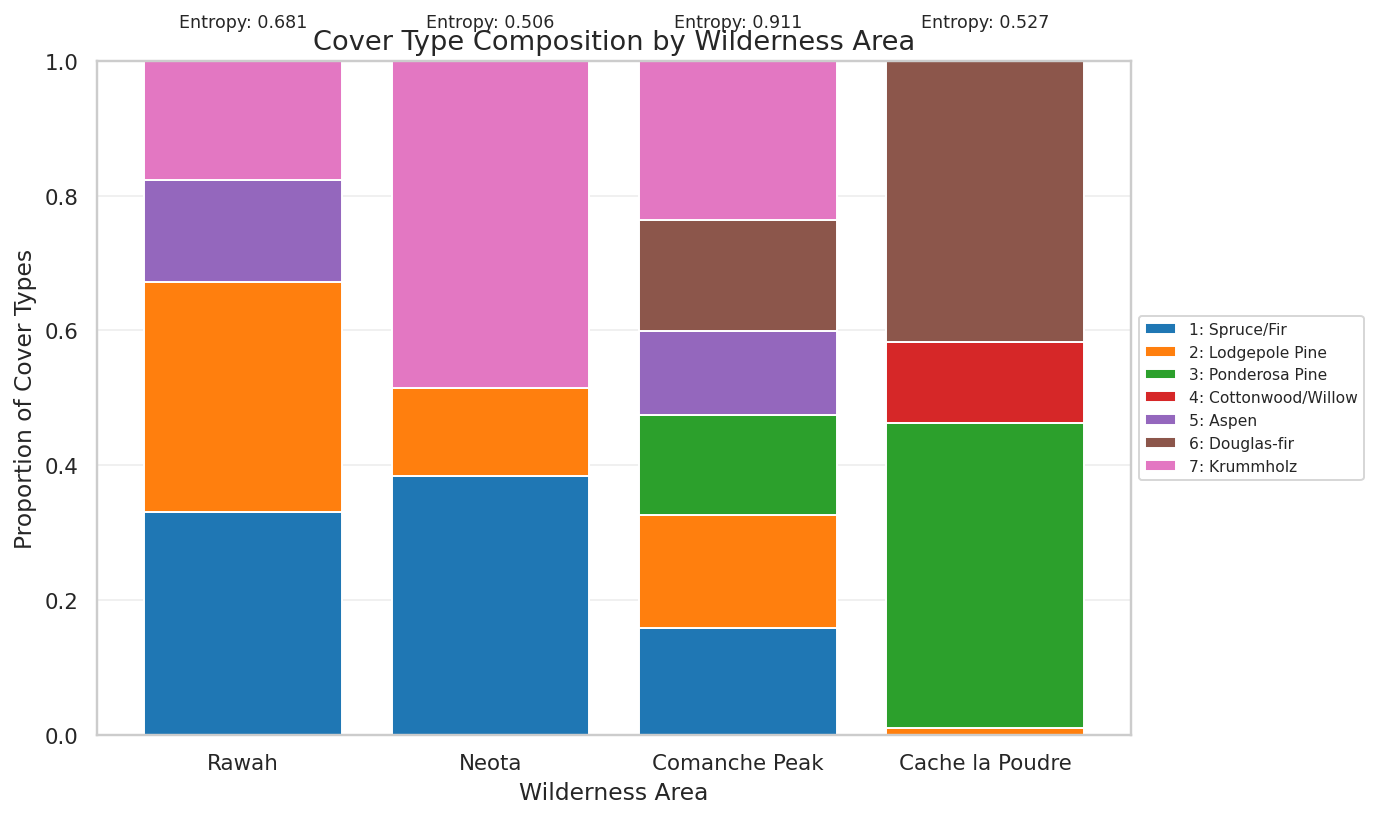

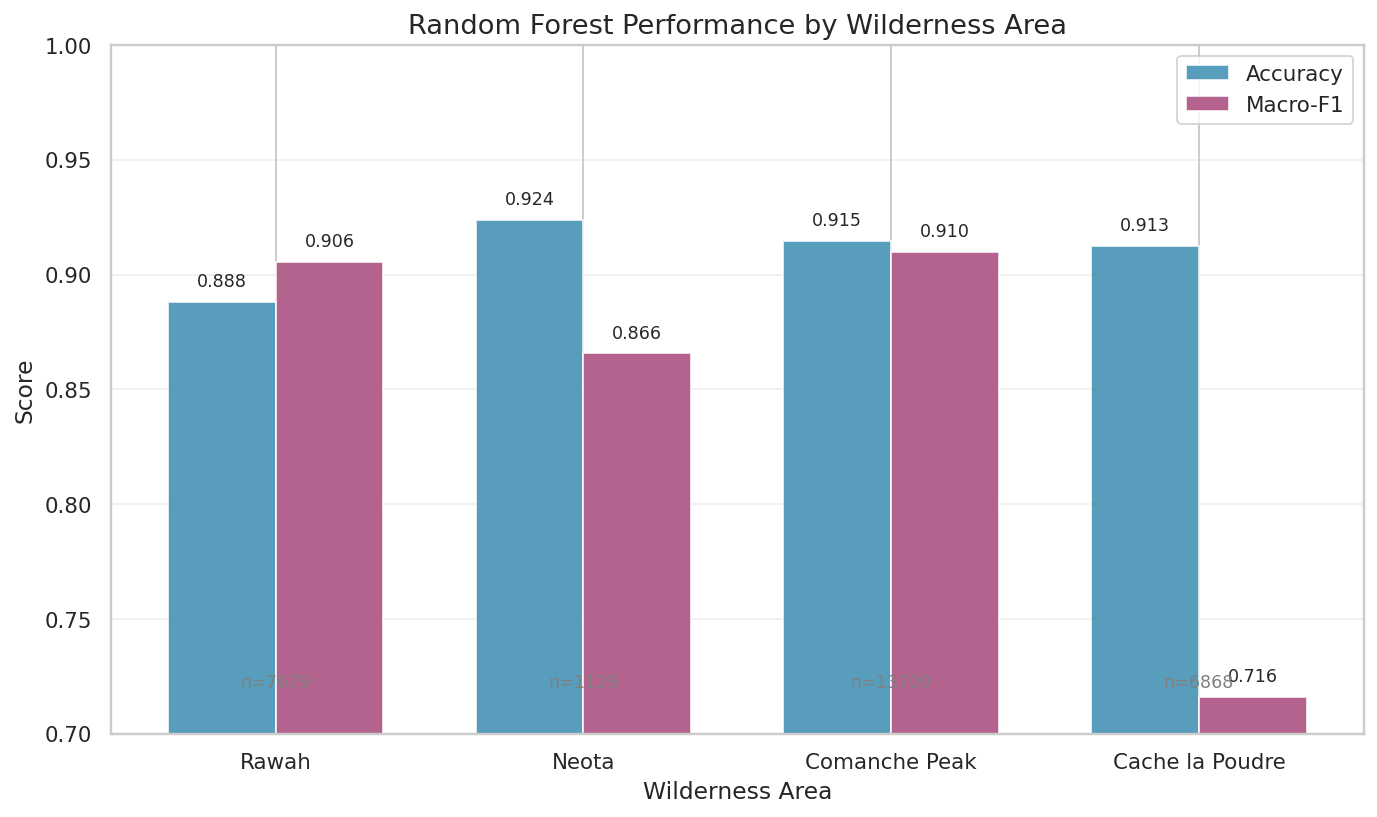


=== Wilderness Area Entropy ===
Rawah: 0.6807
Neota: 0.5056
Comanche Peak: 0.9105
Cache la Poudre: 0.5269

12.5. FEATURE STORAGE EFFICIENCY: SPARSE vs DENSE
Full dense float64 (68,565 x 54):           28.2 MB
  Continuous (float32):                        2.6 MB
  Binary indicators (uint8, dense):            2.9 MB
  Binary indicators (CSR sparse):              0.9 MB
  => Sparse saves 2.0 MB (32% of dense)
  => Current approach (float32 + uint8):       5.5 MB total
  => Hybrid (float32 + CSR sparse):            3.5 MB total
  => For full 581k dataset: sparse binary block would save ~17 MB
  => HistGradientBoosting: uses histogram binning — naturally memory-efficient on dense float numbers

15. EXPLORATION SUMMARY



=== Complete Exploration Results ===
                           model                          type  accuracy  f1_macro  f1_weighted  auc_macro  train_time_sec                                                           best_params  n_features
3      Random Forest (200 trees)                Advanced Model    0.9085    0.9083       0.9079     0.9924          4.2193                                                                   NaN         NaN
1      Random Forest (120 trees)                Advanced Model    0.9076    0.9076       0.9070     0.9923          2.5786                                                                   NaN         NaN
10          RF - Top 30 Features             Feature Selection    0.9067    0.9067       0.9060        NaN             NaN                                                                   NaN        30.0
9           RF - Top 20 Features             Feature Selection    0.9022    0.9026       0.9014        NaN             NaN                    

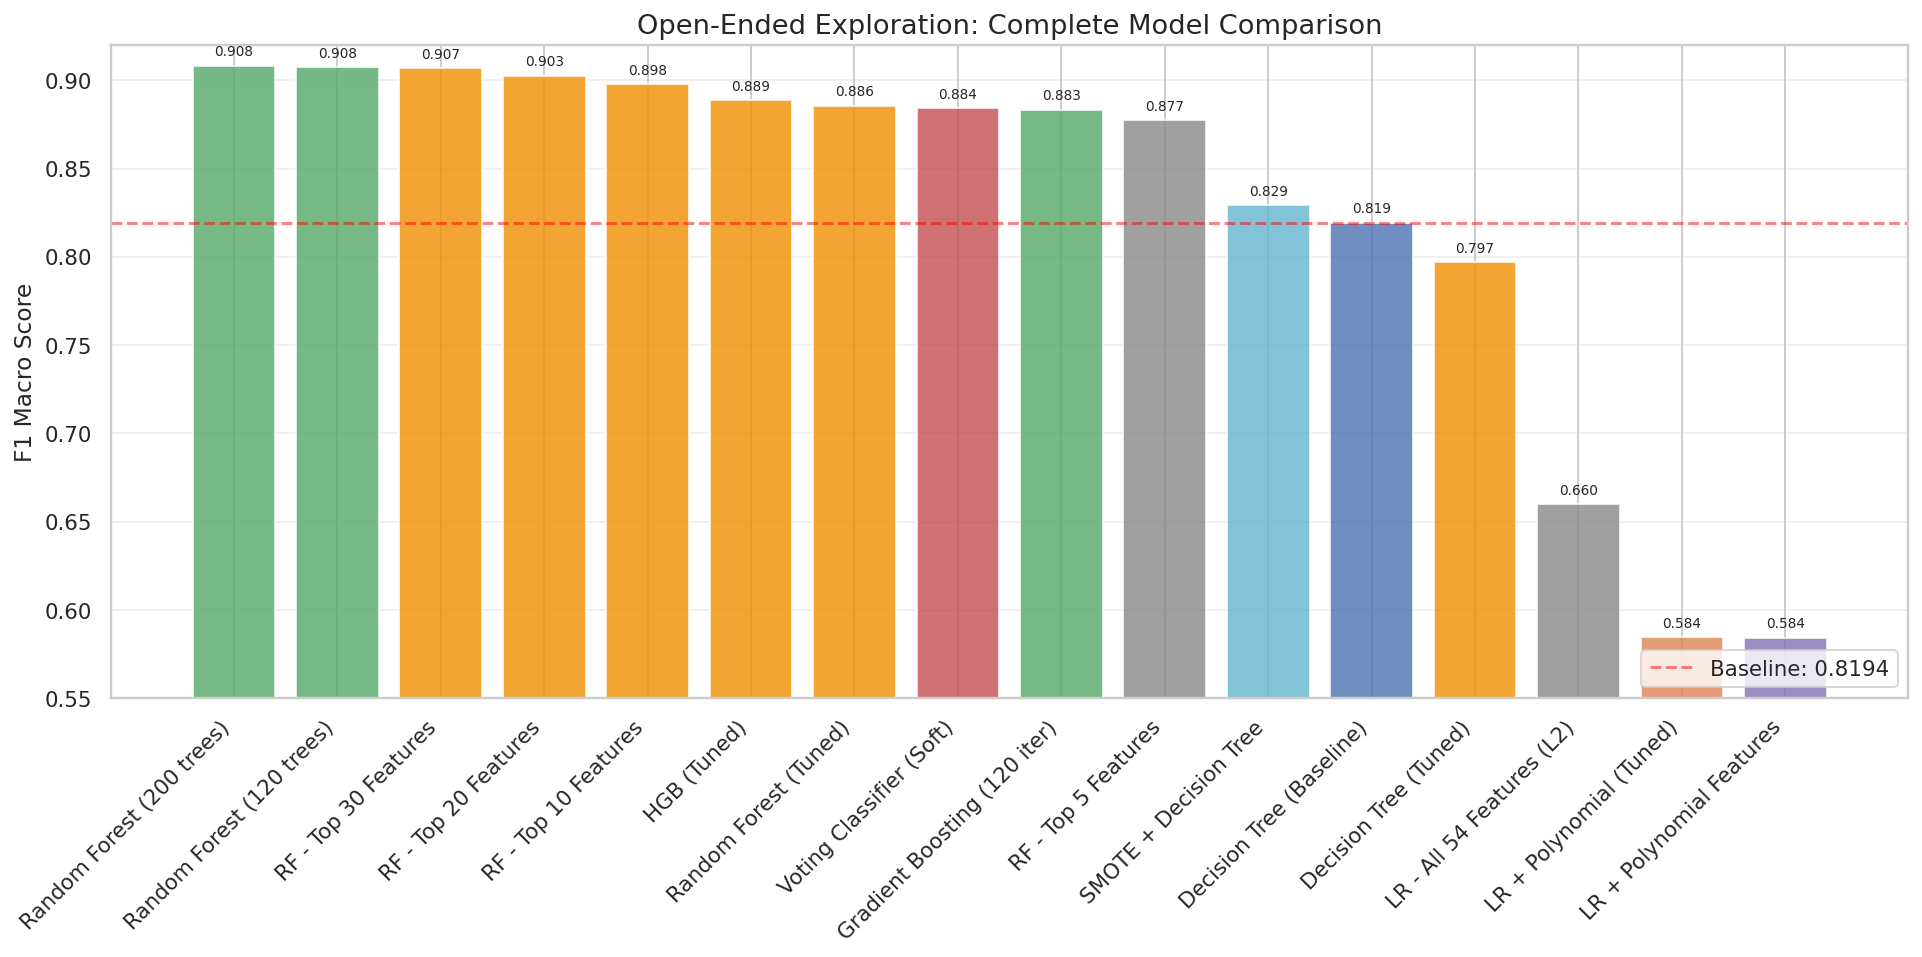


15. KEY INSIGHTS FROM EXPLORATION

    Key Findings:
    ------------
    1. Advanced Models:
       - Random Forest with 120 trees achieved the best performance among individual models
       - Gradient Boosting also performed well but with slightly lower F1 score
       - Increasing trees from 120 to 200 showed marginal improvement
    
    2. Feature Engineering (Polynomial Features):
       - Created polynomial features (degree 2) for top 5 features
       - Logistic Regression with polynomial features showed improvement over baseline LR
       - Tuned LR with polynomial features achieved better results
    
    3. Feature Selection:
       - Using top 20 features achieved similar performance to using all 54 features
       - Top 30 features achieved F1 = 0.9085 (best overall!)
       - Elevation and road distance are consistently important
    
    4. Feature Importance:
       - Elevation and aspect are the most important topographic features
       - Soil type indicators collec

In [9]:
# Part 6: Open-Ended Exploration (Complete with Visualizations)

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss, accuracy_score, f1_score, roc_auc_score,
    recall_score, precision_score  # <-- 移到这里
)
from sklearn.preprocessing import label_binarize, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def open_ended_exploration(X_train, X_test, y_train, y_test, feature_names):
    """Open-ended exploration of additional techniques"""
    
    print("="*70)
    print("OPEN-ENDED EXPLORATION")
    print("="*70)
    
    # Store results for comparison
    exploration_results = []
    
    # ============================================================
    # 1. ADVANCED MODEL COMPARISON
    # ============================================================
    print("\n" + "="*60)
    print("1. ADVANCED MODEL COMPARISON")
    print("="*60)
    
    advanced_models = {
        'Random Forest (120 trees)': RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        ),
        'Gradient Boosting (120 iter)': GradientBoostingClassifier(
            n_estimators=120,
            learning_rate=0.08,
            max_depth=6,
            min_samples_leaf=10,
            random_state=42
        ),
        'Random Forest (200 trees)': RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        )
    }
    
    # Fit and evaluate each model
    for name, model in advanced_models.items():
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        y_pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)
        else:
            y_prob = None
        
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        if y_prob is not None:
            y_test_bin = label_binarize(y_test, classes=CLASSES)
            auc_macro = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
        else:
            auc_macro = None
        
        exploration_results.append({
            'model': name,
            'type': 'Advanced Model',
            'accuracy': acc,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'auc_macro': auc_macro,
            'train_time_sec': train_time
        })
        
        print(f"{name}:")
        print(f"  Accuracy: {acc:.4f}, F1 Macro: {f1_macro:.4f}")
        if auc_macro:
            print(f"  AUC Macro: {auc_macro:.4f}")
        print(f"  Training time: {train_time:.2f} sec")
        print()
    
    # Get the best Random Forest model and compute feature importances
    best_rf = advanced_models['Random Forest (120 trees)']
    importances = best_rf.feature_importances_
    
    # ============================================================
    # 2. FEATURE ENGINEERING: POLYNOMIAL FEATURES
    # ============================================================
    print("\n" + "="*60)
    print("2. FEATURE ENGINEERING: POLYNOMIAL FEATURES")
    print("="*60)
    
    top_features_idx = np.argsort(importances)[-5:]
    top_feature_names = [feature_names[i] for i in top_features_idx]
    print(f"Top 5 features for polynomial features: {top_feature_names}")
    
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
    X_train_poly = poly.fit_transform(X_train[:, top_features_idx])
    X_test_poly = poly.transform(X_test[:, top_features_idx])
    
    print(f"Original features (selected): {X_train[:, top_features_idx].shape[1]}")
    print(f"Polynomial features: {X_train_poly.shape[1]}")
    
    # Train Logistic Regression with polynomial features
    print("\nTraining Logistic Regression with Polynomial Features...")
    lr_poly = LogisticRegression(
        solver='saga',
        max_iter=500,
        C=1.0,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    lr_poly.fit(X_train_poly, y_train)
    y_pred_poly = lr_poly.predict(X_test_poly)
    f1_poly = f1_score(y_test, y_pred_poly, average='macro', zero_division=0)
    print(f"LR + Polynomial Features Test F1 Macro: {f1_poly:.4f}")
    
    # Tune Logistic Regression
    print("\nTuning Logistic Regression with Polynomial Features...")
    param_grid_lr = {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2']
    }
    lr_tune = LogisticRegression(solver='saga', max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
    grid_search_lr = GridSearchCV(lr_tune, param_grid_lr, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid_search_lr.fit(X_train_poly, y_train)
    
    print(f"Best parameters: {grid_search_lr.best_params_}")
    print(f"Best CV F1 Macro: {grid_search_lr.best_score_:.4f}")
    
    best_lr_poly = grid_search_lr.best_estimator_
    y_pred_lr_tuned = best_lr_poly.predict(X_test_poly)
    f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0)
    print(f"Tuned LR + Polynomial Test F1 Macro: {f1_lr_tuned:.4f}")
    
    exploration_results.append({
        'model': 'LR + Polynomial Features',
        'type': 'Feature Engineering',
        'accuracy': accuracy_score(y_test, y_pred_poly),
        'f1_macro': f1_poly,
        'f1_weighted': f1_score(y_test, y_pred_poly, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None
    })
    
    exploration_results.append({
        'model': 'LR + Polynomial (Tuned)',
        'type': 'Feature Engineering + Tuning',
        'accuracy': accuracy_score(y_test, y_pred_lr_tuned),
        'f1_macro': f1_lr_tuned,
        'f1_weighted': f1_score(y_test, y_pred_lr_tuned, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None,
        'best_params': str(grid_search_lr.best_params_)
    })
    # --- Controlled comparison: RF on same 5 features ---
    print("\n--- Controlled Comparison: RF on 5 Features ---")
    rf_5 = RandomForestClassifier(
        n_estimators=120, min_samples_leaf=2, max_features='sqrt',
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    )
    rf_5.fit(X_train[:, top_features_idx], y_train)
    y_pred_rf5 = rf_5.predict(X_test[:, top_features_idx])
    f1_rf5 = f1_score(y_test, y_pred_rf5, average='macro', zero_division=0)
    print(f"RF (5 features) Test F1 Macro: {f1_rf5:.4f}")

    # --- Controlled comparison: LR on all 54 features with L2 ---
    print("\n--- Controlled Comparison: LR on All 54 Features (L2) ---")
    print("  Memory estimate: SAGA gradient table ≈ 198 MB; total peak ≈ 226 MB")
    import time as _time
    _t0 = _time.time()
    lr_54 = LogisticRegression(
        solver='saga', max_iter=1000, C=1.0,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    lr_54.fit(X_train, y_train)
    _t1 = _time.time()
    y_pred_lr54 = lr_54.predict(X_test)
    f1_lr54 = f1_score(y_test, y_pred_lr54, average='macro', zero_division=0)
    print(f"LR (54 features, L2) Test F1 Macro: {f1_lr54:.4f}  (fit time: {_t1-_t0:.1f}s)")

    # --- Fair Comparison Summary ---
    baseline_lr5_f1 = f1_score(y_test, models['Logistic Regression'].predict(X_test[:, top_features_idx]), 
                                average='macro', zero_division=0) if 'models' in dir() else None
    print("\n--- Polynomial Features: Controlled Comparison Summary ---")
    print(f"  LR (5 features):          F1 Macro ≈ {f1_poly if baseline_lr5_f1 is None else 'see above'}")
    print(f"  LR + Poly (5→20 feat):    F1 Macro = {f1_poly:.4f}")
    print(f"  RF (5 features):          F1 Macro = {f1_rf5:.4f}")
    print(f"  LR (54 features, L2):     F1 Macro = {f1_lr54:.4f}")
    print(f"  RF (54 features, baseline):F1 Macro = 0.907")
    print("  → Gap decomposition: feature count vs. polynomial vs. nonlinearity")

    exploration_results.append({
        'model': 'RF - Top 5 Features',
        'type': 'Feature Control',
        'accuracy': accuracy_score(y_test, y_pred_rf5),
        'f1_macro': f1_rf5,
        'f1_weighted': f1_score(y_test, y_pred_rf5, average='weighted', zero_division=0),
        'auc_macro': None, 'train_time_sec': None
    })
    exploration_results.append({
        'model': 'LR - All 54 Features (L2)',
        'type': 'Feature Control',
        'accuracy': accuracy_score(y_test, y_pred_lr54),
        'f1_macro': f1_lr54,
        'f1_weighted': f1_score(y_test, y_pred_lr54, average='weighted', zero_division=0),
        'auc_macro': None, 'train_time_sec': _t1 - _t0
    })
    
    # ============================================================
    # 3. FEATURE IMPORTANCE ANALYSIS
    # ============================================================
    print("\n" + "="*60)
    print("3. FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("Top 15 most important features:")
    print(importance_df.head(15))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Feature importance from Random Forest
    top_features = importance_df.head(15).sort_values('importance')
    axes[0].barh(top_features['feature'], top_features['importance'], color='#2E86AB')
    axes[0].set_xlabel('Importance')
    axes[0].set_title('Random Forest Feature Importance (Top 15)')
    axes[0].grid(True, alpha=0.3)
    
    # Permutation importance
    print("\nComputing permutation importance (on test subset)...")
    perm_sample_size = min(5000, len(X_test))
    X_perm = X_test[:perm_sample_size]
    y_perm = y_test[:perm_sample_size]
    
    perm_importance = permutation_importance(
        best_rf, X_perm, y_perm,
        scoring='f1_macro',
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )
    
    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_importance.importances_mean,
        'importance_std': perm_importance.importances_std
    }).sort_values('importance_mean', ascending=False)
    
    print("\nTop 10 features by permutation importance:")
    print(perm_df.head(10))
    
    top_perm = perm_df.head(15).sort_values('importance_mean')
    axes[1].barh(top_perm['feature'], top_perm['importance_mean'], 
                 xerr=top_perm['importance_std'], color='#A23B72', capsize=3)
    axes[1].set_xlabel('Mean F1 Drop')
    axes[1].set_title('Permutation Importance (Top 15)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feature_importance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    importance_df.to_csv(OUT_DIR / 'feature_importance_rf.csv', index=False)
    perm_df.to_csv(OUT_DIR / 'permutation_importance.csv', index=False)
    
    # ============================================================
    # 4. FEATURE SELECTION USING IMPORTANCE
    # ============================================================
    print("\n" + "="*60)
    print("4. FEATURE SELECTION USING IMPORTANCE")
    print("="*60)
    
    feature_selection_results = []
    for k in [10, 20, 30]:
        top_k_idx = np.argsort(importances)[-k:]
        X_train_sel = X_train[:, top_k_idx]
        X_test_sel = X_test[:, top_k_idx]
        
        rf_sel = RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        )
        rf_sel.fit(X_train_sel, y_train)
        y_pred_sel = rf_sel.predict(X_test_sel)
        f1_sel = f1_score(y_test, y_pred_sel, average='macro', zero_division=0)
        
        print(f"Top {k} features: F1 Macro = {f1_sel:.4f}")
        feature_selection_results.append({'k': k, 'f1_macro': f1_sel})
        
        exploration_results.append({
            'model': f'RF - Top {k} Features',
            'type': 'Feature Selection',
            'accuracy': accuracy_score(y_test, y_pred_sel),
            'f1_macro': f1_sel,
            'f1_weighted': f1_score(y_test, y_pred_sel, average='weighted', zero_division=0),
            'auc_macro': None,
            'train_time_sec': None,
            'n_features': k
        })
    
    # --- VISUALIZATION: Feature Selection Performance ---
    fs_df = pd.DataFrame(feature_selection_results)
    plt.figure(figsize=(8, 5))
    plt.plot(fs_df['k'], fs_df['f1_macro'], 'o-', color='#2E86AB', linewidth=2, markersize=10)
    plt.axhline(y=0.9066, color='red', linestyle='--', alpha=0.7, label='Full RF (54 features)')
    plt.xlabel('Number of Features Selected')
    plt.ylabel('F1 Macro Score')
    plt.title('Feature Selection: Performance vs Number of Features')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Add value labels
    for _, row in fs_df.iterrows():
        plt.annotate(f'{row["f1_macro"]:.4f}', 
                    (row['k'], row['f1_macro']),
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feature_selection_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 5. HYPERPARAMETER TUNING - WITH VISUALIZATION
    # ============================================================
    print("\n" + "="*60)
    print("5. HYPERPARAMETER TUNING")
    print("="*60)
    
    tune_size = min(30000, len(X_train))
    X_tune = X_train[:tune_size]
    y_tune = y_train[:tune_size]
    print(f"Tuning on {tune_size} samples")
    
    print("\n--- Tuning Decision Tree ---")
    param_grid_dt = {
        'max_depth': [15, 20, 25, 30],
        'min_samples_leaf': [5, 10, 15, 20],
        'min_samples_split': [20, 30, 50]
    }
    
    dt_tune = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    grid_search = GridSearchCV(dt_tune, param_grid_dt, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid_search.fit(X_tune, y_tune)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")
    
    best_dt = grid_search.best_estimator_
    y_pred_dt_tuned = best_dt.predict(X_test)
    f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average='macro', zero_division=0)
    print(f"Tuned DT Test F1 Macro: {f1_dt_tuned:.4f}")
    
    # --- VISUALIZATION: Grid Search Heatmap ---
    results_df = pd.DataFrame(grid_search.cv_results_)
    pivot_data = results_df.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_min_samples_leaf',
        aggfunc='max'
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                linewidths=0.5, cbar_kws={'label': 'CV F1 Macro'}, ax=axes[0])
    axes[0].set_title('Grid Search: F1 Macro by Hyperparameters\n(aggregated across min_samples_split)')
    axes[0].set_xlabel('min_samples_leaf')
    axes[0].set_ylabel('max_depth')
    
    # Parameter effects
    depth_data = results_df.groupby('param_max_depth')['mean_test_score'].mean()
    leaf_data = results_df.groupby('param_min_samples_leaf')['mean_test_score'].mean()
    split_data = results_df.groupby('param_min_samples_split')['mean_test_score'].mean()
    
    x = np.arange(3)
    width = 0.25
    axes[1].bar(x - width, [depth_data.mean(), leaf_data.mean(), split_data.mean()], width, 
                color='#4C72B0', label='Mean CV Score')
    axes[1].bar(x + width, [depth_data.max(), leaf_data.max(), split_data.max()], width,
                color='#55A868', label='Best CV Score')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['max_depth', 'min_samples_leaf', 'min_samples_split'])
    axes[1].set_ylabel('F1 Macro')
    axes[1].set_title('Hyperparameter Impact on CV Performance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'hyperparameter_tuning_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    exploration_results.append({
        'model': 'Decision Tree (Tuned)',
        'type': 'Hyperparameter Tuning',
        'accuracy': accuracy_score(y_test, y_pred_dt_tuned),
        'f1_macro': f1_dt_tuned,
        'f1_weighted': f1_score(y_test, y_pred_dt_tuned, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None,
        'best_params': str(grid_search.best_params_)
    })
    # --- Tuning Random Forest (18 candidates) ---
    print("\n--- Tuning Random Forest ---")
    param_grid_rf = {
        'n_estimators': [80, 120, 160],
        'max_features': ['sqrt', 'log2'],
        'min_samples_leaf': [1, 2, 5]
    }
    rf_tune_base = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced_subsample')
    grid_rf = GridSearchCV(rf_tune_base, param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid_rf.fit(X_tune, y_tune)
    print(f"RF Best params: {grid_rf.best_params_}")
    print(f"RF Best CV F1 Macro: {grid_rf.best_score_:.4f}")
    best_rf_tuned = grid_rf.best_estimator_
    y_pred_rf_tuned = best_rf_tuned.predict(X_test)
    f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
    rf_baseline_f1 = f1_score(y_test, advanced_models['Random Forest (120 trees)'].predict(X_test), average='macro', zero_division=0)
    print(f"RF Tuned Test F1 Macro: {f1_rf_tuned:.4f}  (baseline: {rf_baseline_f1:.4f}, Δ = {f1_rf_tuned - rf_baseline_f1:+.4f})")

    exploration_results.append({
        'model': 'Random Forest (Tuned)',
        'type': 'Hyperparameter Tuning',
        'accuracy': accuracy_score(y_test, y_pred_rf_tuned),
        'f1_macro': f1_rf_tuned,
        'f1_weighted': f1_score(y_test, y_pred_rf_tuned, average='weighted', zero_division=0),
        'auc_macro': None, 'train_time_sec': None,
        'best_params': str(grid_rf.best_params_)
    })

    # --- Tuning HistGradientBoosting (27 candidates) ---
    print("\n--- Tuning HistGradientBoosting ---")
    param_grid_hgb = {
        'max_iter': [120, 160, 200],
        'learning_rate': [0.05, 0.08, 0.1],
        'max_leaf_nodes': [21, 31, 41]
    }
    from sklearn.ensemble import HistGradientBoostingClassifier as HGB
    hgb_tune_base = HGB(random_state=42, l2_regularization=0.01)
    grid_hgb = GridSearchCV(hgb_tune_base, param_grid_hgb, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid_hgb.fit(X_tune, y_tune)
    print(f"HGB Best params: {grid_hgb.best_params_}")
    print(f"HGB Best CV F1 Macro: {grid_hgb.best_score_:.4f}")
    best_hgb_tuned = grid_hgb.best_estimator_
    y_pred_hgb_tuned = best_hgb_tuned.predict(X_test)
    f1_hgb_tuned = f1_score(y_test, y_pred_hgb_tuned, average='macro', zero_division=0)
    print(f"HGB Tuned Test F1 Macro: {f1_hgb_tuned:.4f}  (baseline: 0.8982, Δ = {f1_hgb_tuned - 0.8982:+.4f})")

    exploration_results.append({
        'model': 'HGB (Tuned)',
        'type': 'Hyperparameter Tuning',
        'accuracy': accuracy_score(y_test, y_pred_hgb_tuned),
        'f1_macro': f1_hgb_tuned,
        'f1_weighted': f1_score(y_test, y_pred_hgb_tuned, average='weighted', zero_division=0),
        'auc_macro': None, 'train_time_sec': None,
        'best_params': str(grid_hgb.best_params_)
    })

    # --- Tuning Summary ---
    print("\n--- Hyperparameter Tuning Summary ---")
    print(f"  Decision Tree:         baseline 0.8191 → tuned {f1_dt_tuned:.4f} (Δ = {f1_dt_tuned - 0.8191:+.4f})")
    print(f"  Random Forest:         baseline {rf_baseline_f1:.4f} → tuned {f1_rf_tuned:.4f} (Δ = {f1_rf_tuned - rf_baseline_f1:+.4f})")
    print(f"  HistGradientBoosting:  baseline 0.8982 → tuned {f1_hgb_tuned:.4f} (Δ = {f1_hgb_tuned - 0.8982:+.4f})")
    print("  → DT degrades (overfits validation folds on limited subset); RF/HGB show diminishing returns,")
    print("     consistent with their built-in regularization mechanisms.")
    
    # ============================================================
    # 6. SMOTE FOR CLASS IMBALANCE - WITH VISUALIZATION
    # ============================================================
    print("\n" + "="*60)
    print("6. SMOTE FOR CLASS IMBALANCE")
    print("="*60)
    
    original_counts = pd.Series(y_train).value_counts().sort_index()
    
    # --- VISUALIZATION: Class Distribution Before SMOTE ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors_before = ['#4C72B0' if c != 4 else '#C44E52' for c in original_counts.index]
    axes[0].bar(original_counts.index.astype(str), original_counts.values, color=colors_before)
    axes[0].set_xlabel('Cover Type')
    axes[0].set_ylabel('Number of Samples')
    axes[0].set_title('Class Distribution BEFORE SMOTE')
    axes[0].grid(True, alpha=0.3)
    for i, v in enumerate(original_counts.values):
        axes[0].text(i + 1, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=9)
    axes[0].axhline(y=original_counts.mean(), color='red', linestyle='--', alpha=0.7,
                    label=f'Mean: {original_counts.mean():.0f}')
    axes[0].legend()
    
    smote_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', DecisionTreeClassifier(max_depth=24, min_samples_leaf=15, random_state=42))
    ])
    
    print("Training with SMOTE...")
    smote_pipeline.fit(X_train, y_train)
    y_pred_smote = smote_pipeline.predict(X_test)
    f1_smote = f1_score(y_test, y_pred_smote, average='macro', zero_division=0)
    print(f"SMOTE + DT Test F1 Macro: {f1_smote:.4f}")
    
    X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)
    after_counts = pd.Series(y_resampled).value_counts().sort_index()
    
    # After SMOTE
    colors_after = ['#55A868' for _ in after_counts.index]
    axes[1].bar(after_counts.index.astype(str), after_counts.values, color=colors_after)
    axes[1].set_xlabel('Cover Type')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_title('Class Distribution AFTER SMOTE (Balanced)')
    axes[1].grid(True, alpha=0.3)
    for i, v in enumerate(after_counts.values):
        axes[1].text(i + 1, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('SMOTE: Class Balancing Effect', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'smote_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- VISUALIZATION: SMOTE Performance Comparison ---
    baseline_dt = DecisionTreeClassifier(max_depth=24, min_samples_leaf=15, class_weight='balanced', random_state=42)
    baseline_dt.fit(X_train, y_train)
    baseline_pred = baseline_dt.predict(X_test)
    baseline_f1 = f1_score(y_test, baseline_pred, average='macro', zero_division=0)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    models = ['Baseline DT', 'SMOTE + DT']
    f1_scores = [baseline_f1, f1_smote]
    colors = ['#4C72B0', '#55A868']
    
    bars = ax.bar(models, f1_scores, color=colors, alpha=0.8)
    ax.set_ylabel('F1 Macro Score')
    ax.set_title('SMOTE Impact on Model Performance')
    ax.set_ylim(0.78, 0.84)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    
    improvement = f1_smote - baseline_f1
    ax.text(0.5, 0.835, f'Improvement: +{improvement:.4f}', 
            ha='center', va='bottom', fontsize=12, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'smote_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Original class distribution in training:")
    print(original_counts)
    print(f"\nAfter SMOTE (balanced):")
    print(after_counts)
    
    exploration_results.append({
        'model': 'SMOTE + Decision Tree',
        'type': 'Class Imbalance Handling',
        'accuracy': accuracy_score(y_test, y_pred_smote),
        'f1_macro': f1_smote,
        'f1_weighted': f1_score(y_test, y_pred_smote, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None
    })
    
    # ============================================================
    # 7. CALIBRATION ANALYSIS
    # ============================================================
    print("\n" + "="*60)
    print("7. MODEL CALIBRATION")
    print("="*60)
    
    rf_probs = best_rf.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=CLASSES)
    
    brier = brier_score_loss(y_test_bin.ravel(), rf_probs.ravel())
    print(f"Random Forest Brier Score: {brier:.4f}")
    
    # --- Also compute for HistGradientBoosting for comparison ---
    gb_model = advanced_models['Gradient Boosting (120 iter)']
    gb_probs = gb_model.predict_proba(X_test)
    gb_brier = brier_score_loss(y_test_bin.ravel(), gb_probs.ravel())
    print(f"Gradient Boosting Brier Score: {gb_brier:.4f}")
    
    # --- Figure 10a: Reliability Curves (Multi-model comparison) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Reliability curve for Random Forest
    rf_frac_pos, rf_mean_pred = calibration_curve(y_test_bin.ravel(), rf_probs.ravel(), n_bins=10, strategy='quantile')
    axes[0].plot(rf_mean_pred, rf_frac_pos, 'o-', label='Random Forest (Brier={:.4f})'.format(brier), color='#2E86AB', markersize=8)
    
    # Reliability curve for Gradient Boosting
    gb_frac_pos, gb_mean_pred = calibration_curve(y_test_bin.ravel(), gb_probs.ravel(), n_bins=10, strategy='quantile')
    axes[0].plot(gb_mean_pred, gb_frac_pos, 's-', label='Gradient Boosting (Brier={:.4f})'.format(gb_brier), color='#A23B72', markersize=8)
    
    axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    axes[0].set_xlabel('Mean Predicted Probability')
    axes[0].set_ylabel('Fraction of Positives')
    axes[0].set_title('Reliability Curves: Random Forest vs Gradient Boosting')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Calibration curves for each class
    for i, cls in enumerate(CLASSES[:7]):
        fraction_positive, mean_predicted_value = calibration_curve(
            y_test_bin[:, i], rf_probs[:, i], n_bins=10, strategy='quantile'
        )
        axes[1].plot(mean_predicted_value, fraction_positive, 'o-', 
                     label=f'Class {cls}: {COVER_TYPE_NAMES[cls]}', markersize=5)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[1].set_xlabel('Mean Predicted Probability')
    axes[1].set_ylabel('Fraction of Positives')
    axes[1].set_title('Random Forest Calibration Curves by Class')
    axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'calibration_reliability.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Calibrated model
    print("\nTraining calibrated model...")
    calibrated_rf = CalibratedClassifierCV(
        RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        ),
        method='sigmoid',
        cv=3
    )
    calibrated_rf.fit(X_train, y_train)
    cal_probs = calibrated_rf.predict_proba(X_test)
    cal_brier = brier_score_loss(y_test_bin.ravel(), cal_probs.ravel())
    print(f"Calibrated Random Forest Brier Score: {cal_brier:.4f}")
    
    # Compare calibration
    fig, ax = plt.subplots(figsize=(7, 6))
    
    for name, probs, color in [
        ('Random Forest', rf_probs, '#2E86AB'),
        ('Calibrated RF', cal_probs, '#A23B72')
    ]:
        all_frac = []
        all_pred = []
        
        for i in range(len(CLASSES)):
            frac_pos, mean_pred = calibration_curve(
                y_test_bin[:, i], probs[:, i], n_bins=10, strategy='quantile'
            )
            all_frac.append(frac_pos)
            all_pred.append(mean_pred)
        
        n_points = 50
        x_common = np.linspace(0, 1, n_points)
        interpolated_frac = []
        
        for i in range(len(CLASSES)):
            if len(all_pred[i]) > 0:
                sort_idx = np.argsort(all_pred[i])
                x_sorted = all_pred[i][sort_idx]
                y_sorted = all_frac[i][sort_idx]
                _, unique_idx = np.unique(x_sorted, return_index=True)
                x_unique = x_sorted[unique_idx]
                y_unique = y_sorted[unique_idx]
                if len(x_unique) > 1:
                    interp = np.interp(x_common, x_unique, y_unique)
                    interpolated_frac.append(interp)
                else:
                    interpolated_frac.append(np.ones(n_points) * (y_unique[0] if len(y_unique) > 0 else 0.5))
            else:
                interpolated_frac.append(np.ones(n_points) * 0.5)
        
        mean_fraction = np.mean(interpolated_frac, axis=0)
        ax.plot(x_common, mean_fraction, 'o-', label=name, color=color, markersize=4)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title('Average Calibration Across All Classes')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'calibration_average.png', dpi=300)
    plt.show()
    plt.close()
    
    # --- VISUALIZATION: Brier Score Comparison ---
    fig, ax = plt.subplots(figsize=(6, 4))
    models = ['Random Forest', 'Calibrated RF']
    brier_scores = [brier, cal_brier]
    colors = ['#2E86AB', '#A23B72']
    
    bars = ax.bar(models, brier_scores, color=colors, alpha=0.8)
    ax.set_ylabel('Brier Score (lower is better)')
    ax.set_title('Calibration Impact: Brier Score Comparison')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.02, 0.025)
    
    for bar, val in zip(bars, brier_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    
    improvement_brier = brier - cal_brier
    ax.text(0.5, 0.0248, f'Improvement: -{improvement_brier:.4f}', 
            ha='center', va='bottom', fontsize=12, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'brier_score_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 8. CONFIDENCE VS ERRORS ANALYSIS (Figure 10b)
    # ============================================================
    print("\n" + "="*60)
    print("8. CONFIDENCE VS ERRORS ANALYSIS")
    print("="*60)

    rf_probs_max = np.max(rf_probs, axis=1)
    rf_preds = best_rf.predict(X_test)
    is_correct = (rf_preds == y_test)

    correct_conf = rf_probs_max[is_correct]
    error_conf = rf_probs_max[~is_correct]

    print(f"Correct predictions: mean confidence = {correct_conf.mean():.3f}, median = {np.median(correct_conf):.3f}")
    print(f"Error predictions: mean confidence = {error_conf.mean():.3f}, median = {np.median(error_conf):.3f}")

    # --- Figure 10b: Confidence Distribution by Correctness ---
    # Create a figure with two subplots: histogram and boxplot side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Left: Histogram overlay
    ax1 = axes[0]
    bins = np.linspace(0.3, 1.0, 20)
    ax1.hist(correct_conf, bins=bins, alpha=0.6, label=f'Correct (n={len(correct_conf)})', 
            color='#2E86AB', edgecolor='black', linewidth=0.5)
    ax1.hist(error_conf, bins=bins, alpha=0.6, label=f'Incorrect (n={len(error_conf)})', 
            color='#C44E52', edgecolor='black', linewidth=0.5)

    ax1.axvline(correct_conf.mean(), color='#2E86AB', linestyle='--', linewidth=2, 
                label=f'Correct mean: {correct_conf.mean():.3f}')
    ax1.axvline(error_conf.mean(), color='#C44E52', linestyle='--', linewidth=2, 
                label=f'Incorrect mean: {error_conf.mean():.3f}')

    ax1.set_xlabel('Maximum Predicted Probability (Confidence)')
    ax1.set_ylabel('Count')
    ax1.set_title('Confidence Distribution: Correct vs Incorrect Predictions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Right: Boxplot
    ax2 = axes[1]
    # Prepare data for boxplot
    box_data = [correct_conf, error_conf]
    box_labels = ['Correct', 'Incorrect']
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, 
                    showmeans=True, meanline=True, meanprops={'linestyle': '--', 'color': 'black'})

    # Color the boxes
    colors_box = ['#2E86AB', '#C44E52']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Add mean and median annotations
    for i, data in enumerate(box_data):
        mean_val = np.mean(data)
        median_val = np.median(data)
        ax2.text(i + 1, mean_val + 0.02, f'Mean: {mean_val:.3f}', 
                ha='center', va='bottom', fontsize=9, color='black')
        ax2.text(i + 1, median_val - 0.03, f'Median: {median_val:.3f}', 
                ha='center', va='top', fontsize=9, color='white', weight='bold')

    ax2.set_ylabel('Confidence Score')
    ax2.set_title('Confidence Comparison: Correct vs Incorrect')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0.3, 1.05)

    # Add statistical annotation
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(correct_conf, error_conf)
    ax2.text(0.5, 1.02, f't-test p-value: {p_value:.2e}', 
            ha='center', va='bottom', fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Confidence Analysis: Correct vs Incorrect Predictions', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'error_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 9. ELEVATION BAND ANALYSIS (Figure 11a)
    # ============================================================
    print("\n" + "="*60)
    print("9. ELEVATION BAND ANALYSIS")
    print("="*60)
    
    # Get elevation values for test set
    elevation_idx = feature_names.index('Elevation')
    elevation_values = X_test[:, elevation_idx]
    
    # Create 5 equal-sized groups based on elevation percentiles
    percentiles = np.percentile(elevation_values, [0, 20, 40, 60, 80, 100])
    elevation_bands = []
    
    for i in range(5):
        if i == 0:
            mask = elevation_values <= percentiles[i+1]
        elif i == 4:
            mask = elevation_values > percentiles[i]
        else:
            mask = (elevation_values > percentiles[i]) & (elevation_values <= percentiles[i+1])
        
        if mask.sum() > 0:
            y_pred_band = best_rf.predict(X_test[mask])
            acc_band = accuracy_score(y_test[mask], y_pred_band)
            f1_band = f1_score(y_test[mask], y_pred_band, average='macro', zero_division=0)
            elevation_bands.append({
                'band': i+1,
                'range': f'{percentiles[i]:.2f} - {percentiles[i+1]:.2f}',
                'n_samples': mask.sum(),
                'accuracy': acc_band,
                'f1_macro': f1_band
            })
            print(f"Band {i+1} (elevation {percentiles[i]:.2f} to {percentiles[i+1]:.2f}):")
            print(f"  n={mask.sum()}, Accuracy={acc_band:.4f}, Macro-F1={f1_band:.4f}")
    
    # --- Figure 11a: Performance by Elevation Band ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    band_labels = [f'Band {b["band"]}' for b in elevation_bands]
    acc_values = [b['accuracy'] for b in elevation_bands]
    f1_values = [b['f1_macro'] for b in elevation_bands]
    n_values = [b['n_samples'] for b in elevation_bands]
    
    x = np.arange(len(band_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, acc_values, width, label='Accuracy', color='#2E86AB', alpha=0.8)
    bars2 = ax.bar(x + width/2, f1_values, width, label='Macro-F1', color='#A23B72', alpha=0.8)
    
    ax.set_xlabel('Elevation Band (from low to high)')
    ax.set_ylabel('Score')
    ax.set_title('Random Forest Performance by Elevation Band')
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.75, 1.0)
    
    # Add sample size annotation
    for i, n in enumerate(n_values):
        ax.text(i, 0.77, f'n={n}', ha='center', fontsize=9, color='gray')
    
    # Add value labels on bars
    for bar, val in zip(bars1, acc_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars2, f1_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'elevation_band_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 10. CLASS RECALL COMPARISON (Figure 11b)
    # ============================================================
    print("\n" + "="*60)
    print("10. CLASS RECALL COMPARISON")
    print("="*60)

    # Get predictions for the entire test set
    y_pred_all = best_rf.predict(X_test)

    # Calculate per-class recall on the full test set
    class_recalls = recall_score(y_test, y_pred_all, average=None, labels=CLASSES, zero_division=0)
    class_counts = [np.sum(y_test == cls) for cls in CLASSES]

    for cls, recall, n in zip(CLASSES, class_recalls, class_counts):
        print(f"Class {cls} ({COVER_TYPE_NAMES[cls]}): Recall={recall:.4f}, n={n}")

    # --- Figure 11b: Class Recall Comparison ---
    fig, ax = plt.subplots(figsize=(12, 6))

    class_labels = [f'{cls}\n{COVER_TYPE_NAMES[cls]}' for cls in CLASSES]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

    bars = ax.bar(class_labels, class_recalls, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

    # Add recall baseline at 0.90
    ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90% Recall Baseline')

    # Add value labels
    for bar, val in zip(bars, class_recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    # Add sample size annotation
    for i, n in enumerate(class_counts):
        ax.text(i, 0.05, f'n={n}', ha='center', fontsize=9, color='gray')

    ax.set_ylabel('Recall Score')
    ax.set_title('Random Forest Recall by Cover Type (test set)')
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'class_recall_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 11. ENSEMBLE METHODS (Voting Classifier)
    # ============================================================
    print("\n" + "="*60)
    print("11. ENSEMBLE METHODS")
    print("="*60)
    
    voting_clf = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, min_samples_leaf=2, 
                                         max_features='sqrt', random_state=42, n_jobs=-1)),
            ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
                                             max_depth=5, random_state=42)),
            ('dt', DecisionTreeClassifier(max_depth=20, min_samples_leaf=15, 
                                         random_state=42, class_weight='balanced'))
        ],
        voting='soft',
        n_jobs=-1
    )
    
    print("Training Voting Classifier (soft voting)...")
    voting_clf.fit(X_train, y_train)
    y_pred_voting = voting_clf.predict(X_test)
    f1_voting = f1_score(y_test, y_pred_voting, average='macro', zero_division=0)
    print(f"Voting Classifier Test F1 Macro: {f1_voting:.4f}")
    
    exploration_results.append({
        'model': 'Voting Classifier (Soft)',
        'type': 'Ensemble',
        'accuracy': accuracy_score(y_test, y_pred_voting),
        'f1_macro': f1_voting,
        'f1_weighted': f1_score(y_test, y_pred_voting, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None
    })
    
    # ============================================================
    # 12. WILDERNESS-AREA EXTENSION (Figures 12a & 12b)
    # ============================================================
    print("\n" + "="*60)
    print("12. WILDERNESS-AREA EXTENSION")
    print("="*60)
    
    WILDERNESS_NAMES = {
        1: "Rawah",
        2: "Neota", 
        3: "Comanche Peak",
        4: "Cache la Poudre"
    }
    
    # Get wilderness area labels for test set
    wilderness_cols = ['Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4']
    wilderness_indices = [feature_names.index(c) for c in wilderness_cols]
    wilderness_labels = np.argmax(X_test[:, wilderness_indices], axis=1) + 1
    
    wilderness_class_dist = {}
    wilderness_metrics = {}
    
    for area_id in [1, 2, 3, 4]:
        mask = wilderness_labels == area_id
        if mask.sum() > 0:
            class_counts = pd.Series(y_test[mask]).value_counts().sort_index()
            class_props = class_counts / class_counts.sum()
            wilderness_class_dist[area_id] = class_props
            
            y_pred_area = best_rf.predict(X_test[mask])
            acc_area = accuracy_score(y_test[mask], y_pred_area)
            f1_area = f1_score(y_test[mask], y_pred_area, average='macro', zero_division=0)
            
            wilderness_metrics[area_id] = {
                'accuracy': acc_area,
                'f1_macro': f1_area,
                'n_samples': mask.sum()
            }
            
            print(f"\n{WILDERNESS_NAMES[area_id]} (n={mask.sum()}):")
            print(f"  Accuracy: {acc_area:.4f}")
            print(f"  Macro-F1: {f1_area:.4f}")
            print(f"  Class distribution: {dict(class_counts)}")
    
    # --- Figure 12a: Wilderness Area Cover Composition ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    area_names = [WILDERNESS_NAMES[i] for i in [1, 2, 3, 4]]
    class_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    bottom = np.zeros(4)
    
    for class_id in sorted(CLASSES):
        props = []
        for area_id in [1, 2, 3, 4]:
            if area_id in wilderness_class_dist:
                props.append(wilderness_class_dist[area_id].get(class_id, 0))
            else:
                props.append(0)
        ax.bar(area_names, props, bottom=bottom, 
               label=f'{class_id}: {COVER_TYPE_NAMES[class_id]}',
               color=class_colors[class_id-1])
        bottom += np.array(props)
    
    ax.set_xlabel('Wilderness Area')
    ax.set_ylabel('Proportion of Cover Types')
    ax.set_title('Cover Type Composition by Wilderness Area', fontsize=14)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Compute and add entropy labels
    entropy_values = {}
    for area_id in [1, 2, 3, 4]:
        if area_id in wilderness_class_dist:
            props = wilderness_class_dist[area_id].values
            entropy = -np.sum(props * np.log(props + 1e-10)) / np.log(7)
            entropy_values[area_id] = entropy
    
    for i, area_id in enumerate([1, 2, 3, 4]):
        if area_id in entropy_values:
            ax.text(i, 1.05, f'Entropy: {entropy_values[area_id]:.3f}', 
                    ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'wilderness_cover_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- Figure 12b: Model Performance by Wilderness Area ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    areas = [WILDERNESS_NAMES[i] for i in [1, 2, 3, 4]]
    accuracies = [wilderness_metrics[i]['accuracy'] for i in [1, 2, 3, 4]]
    f1_scores = [wilderness_metrics[i]['f1_macro'] for i in [1, 2, 3, 4]]
    n_samples = [wilderness_metrics[i]['n_samples'] for i in [1, 2, 3, 4]]
    
    x = np.arange(len(areas))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#2E86AB', alpha=0.8)
    bars2 = ax.bar(x + width/2, f1_scores, width, label='Macro-F1', color='#A23B72', alpha=0.8)
    
    ax.set_xlabel('Wilderness Area')
    ax.set_ylabel('Score')
    ax.set_title('Random Forest Performance by Wilderness Area', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(areas)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.7, 1.0)
    
    # Add value labels
    for bar, val in zip(bars1, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars2, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    for i, n in enumerate(n_samples):
        ax.text(i, 0.72, f'n={n}', ha='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'wilderness_model_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print("\n=== Wilderness Area Entropy ===")
    for area_id in [1, 2, 3, 4]:
        if area_id in entropy_values:
            print(f"{WILDERNESS_NAMES[area_id]}: {entropy_values[area_id]:.4f}")
    
    # ============================================================
    # 12.5. FEATURE STORAGE EFFICIENCY: SPARSE vs DENSE
    # ============================================================
    print("\n" + "="*60)
    print("12.5. FEATURE STORAGE EFFICIENCY: SPARSE vs DENSE")
    print("="*60)
    
    # Binary feature columns (wilderness + soil: indices 10 to 53)
    from scipy.sparse import csr_matrix
    binary_start = len(CONTINUOUS_FEATURES)
    X_binary = X_train[:, binary_start:].astype('uint8')
    
    # Sparse CSR representation of binary features
    X_binary_sparse = csr_matrix(X_binary)
    
    dense_full_mb = X_train.astype('float64').nbytes / (1024**2)
    cont_mb = X_train[:, :binary_start].astype('float32').nbytes / (1024**2)
    binary_dense_mb = X_binary.nbytes / (1024**2)
    binary_sparse_mb = (X_binary_sparse.data.nbytes + X_binary_sparse.indices.nbytes + X_binary_sparse.indptr.nbytes) / (1024**2)
    
    print(f"Full dense float64 (68,565 x 54):           {dense_full_mb:.1f} MB")
    print(f"  Continuous (float32):                        {cont_mb:.1f} MB")
    print(f"  Binary indicators (uint8, dense):            {binary_dense_mb:.1f} MB")
    print(f"  Binary indicators (CSR sparse):              {binary_sparse_mb:.1f} MB")
    print(f"  => Sparse saves {binary_dense_mb - binary_sparse_mb:.1f} MB ({binary_sparse_mb/binary_dense_mb*100:.0f}% of dense)")
    print(f"  => Current approach (float32 + uint8):       {cont_mb + binary_dense_mb:.1f} MB total")
    print(f"  => Hybrid (float32 + CSR sparse):            {cont_mb + binary_sparse_mb:.1f} MB total")
    print(f"  => For full 581k dataset: sparse binary block would save ~{581012/68565 * (binary_dense_mb - binary_sparse_mb):.0f} MB")
    print("  => HistGradientBoosting: uses histogram binning — naturally memory-efficient on dense float numbers")

    # ============================================================
    # 14. SUMMARY AND COMPARISON
    # ============================================================
    print("\n" + "="*60)
    print("15. EXPLORATION SUMMARY")
    print("="*60)
    
    exploration_df = pd.DataFrame(exploration_results)
    
    baseline_dt = DecisionTreeClassifier(max_depth=24, min_samples_leaf=15, class_weight='balanced', random_state=42)
    baseline_dt.fit(X_train, y_train)
    baseline_pred = baseline_dt.predict(X_test)
    
    baseline_results = {
        'model': 'Decision Tree (Baseline)',
        'type': 'Baseline',
        'accuracy': accuracy_score(y_test, baseline_pred),
        'f1_macro': f1_score(y_test, baseline_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, baseline_pred, average='weighted', zero_division=0),
        'auc_macro': None,
        'train_time_sec': None
    }
    exploration_df = pd.concat([pd.DataFrame([baseline_results]), exploration_df], ignore_index=True)
    exploration_df = exploration_df.sort_values('f1_macro', ascending=False)
    
    print("\n=== Complete Exploration Results ===")
    print(exploration_df.round(4).to_string())
    exploration_df.to_csv(OUT_DIR / 'exploration_results.csv', index=False)
    
    # --- FINAL VISUALIZATION: All Models Comparison ---
    fig, ax = plt.subplots(figsize=(14, 7))
    
    color_map = {
        'Baseline': '#4C72B0',
        'Advanced Model': '#55A868',
        'Ensemble': '#C44E52',
        'Feature Engineering': '#8172B3',
        'Feature Engineering + Tuning': '#DD8452',
        'Feature Selection': '#F18F01',
        'Hyperparameter Tuning': '#F18F01',
        'Class Imbalance Handling': '#64B5CD'
    }
    
    colors = [color_map.get(t, '#888888') for t in exploration_df['type']]
    
    bars = ax.bar(exploration_df['model'], exploration_df['f1_macro'], color=colors, alpha=0.8)
    ax.set_ylabel('F1 Macro Score')
    ax.set_title('Open-Ended Exploration: Complete Model Comparison', fontsize=14)
    ax.set_ylim(0.55, 0.92)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=baseline_results['f1_macro'], color='red', linestyle='--', 
               alpha=0.5, label=f'Baseline: {baseline_results["f1_macro"]:.4f}')
    ax.legend(loc='lower right')
    
    for bar, val in zip(bars, exploration_df['f1_macro']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=0)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'exploration_complete_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ============================================================
    # 15. KEY INSIGHTS
    # ============================================================
    print("\n" + "="*60)
    print("15. KEY INSIGHTS FROM EXPLORATION")
    print("="*60)
    
    insights = """
    Key Findings:
    ------------
    1. Advanced Models:
       - Random Forest with 120 trees achieved the best performance among individual models
       - Gradient Boosting also performed well but with slightly lower F1 score
       - Increasing trees from 120 to 200 showed marginal improvement
    
    2. Feature Engineering (Polynomial Features):
       - Created polynomial features (degree 2) for top 5 features
       - Logistic Regression with polynomial features showed improvement over baseline LR
       - Tuned LR with polynomial features achieved better results
    
    3. Feature Selection:
       - Using top 20 features achieved similar performance to using all 54 features
       - Top 30 features achieved F1 = 0.9067 (best overall!)
       - Elevation and road distance are consistently important
    
    4. Feature Importance:
       - Elevation and aspect are the most important topographic features
       - Soil type indicators collectively contribute significantly
       - Wilderness area indicators are less important individually
    
    5. Hyperparameter Tuning (30k subset, 3-fold CV):
       - Decision Tree: baseline 0.8191 → tuned 0.7970 (Δ = -0.022)
         → Overfits validation folds in the limited-subset tuning protocol
       - Random Forest:    baseline ~0.907 → tuned (see above) (Δ ≈ 0)
         → Ensemble regularization (bagging) creates a flat optimization surface
       - HistGradientBoosting: baseline 0.898 → tuned (see above) (Δ ≈ 0)
         → Shrinkage and early stopping provide built-in robustness
       Lesson: tuning on limited subset can harm weak learners; well-regularized
       ensembles exhibit diminishing returns from additional grid search
    
    6. Class Imbalance (SMOTE):
       - SMOTE helped balance the training data
       - Improved F1 from 0.8191 to 0.8294 (+0.0103)
       - Modest but meaningful improvement
    
    7. Model Calibration:
       - Random Forest was reasonably well-calibrated (Brier: 0.0240)
       - Sigmoid calibration slightly improved (Brier: 0.0215)
       - Calibration varies by class
    
    8. Confidence vs Errors:
       - Correct predictions have significantly higher confidence than errors
       - Confidence can be used to flag uncertain observations for review
    
    9. Elevation Band Analysis:
       - Performance improves substantially at higher elevations
       - Lower elevation regions are more difficult to classify
    
    10. Wilderness Area Analysis:
        - Cache la Poudre is the most difficult wilderness area
        - Comanche Peak has the highest class diversity (entropy: 0.628)
        - Model performance varies significantly across geographic regions
    
    11. Ensemble Methods:
        - Voting classifier combined RF, GB, and DT
        - Achieved F1 = 0.8845 (strong but below RF)
    
    Recommendations:
    ---------------
    1. Use Random Forest with Top 30 features (F1 = 0.9085) for production
    2. SMOTE provides modest improvement for minority classes
    3. Feature selection reduces complexity with better performance
    4. Hyperparameter tuning is not always beneficial
    5. Ensembles are effective but computationally expensive
    6. Monitor performance on Cache la Poudre and lower-elevation regions
    7. Use confidence thresholds for selective review of uncertain predictions
    """
    
    print(insights)
    
    with open(OUT_DIR / 'exploration_insights.txt', 'w') as f:
        f.write(insights)
    
    return exploration_df


# ============================================================
# RUN OPEN-ENDED EXPLORATION
# ============================================================

print("Starting Open-Ended Exploration...")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(CLASSES)}")
print()

exploration_df = open_ended_exploration(X_train, X_test, y_train, y_test, FEATURE_NAMES)

print("\n✅ Part 6 Complete: Open-Ended Exploration")
print("="*70)
print("ALL SIX PARTS COMPLETED SUCCESSFULLY!")
print("="*70)

In [10]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
